In [193]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, auc, f1_score, matthews_corrcoef
from sklearn.model_selection import train_test_split

from rapidgbm import RapidGBMTuner

import glob
import mplhep as hep
hep.style.use([hep.style.ATLAS])
import pickle

import uproot
from iminuit import Minuit

In [194]:
Data = pd.read_parquet('/groups/hep/kinch/data/preprocessed_data/files_from_grid/Data_BalZ_ttbar_zee.parquet')
print(Data.columns)

Index(['l1_ptcone20', 'l1_ptcone20_pt1000', 'l1_ptcone20_pt500', 'l1_ptcone30',
       'l1_ptvarcone20', 'l1_ptvarcone30', 'l1_ptvarcone30_pt1000',
       'l1_ptvarcone30_pt500', 'l1_topoetcone20',
       'l1_topoetcone20ptCorrection', 'l1_topoetcone40', 'l1_neflowisol20',
       'l2_ptcone20', 'l2_ptcone20_pt1000', 'l2_ptcone20_pt500', 'l2_ptcone30',
       'l2_ptvarcone20', 'l2_ptvarcone30', 'l2_ptvarcone30_pt1000',
       'l2_ptvarcone30_pt500', 'l2_topoetcone20',
       'l2_topoetcone20ptCorrection', 'l2_topoetcone40', 'l2_neflowisol20',
       'l1_DNN_pel', 'l1_z0', 'l1_sig_z0', 'l2_DNN_pel', 'l2_z0', 'l2_sig_z0',
       'EventInfo.actualIntPerXing', 'EventInfo.averageIntPerXing',
       'EventInfo.mu', 'EventInfo.eventNumber', 'truth_from_Z',
       'EventInfo.cutflow', 'EventInfo.cutflow_new', 'll_m', 'l1_truthType',
       'l2_truthType'],
      dtype='object')


In [195]:
iso_param_list = ['m_lx_ptcone20', 'm_lx_ptcone20_pt1000', 'm_lx_ptcone20_pt500', 'm_lx_ptcone30',
                  'm_lx_ptvarcone20', 'm_lx_ptvarcone30', 'm_lx_ptvarcone30_pt1000', 'm_lx_ptvarcone30_pt500',
                  'm_lx_topoetcone20', 'm_lx_topoetcone20ptCorrection', 'm_lx_topoetcone40', 'm_lx_neflowisol20']

iso_1_param_list = ['l1_ptcone20', 'l1_ptcone20_pt1000', 'l1_ptcone20_pt500', 'l1_ptcone30',
                    'l1_ptvarcone20', 'l1_ptvarcone30', 'l1_ptvarcone30_pt1000', 'l1_ptvarcone30_pt500',
                    'l1_topoetcone20', 'l1_topoetcone20ptCorrection', 'l1_topoetcone40', 'l1_neflowisol20']

iso_2_param_list = ['l2_ptcone20', 'l2_ptcone20_pt1000', 'l2_ptcone20_pt500', 'l2_ptcone30',
                    'l2_ptvarcone20', 'l2_ptvarcone30', 'l2_ptvarcone30_pt1000', 'l2_ptvarcone30_pt500',
                    'l2_topoetcone20', 'l2_topoetcone20ptCorrection', 'l2_topoetcone40', 'l2_neflowisol20']

pred_z_param_list = ['l1_iso_score', 'l2_iso_score', 
                     'l1_DNN_pel', 'l1_z0', 'l1_sig_z0', 'l2_DNN_pel', 'l2_z0', 'l2_sig_z0', 'EventInfo.actualIntPerXing'
                     , 'EventInfo.averageIntPerXing', 'EventInfo.mu']

others = ['EventInfo.eventNumber', 'truth_from_Z', 'EventInfo.cutflow', 'EventInfo.cutflow_new', 'll_m', 'l1_truthType', 'l2_truthType']

param_list = iso_1_param_list + iso_2_param_list + pred_z_param_list[2:] + others

Data = Data[param_list]




iso1 = np.zeros(Data.shape[0])
iso2 = np.zeros(Data.shape[0])

print(Data.shape)
print(iso1.shape)

(8792502, 40)
(8792502,)


In [196]:
print(Data[Data['truth_from_Z']==1][['l1_truthType', 'l2_truthType']].value_counts())
print(Data[Data['truth_from_Z']==0][['l1_truthType', 'l2_truthType']].value_counts())

l1_truthType  l2_truthType
2.0           2.0             4396251
Name: count, dtype: int64
l1_truthType  l2_truthType
2.0           17.0            1673930
17.0          17.0             982198
2.0           4.0              603634
4.0           2.0              349881
2.0           2.0              197986
                               ...   
8.0           16.0                  1
10.0          17.0                  1
14.0          2.0                   1
15.0          7.0                   1
6.0           14.0                  1
Name: count, Length: 93, dtype: int64


In [197]:
for i in range(4):
    with open(f'iso_tuner_{i}.pkl', 'rb') as f:
        tuner = pickle.load(f)
    mask = Data['EventInfo.eventNumber'] % 4 == i
    X_test_1 = Data[mask][iso_1_param_list]
    X_test_2 = Data[mask][iso_2_param_list]
    iso1[mask] = tuner.predict_proba(X_test_1)
    iso2[mask] = tuner.predict_proba(X_test_2)

Data['l1_iso_score'] = iso1
Data['l2_iso_score'] = iso2

In [198]:
print(Data.shape)

mask = Data['EventInfo.eventNumber'] % 4 != 0
X_train = Data[mask][pred_z_param_list]
y_train = Data[mask]['truth_from_Z']
X_test = Data[~mask]
y_test = Data[~mask]['truth_from_Z']

if os.path.exists(f'z_tuner_noncross.pkl'):
    with open(f'z_tuner_noncross.pkl', 'rb') as f:
        tuner = pickle.load(f)
        id_predictions = tuner.predict_proba(X_test[pred_z_param_list])
else:

    tuner = RapidGBMTuner(metric='auc', trials=400, refit=True, verbosity=1, visualization=True, seed=414243)#, grid='h,learning_rate')

    tuner.fit(X_train, y_train)
    tuner.fit_optimized(X_train.to_numpy(), y_train.to_numpy())

    with open(f'z_tuner_noncross.pkl', 'wb') as f:
        pickle.dump(tuner, f)

    id_predictions = tuner.predict_proba(X_test)


(8792502, 42)


In [199]:
plt.rcdefaults()
hep.style.use([hep.style.ATLAS])

EventInfo.averageIntPerXing    0.00000
EventInfo.mu                   0.00000
l2_z0                          0.03806
l1_z0                          0.04083
EventInfo.actualIntPerXing     0.07792
l1_sig_z0                      0.13017
l1_iso_score                   0.13292
l2_iso_score                   0.13349
l2_DNN_pel                     0.13885
l1_DNN_pel                     0.14749
l2_sig_z0                      0.16027
dtype: float64


<BarContainer object of 11 artists>

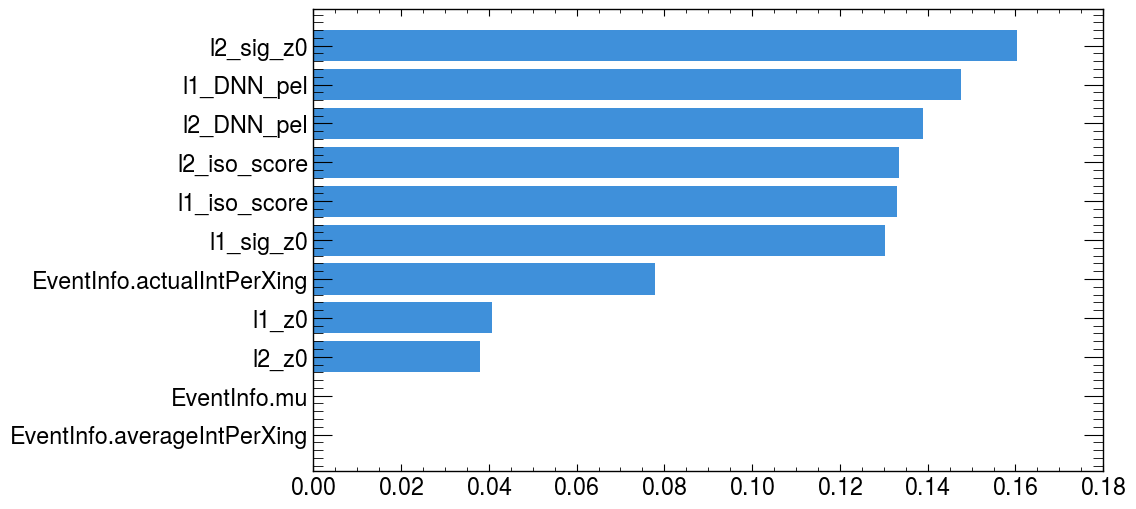

In [200]:
fig, ax = plt.subplots(figsize=(10, 6))

# Sort the feature importances
sorted_importances = tuner.feature_importances.sort_values()

# Print the sorted feature importances
print(sorted_importances)

# Plot the sorted feature importances
ax.barh(sorted_importances.index, sorted_importances.values)

ROC AUC: 0.9497141328305856


Text(0.5, 1.0, 'ROC curve for Z identification')

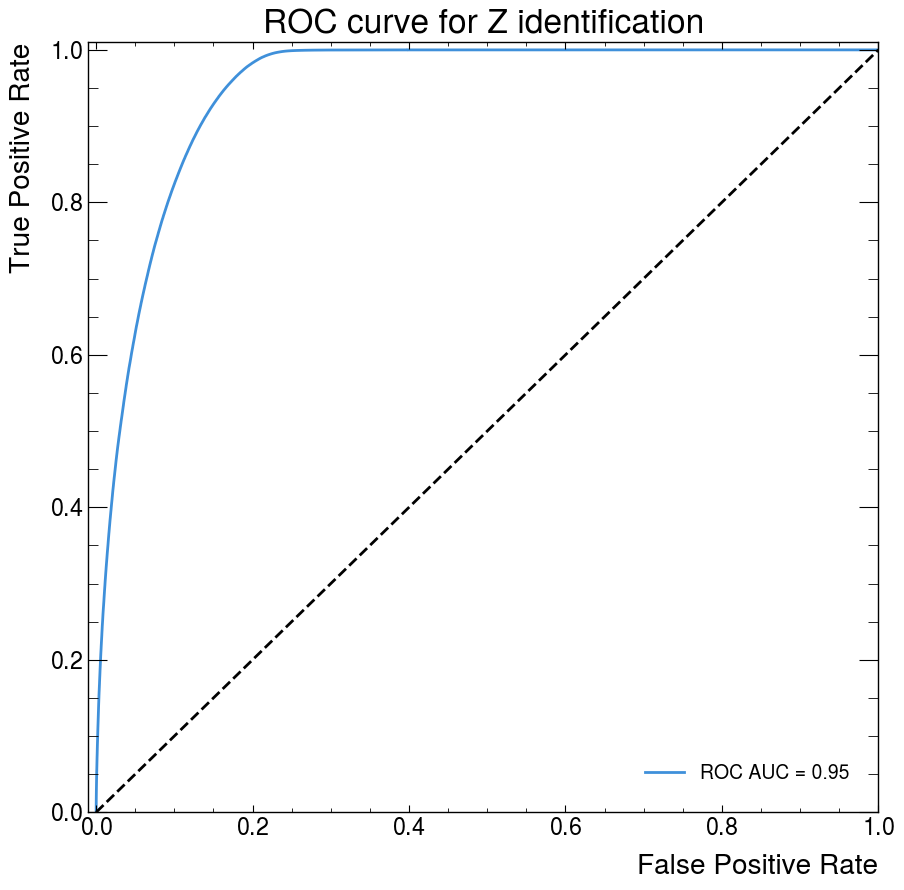

In [201]:
fig, ax = plt.subplots(figsize=(10, 10))

print(f'ROC AUC: {roc_auc_score(y_test, id_predictions)}')
fpr, tpr, _ = roc_curve(y_test, id_predictions)
ax.plot(fpr, tpr, label=f'ROC AUC = {roc_auc_score(y_test, id_predictions):.2f}')

ax.plot([0, 1], [0, 1], color='black', linestyle='--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
ax.set_xlim(-0.01, 1)
ax.set_ylim(0, 1.01)
ax.set_title('ROC curve for Z identification')

In [202]:
print(Data['EventInfo.cutflow'].value_counts())
print(Data['EventInfo.cutflow_new'].value_counts())

EventInfo.cutflow
14    4540134
10    4125998
17      50426
18      44014
19      30857
15       1073
Name: count, dtype: int64
EventInfo.cutflow_new
0     4666504
16    2494568
15    1448431
17     131999
19      33408
18      17592
Name: count, dtype: int64


In [203]:
num_Z_ATLAS = len(X_test[X_test['EventInfo.cutflow'] >= 14])
num_FP_ATLAS = len(X_test[(X_test['EventInfo.cutflow'] >= 14) & (X_test['truth_from_Z'] == 0)])
num_FN_ATLAS = len(X_test[(X_test['EventInfo.cutflow'] < 14) & (X_test['truth_from_Z'] == 1)])

print(f'Number of Z events in ATLAS: {num_Z_ATLAS}')
print(f'Number of True positives ATLAS: {len(Data[(Data['EventInfo.cutflow'] >= 14) & (Data['truth_from_Z'] == 1)])}')
print(f'Number of false positives in ATLAS: {num_FP_ATLAS}, {num_FP_ATLAS/num_Z_ATLAS*100:.2f}%')
print(f'Number of false negatives in ATLAS: {num_FN_ATLAS}, {num_FN_ATLAS/num_Z_ATLAS*100:.2f}%')

Number of Z events in ATLAS: 1165144
Number of True positives ATLAS: 3955287
Number of false positives in ATLAS: 177837, 15.26%
Number of false negatives in ATLAS: 110155, 9.45%


In [204]:
print(Data.shape)
print(id_predictions.shape)
if False:
    # tuned_cut = np.sort(id_predictions[Data['truth_from_Z']==0])[-num_FP_ATLAS]
    tuned_cut_FN = np.sort(id_predictions[Data['truth_from_Z']==1])[num_FN_ATLAS]
    tuned_cut_FP = np.sort(id_predictions[Data['truth_from_Z']==0])[-num_FP_ATLAS]
    print(f'Tuned cut: {tuned_cut_FN}')
    pred_Z_FN = id_predictions > tuned_cut_FN
    pred_Z_FP = id_predictions > tuned_cut_FP
    pred_Z = id_predictions > 0.8
    print(f'Number of Z events in new cut: {len(Data[pred_Z_FN])}')
    print(f'Number of True positives new cut: {len(Data[(pred_Z_FN) & (Data["truth_from_Z"] == 1)])}')
    print(f'Number of false positives in new cut: {len(Data[(pred_Z_FN) & (Data["truth_from_Z"] == 0)])}')
else:
    tuned_cut_FP = np.sort(id_predictions[y_test==0])[-num_FP_ATLAS]
    tuned_cut_FN = np.sort(id_predictions[y_test==1])[num_FN_ATLAS]
    tuned_cut = tuned_cut_FP
    pred_Z_FN = id_predictions > tuned_cut_FN
    pred_Z_FP = id_predictions > tuned_cut_FP
    print(f'Tuned cut: {tuned_cut}')
    pred_Z = id_predictions > tuned_cut
    print(f'Number of Z events in new cut: {np.sum(pred_Z)}')
    print(f'Number of True positives new cut: {len(X_test[(pred_Z) & y_test])}')
    print(f'Number of false positives in new cut: {len(X_test[(pred_Z) & (X_test["truth_from_Z"] == 0)])}')

(8792502, 42)
(2196731,)
Tuned cut: 0.5655481224483226
Number of Z events in new cut: 1215316
Number of True positives new cut: 1037480
Number of false positives in new cut: 177836


Text(0.5, 1.0, 'ATLAS')

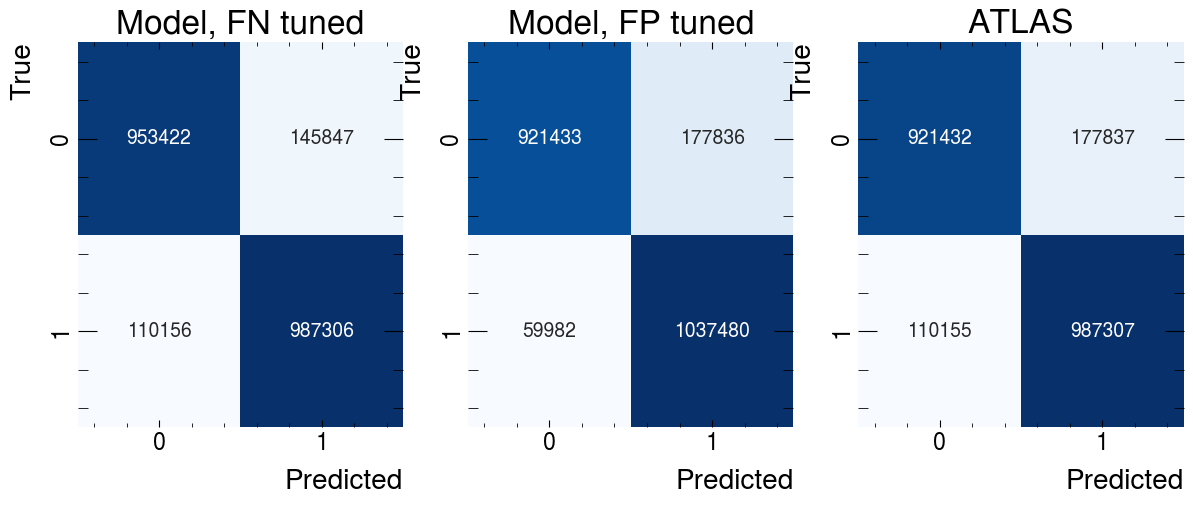

In [205]:
# double confusion matrix:
fig, ax = plt.subplots(1,3,figsize=(14, 5))
if False:
    cm = confusion_matrix(Data['truth_from_Z'], pred_Z_FN)
else:
    cm = confusion_matrix(y_test, pred_Z_FN)
sns.heatmap(cm, annot=True, fmt='d', ax=ax[0], cmap='Blues', cbar=False)
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('True')
ax[0].set_title('Model, FN tuned')

# double confusion matrix:
if False:
    cm = confusion_matrix(Data['truth_from_Z'], pred_Z_FP)
else:
    cm = confusion_matrix(y_test, pred_Z_FP)
sns.heatmap(cm, annot=True, fmt='d', ax=ax[1], cmap='Blues', cbar=False)
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('True')
ax[1].set_title('Model, FP tuned')

cm = confusion_matrix(X_test['truth_from_Z'], X_test['EventInfo.cutflow'] >= 14)
sns.heatmap(cm, annot=True, fmt='d', ax=ax[2], cmap='Blues', cbar=False)
ax[2].set_xlabel('Predicted')
ax[2].set_ylabel('True')
ax[2].set_title('ATLAS')

Text(0.5, 1.0, 'ATLAS')

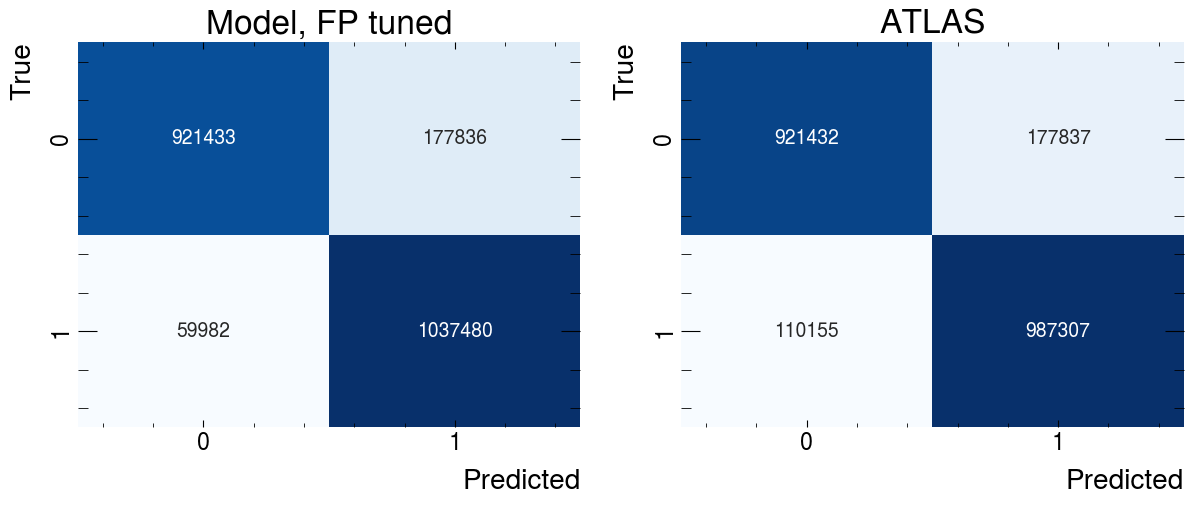

In [206]:
# double confusion matrix:
fig, ax = plt.subplots(1,2,figsize=(14, 5))

# double confusion matrix:
if False:
    cm = confusion_matrix(Data['truth_from_Z'], pred_Z_FP)
else:
    cm = confusion_matrix(y_test, pred_Z_FP)
sns.heatmap(cm, annot=True, fmt='d', ax=ax[0], cmap='Blues', cbar=False)
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('True')
ax[0].set_title('Model, FP tuned')

cm = confusion_matrix(X_test['truth_from_Z'], X_test['EventInfo.cutflow'] >= 14)
sns.heatmap(cm, annot=True, fmt='d', ax=ax[1], cmap='Blues', cbar=False)
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('True')
ax[1].set_title('ATLAS')

In [207]:
gain_mask = (X_test['truth_from_Z'] == 1) & (X_test['EventInfo.cutflow'] < 14) & (pred_Z)
print(f'Number of Z events gained: {len(X_test[gain_mask])}')

print(X_test['EventInfo.cutflow'][gain_mask].value_counts())
print(X_test['EventInfo.cutflow_new'][gain_mask].value_counts())

Number of Z events gained: 79435
EventInfo.cutflow
10    79435
Name: count, dtype: int64
EventInfo.cutflow_new
16    76591
17      951
18      740
15      630
19      523
Name: count, dtype: int64


In [208]:
# cut = np.linspace(0, 1, 5000)
# eff = np.zeros_like(cut)
# fp = np.zeros_like(cut)

truth_label = np.array(X_test['truth_from_Z'] == 1)

# for i, c in enumerate(cut):
#     if i % 1000 == 0:
#         print(i)
#     eff[i] = np.sum(((id_predictions > c) & truth_label))/num_Z_ATLAS
#     fp[i] = np.sum((id_predictions > c) & ~truth_label)/num_Z_ATLAS

# fig, ax = plt.subplots(figsize=(10, 10))
# ax.plot(cut, eff, label='Efficiency')
# ax.plot(cut, fp, label='False positive rate')
# ax.set_xlabel('Cut')


In [209]:
# fig, ax = plt.subplots(figsize=(10, 6))
# ax.plot(fp, eff)
# ax.set_xlabel('False positive rate')
# ax.set_ylabel('Efficiency')

# fig, ax = plt.subplots(figsize=(10, 6))
# ax.plot(eff, fp)
# ax.set_xlabel('Efficiency')
# ax.set_ylabel('False positive rate')

In [210]:
# fig, ax = plt.subplots(figsize=(10, 6))
# ax.plot(cut, eff, label='Efficiency')
# ax.plot(cut, fp, label='False positive rate')
# ax.plot([0, 1], [num_FP_ATLAS/num_Z_ATLAS, num_FP_ATLAS/num_Z_ATLAS], label='ATLAS FP rate')
# ax.plot([0, 1],[num_FN_ATLAS/num_Z_ATLAS, num_FN_ATLAS/num_Z_ATLAS], label='ATLAS FN rate')
# ax.plot([tuned_cut_FN, tuned_cut_FN], [0, 1], label='Tuned cut FN')
# ax.plot([tuned_cut_FP, tuned_cut_FP], [0, 1], label='Tuned cut FP')
# ax.set_xlabel('Cut')
# ax.set_xscale('log')
# # ax.set_yscale('log')
# ax.legend()

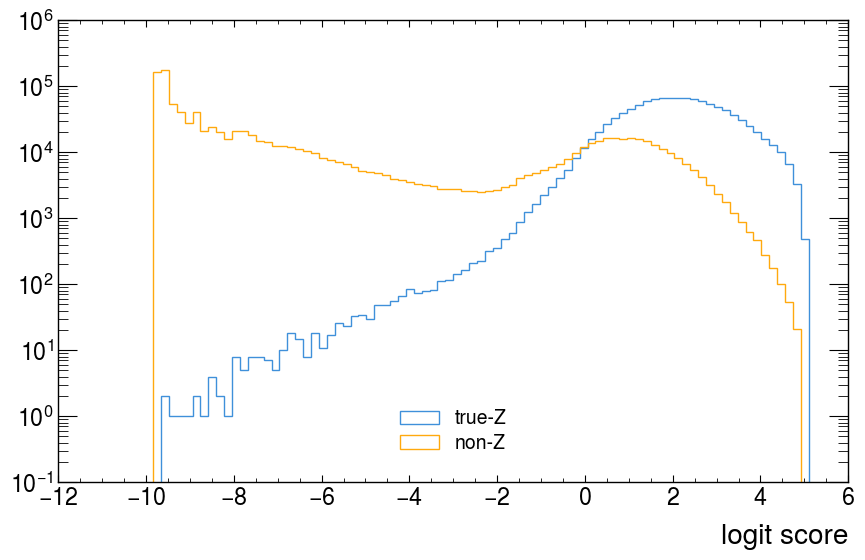

In [211]:
fig, ax = plt.subplots(figsize=(10, 6))
# ax.hist(id_predictions[Data['truth_from_Z'] == 1], bins=100, range=(0,1), histtype='step', label='true-Z')
# ax.hist(id_predictions[Data['truth_from_Z'] == 0], bins=100, range=(0,1), histtype='step', label='non-Z')
id_predictions_logit = np.log(id_predictions/(1-id_predictions))
ax.hist(id_predictions_logit[X_test['truth_from_Z'] == 1], bins=100, range=(-12,6), histtype='step', label='true-Z')
ax.hist(id_predictions_logit[X_test['truth_from_Z'] == 0], bins=100, range=(-12,6), histtype='step', label='non-Z')
ax.set_xlabel('logit score')
ax.set_yscale('log')
ax.legend()

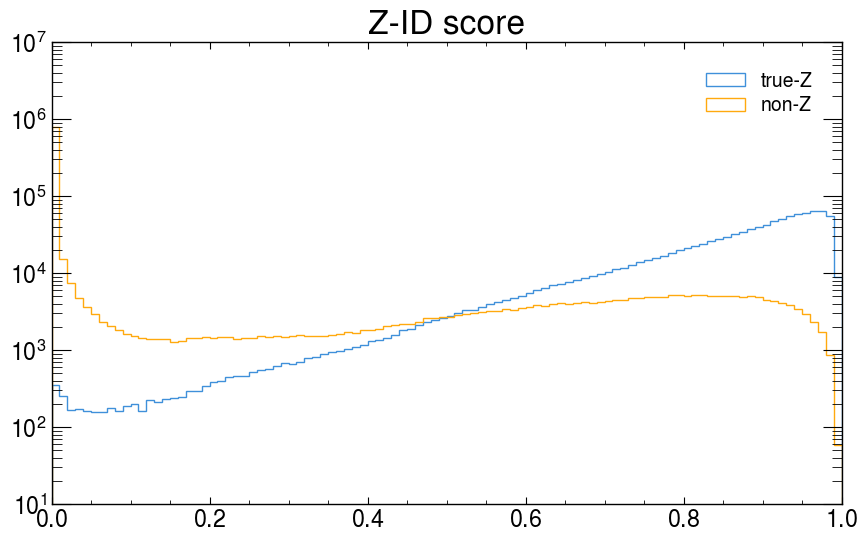

In [212]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(id_predictions[X_test['truth_from_Z'] == 1], bins=100, range=(0,1), histtype='step', label='true-Z')
ax.hist(id_predictions[X_test['truth_from_Z'] == 0], bins=100, range=(0,1), histtype='step', label='non-Z')
ax.set_title('Z-ID score')
ax.set_yscale('log')
ax.legend()

In [213]:
print(tuned_cut_FN, tuned_cut_FP)

0.6523659637587892 0.5655481224483226


In [214]:
print(Data['EventInfo.cutflow'][Data['truth_from_Z']].value_counts())

EventInfo.cutflow
14    3852950
10     440964
18      38607
17      36353
19      26694
15        683
Name: count, dtype: int64


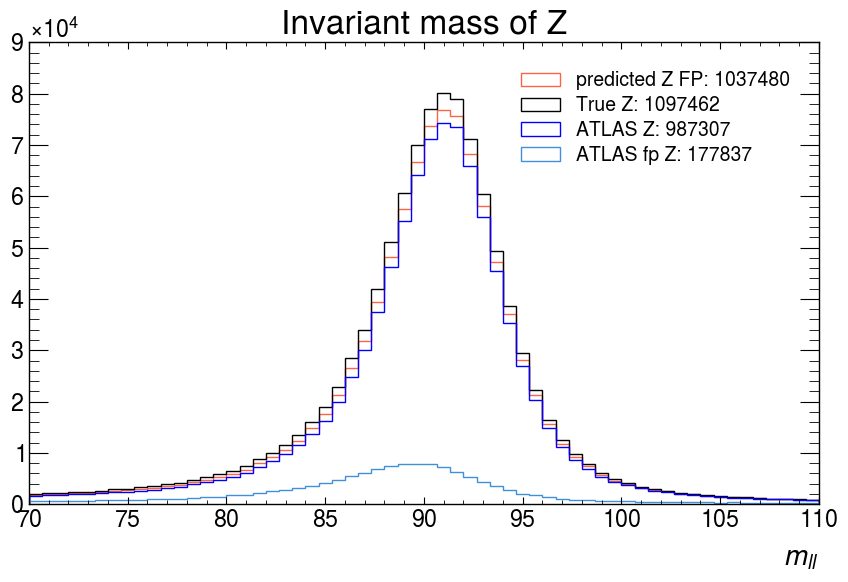

In [215]:
fp_mask = (X_test['truth_from_Z'] == 0) & pred_Z
fig, ax = plt.subplots(figsize=(10, 6))
# ax.hist(Data['ll_m'][fp_mask], bins=60, range=(70, 110), histtype='step', label=f'False positives: {len(Data["ll_m"][fp_mask])}')
ax.hist(X_test['ll_m'][X_test['truth_from_Z'] & pred_Z_FP], bins=60, range=(70, 110),color='Tomato', histtype='step', label=f'predicted Z FP: {len(X_test['ll_m'][X_test['truth_from_Z'] & pred_Z_FP])}')
# ax.hist(Data['ll_m'][Data['truth_from_Z'] & pred_Z_FN], bins=60, range=(70, 110),color='DarkRed', histtype='step', label=f'predicted Z FN: {len(Data['ll_m'][Data['truth_from_Z'] & pred_Z_FN])}')
ax.hist(X_test['ll_m'][X_test['truth_from_Z'] == 1], bins=60, range=(70, 110),color='black', histtype='step', label=f'True Z: {len(X_test['ll_m'][X_test['truth_from_Z'] == 1])}')
ax.hist(X_test['ll_m'][X_test['truth_from_Z'] & (X_test['EventInfo.cutflow'] >= 14)], bins=60, range=(70, 110),color='blue', histtype='step', label=f'ATLAS Z: {len(X_test['ll_m'][X_test['truth_from_Z'] & (X_test['EventInfo.cutflow'] >= 14)])}')
# ax.hist(Data['ll_m'][Data['truth_from_Z'] & id_predictions>0.8], bins=60, range=(70, 110),color='green', histtype='step', label=f'predicted Z (manual cut): {len(Data['ll_m'][Data['truth_from_Z'] & id_predictions>0.8])}')
ax.hist(X_test['ll_m'][(X_test['truth_from_Z'] == 0) & (X_test['EventInfo.cutflow'] >= 14)], bins=60, range=(70, 110), histtype='step', label=f'ATLAS fp Z: {len(X_test['ll_m'][(X_test['truth_from_Z'] == 0) & (X_test['EventInfo.cutflow'] >= 14)])}')
ax.set_xlabel('$m_{ll}$')
ax.set_title('Invariant mass of Z')
ax.legend()


In [216]:
manual_mask = id_predictions > 0.8

print(X_test['EventInfo.cutflow'][manual_mask].value_counts())
print(X_test['EventInfo.cutflow_new'][manual_mask].value_counts())

EventInfo.cutflow
14    820417
10     36019
17      8892
18      7873
19      5650
15       132
Name: count, dtype: int64
EventInfo.cutflow_new
0     842964
16     34717
17       467
18       329
15       264
19       242
Name: count, dtype: int64


In [217]:
gain_mask = (X_test['truth_from_Z'] == 1) & (X_test['EventInfo.cutflow'] < 14) & (manual_mask)
print(f'Number of Z events gained: {len(X_test[gain_mask])}')

print(X_test['EventInfo.cutflow'][gain_mask].value_counts())
print(X_test['EventInfo.cutflow_new'][gain_mask].value_counts())

Number of Z events gained: 31321
EventInfo.cutflow
10    31321
Name: count, dtype: int64
EventInfo.cutflow_new
16    30225
17      381
18      286
19      215
15      214
Name: count, dtype: int64


[-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21]
no


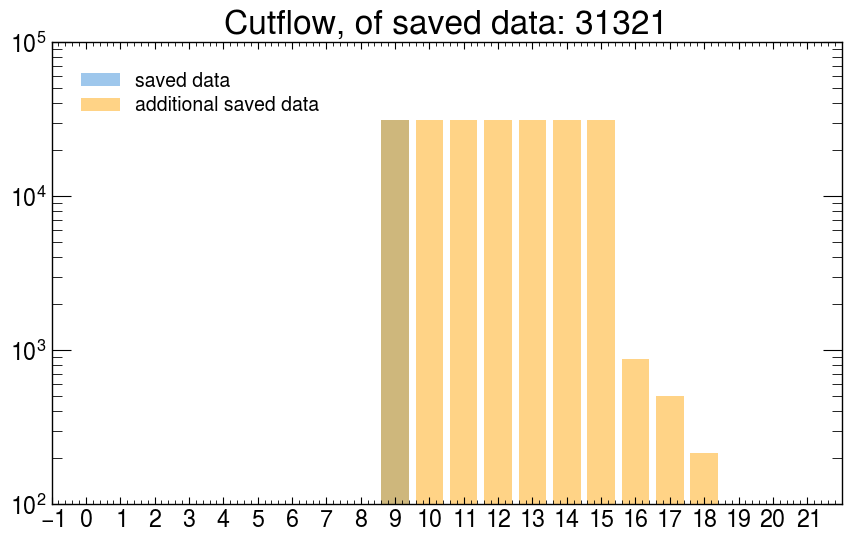

In [218]:

cutflow_tree = X_test['EventInfo.cutflow'].to_numpy()[gain_mask]
cutflow_tree_new = X_test['EventInfo.cutflow_new'].to_numpy()[gain_mask]

accum_cutflow = np.zeros(23)
accum_cutflow_new = np.zeros(23)

for i in range(3,23):
    if i >=10:
        accum_cutflow[i] = np.sum(cutflow_tree >= i)
        accum_cutflow_new[i] = np.sum(cutflow_tree_new >= i)

fig, ax = plt.subplots(figsize=(10, 6))
# ax.bar(np.arange(-1,23-1)) label='Original')
ax.set_title(f'Cutflow, of saved data: {np.sum(gain_mask)}')
ax.bar(np.arange(-1,23-1), accum_cutflow, alpha=0.5, label='saved data')
ax.bar(np.arange(-1,23-1), accum_cutflow_new, alpha=0.5, label='additional saved data')
ax.set_xticks(np.arange(-1,23-1))
ax.set_xlim(-1,23-1)
print(np.arange(-1,23-1))
ax.legend()
ax.set_yscale('log')
print('no')

no


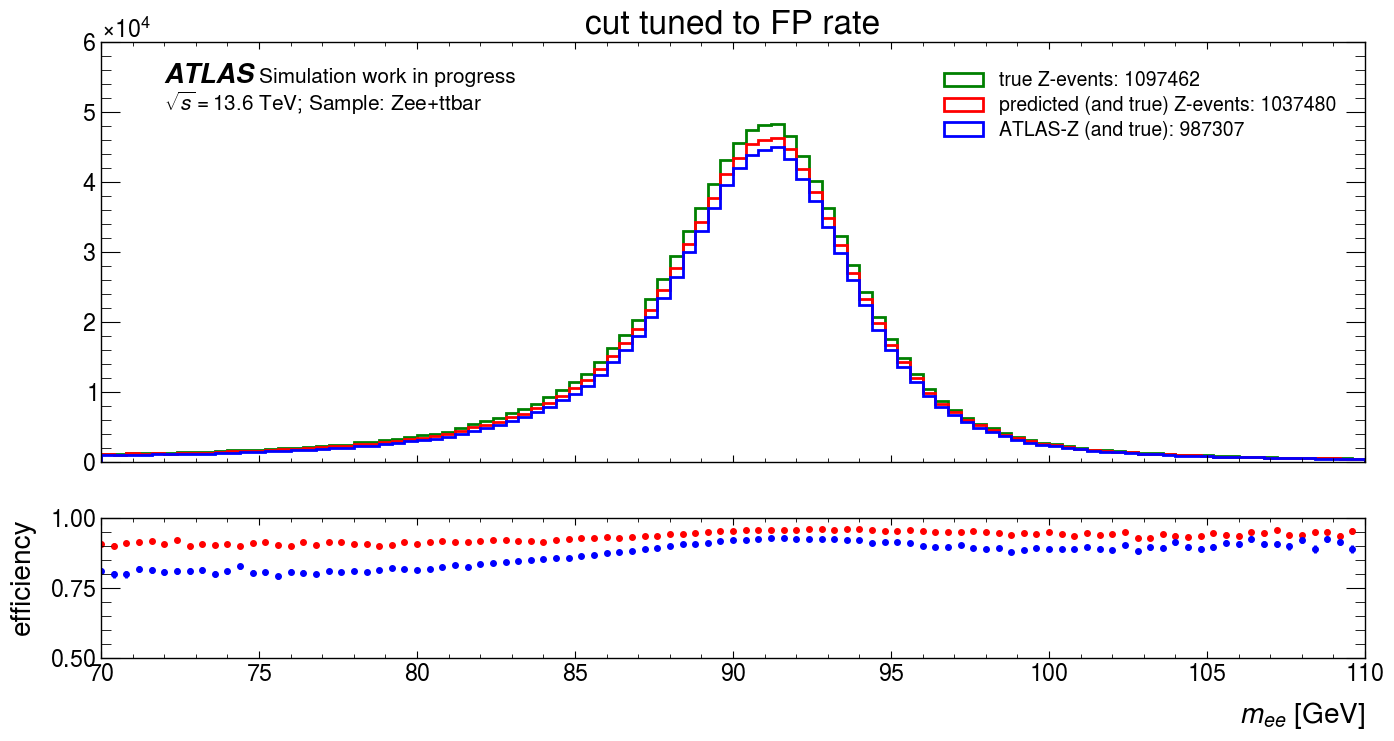

In [219]:
n_bins = 100
y_pred_cut = tuned_cut_FP<id_predictions
fig, ax = plt.subplots(2,1, figsize=(16, 8), height_ratios=[3, 1])
counts_true, bins_true, _ = ax[0].hist(X_test['ll_m'][X_test['truth_from_Z']==1], bins=n_bins, range=(70, 110),linewidth=2, histtype='step', label=f'true Z-events: {np.sum(X_test['truth_from_Z']==1)}', color='green')
counts_trueandmodel, bins_trueandmodel, _ = ax[0].hist(X_test['ll_m'][(y_pred_cut==1) & (X_test['truth_from_Z']==1)], bins=n_bins, range=(70, 110),linewidth=2, histtype='step',color='r', label=f'predicted (and true) Z-events: {np.sum((y_pred_cut==1) & (X_test["truth_from_Z"]==1))}')
counts_trueandATLAS, bins_TrueandATLAS, _ = ax[0].hist(X_test['ll_m'][(X_test['EventInfo.cutflow'] >= 14) & (X_test['truth_from_Z']==1)], bins=n_bins,linewidth=2, range=(70, 110), histtype='step',color='b', label=f'ATLAS-Z (and true): {np.sum((X_test['EventInfo.cutflow'] >= 14) & (X_test["truth_from_Z"]==1))}')
ax[0].legend(loc='upper right')
ax[0].set_xticklabels([])


hep.atlas.label(data=False, label="work in progress", fontsize=15, ax= ax[0],rlabel=f"$\sqrt{{s}}=13.6$ TeV; Sample: {"Zee+ttbar"}")


eff_model = counts_trueandmodel/counts_true
eff_ATLAS = counts_trueandATLAS/counts_true

uncertainty_model = np.sqrt(eff_model*(1-eff_model)/counts_true)
uncertainty_ATLAS = np.sqrt(eff_ATLAS*(1-eff_ATLAS)/counts_true)

ax[0].set_title('cut tuned to FP rate')

ax[1].errorbar(bins_true[:-1], eff_model, yerr=uncertainty_model, fmt='.', label='model', color='r')
ax[1].errorbar(bins_true[:-1], eff_ATLAS, yerr=uncertainty_ATLAS, fmt='.', label='ATLAS', color='b')
ax[1].set_xlabel('$m_{ee}$ [GeV]')
ax[1].set_ylabel('efficiency')
ax[1].set_ylim(0.5,1)

# ax[0].set_title('Zee model on Zee data')
# ax[1].legend()

print('no')

no


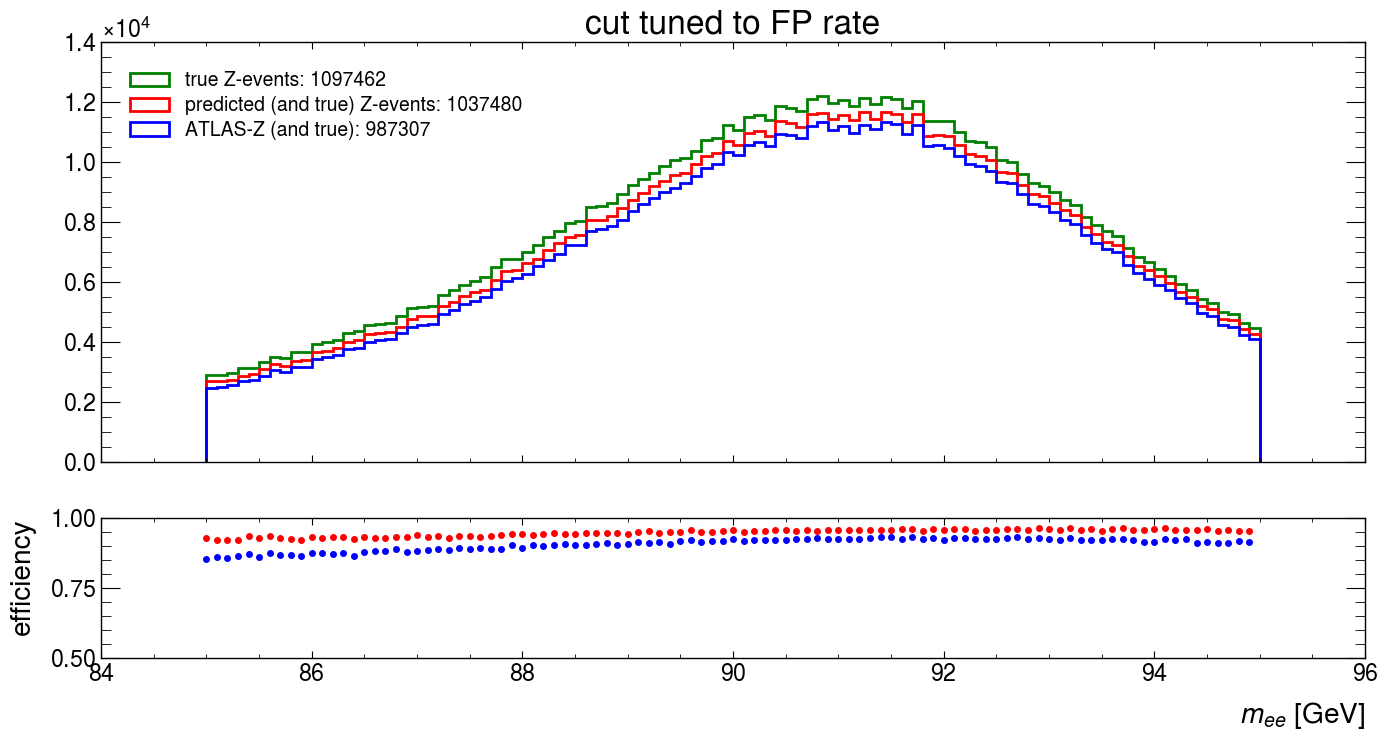

In [220]:
n_bins = 100
y_pred_cut = tuned_cut_FP<id_predictions
fig, ax = plt.subplots(2,1, figsize=(16, 8), height_ratios=[3, 1])
counts_true, bins_true, _ = ax[0].hist(X_test['ll_m'][X_test['truth_from_Z']==1], bins=n_bins, range=(85, 95),linewidth=2, histtype='step', label=f'true Z-events: {np.sum(X_test['truth_from_Z']==1)}', color='green')
counts_trueandmodel, bins_trueandmodel, _ = ax[0].hist(X_test['ll_m'][(y_pred_cut==1) & (X_test['truth_from_Z']==1)], bins=n_bins, range=(85, 95),linewidth=2, histtype='step',color='r', label=f'predicted (and true) Z-events: {np.sum((y_pred_cut==1) & (X_test["truth_from_Z"]==1))}')
counts_trueandATLAS, bins_TrueandATLAS, _ = ax[0].hist(X_test['ll_m'][(X_test['EventInfo.cutflow'] >= 14) & (X_test['truth_from_Z']==1)], bins=n_bins,linewidth=2, range=(85, 95), histtype='step',color='b', label=f'ATLAS-Z (and true): {np.sum((X_test['EventInfo.cutflow'] >= 14) & (X_test["truth_from_Z"]==1))}')
ax[0].legend(loc='upper left')
ax[0].set_xticklabels([])
eff_model = counts_trueandmodel/counts_true
eff_ATLAS = counts_trueandATLAS/counts_true

uncertainty_model = np.sqrt(eff_model*(1-eff_model)/counts_true)
uncertainty_ATLAS = np.sqrt(eff_ATLAS*(1-eff_ATLAS)/counts_true)

ax[0].set_title('cut tuned to FP rate')

ax[1].errorbar(bins_true[:-1], eff_model, yerr=uncertainty_model, fmt='.', label='model', color='r')
ax[1].errorbar(bins_true[:-1], eff_ATLAS, yerr=uncertainty_ATLAS, fmt='.', label='ATLAS', color='b')
ax[1].set_xlabel('$m_{ee}$ [GeV]')
ax[1].set_ylabel('efficiency')
ax[1].set_ylim(0.5,1)

# ax[0].set_title('Zee model on Zee data')
# ax[1].legend()

print('no')

In [221]:
print(np.sum([X_test['EventInfo.cutflow'] >= 14]))
print(np.sum([X_test['truth_from_Z'] == 1]))
print(np.sum((X_test['EventInfo.cutflow'] >= 14) & (X_test['truth_from_Z'] == 1)))


1165144
1097462
987307


In [222]:
print('possible cuts:')
print(f'FP 1:1 cut: {np.sort(id_predictions[y_test==0])[-num_FP_ATLAS]}')
print(f'FN 1:1 cut: {np.sort(id_predictions[y_test==1])[num_FN_ATLAS]}')

print(f'FP 1:2 cut: {np.sort(id_predictions[y_test==0])[-2*num_FP_ATLAS]}')
print(f'FN 1:2 cut: {np.sort(id_predictions[y_test==1])[2*num_FN_ATLAS]}')


possible cuts:
FP 1:1 cut: 0.5655481224483226
FN 1:1 cut: 0.6523659637587892
FP 1:2 cut: 0.002438322736013401
FN 1:2 cut: 0.755990255184108


In [223]:

deltaz = np.abs(Data['l1_z0'] - Data['l2_z0'])

sigma_delta_z = np.sqrt(Data['l1_sig_z0']**2 + Data['l2_sig_z0']**2)

Data['deltaz'] = deltaz
Data['sigma_delta_z'] = sigma_delta_z

pred_z_param_list_2 = ['l1_iso_score', 'l2_iso_score', 
                     'l1_DNN_pel', 'l2_DNN_pel', 'EventInfo.actualIntPerXing'
                     , 'deltaz', 'sigma_delta_z']


In [224]:
print(Data.shape)

mask = Data['EventInfo.eventNumber'] % 4 != 0
X_train = Data[mask][pred_z_param_list_2]
y_train = Data[mask]['truth_from_Z']
X_test = Data[~mask]
y_test = Data[~mask]['truth_from_Z']


if os.path.exists(f'z_tuner_noncross_deltaz.pkl'):
    with open(f'z_tuner_noncross_deltaz.pkl', 'rb') as f:
        tuner2 = pickle.load(f)
        id_predictions2 = tuner2.predict_proba(X_test[pred_z_param_list_2])
else:

    tuner2 = RapidGBMTuner(metric='auc', trials=400, refit=True, verbosity=1, visualization=True, seed=414243)#, grid='h,learning_rate')

    tuner2.fit(X_train, y_train)
    tuner2.fit_optimized(X_train.to_numpy(), y_train.to_numpy())

    with open(f'z_tuner_noncross_deltaz.pkl', 'wb') as f:
        pickle.dump(tuner2, f)

    id_predictions2 = tuner2.predict_proba(X_test[pred_z_param_list_2])


(8792502, 44)


ROC AUC: 0.9497141328305856
ROC AUC: 0.9496460766202025


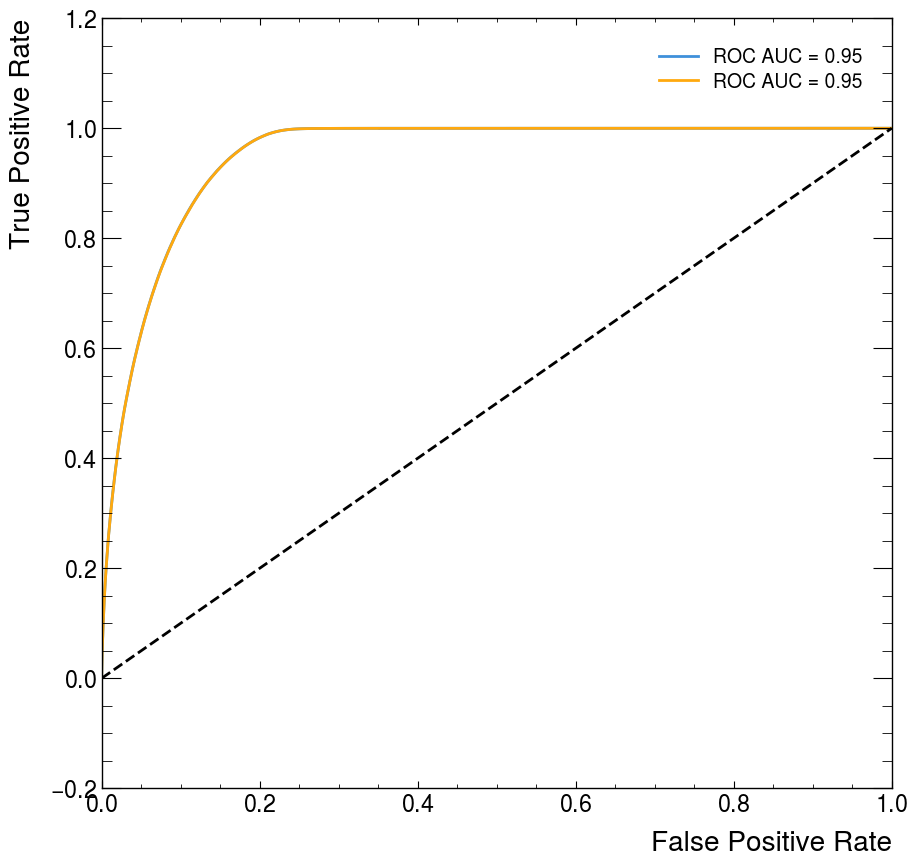

In [225]:
# compare tuner 1 and tuner 2
print(f'ROC AUC: {roc_auc_score(y_test, id_predictions)}')
fig, ax = plt.subplots(figsize=(10, 10))
fpr, tpr, _ = roc_curve(y_test, id_predictions)
ax.plot(fpr, tpr, label=f'ROC AUC = {roc_auc_score(y_test, id_predictions):.2f}')
fpr, tpr, _ = roc_curve(y_test, id_predictions2)
ax.plot(fpr, tpr, label=f'ROC AUC = {roc_auc_score(y_test, id_predictions2):.2f}')

print(f'ROC AUC: {roc_auc_score(y_test, id_predictions2)}')
ax.plot([0, 1], [0, 1], color='black', linestyle='--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()



In [226]:
F1_score_model_1 = np.zeros(200)
F1_score_model_2 = np.zeros(200)

eff1 = np.zeros(200)
eff2 = np.zeros(200)
antieff2 = np.zeros(200)

MCC_model_1 = np.zeros(200)
MCC_model_2 = np.zeros(200)
cut = np.linspace(0, 1, 200)
# for i in range(200):
#     F1_score_model_2[i] = f1_score(y_test, id_predictions2 > cut[i])

#     MCC_model_2[i] = matthews_corrcoef(y_test, id_predictions2 > cut[i])

#     eff2[i] = np.sum(((id_predictions2 > cut[i]) & truth_label))/np.sum(truth_label)

#     antieff2[i] = np.sum(((id_predictions2 < cut[i]) & ~truth_label))/np.sum(~truth_label)
#     if i % 10 == 0:
#         print(i)

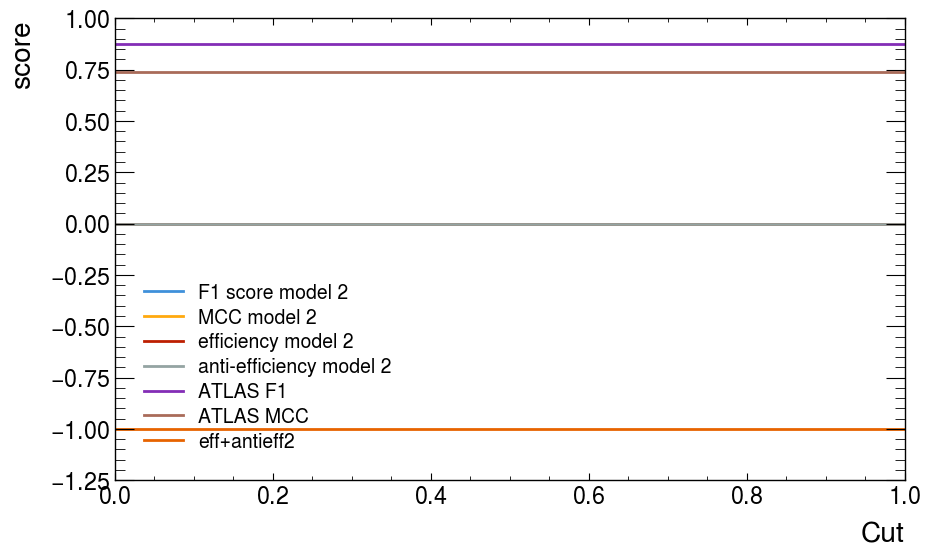

In [227]:
ATLAS_F1 = f1_score(y_test, X_test['EventInfo.cutflow'] >= 14)
ATLAS_MCC = matthews_corrcoef(y_test, X_test['EventInfo.cutflow'] >= 14)

fig, ax = plt.subplots(figsize=(10, 6))
# ax.plot(cut, F1_score_model_1, label='F1 score model 1')
ax.plot(cut, F1_score_model_2, label='F1 score model 2')
ax.set_xlabel('Cut')
ax.legend()
# ax.plot(cut, MCC_model_1, label='MCC model 1')
ax.plot(cut, MCC_model_2, label='MCC model 2')
ax.plot(cut, eff2, label='efficiency model 2')
ax.plot(cut, antieff2, label='anti-efficiency model 2')

ax.plot([0, 1], [ATLAS_F1, ATLAS_F1], label='ATLAS F1')
ax.plot([0, 1], [ATLAS_MCC, ATLAS_MCC], label='ATLAS MCC')

ax.plot(cut,eff2+antieff2-1, label='eff+antieff2')

ax.set_ylabel('score')

# ax.plot([cut[np.argmax(F1_score_model_2)], cut[np.argmax(F1_score_model_2)]], [0, 1], label='F1 max model 2')
# ax.plot([cut[np.argmax(MCC_model_2)], cut[np.argmax(MCC_model_2)]], [0, 1], label='MCC max model 2')
# ax.set_xscale('log')
ax.legend()


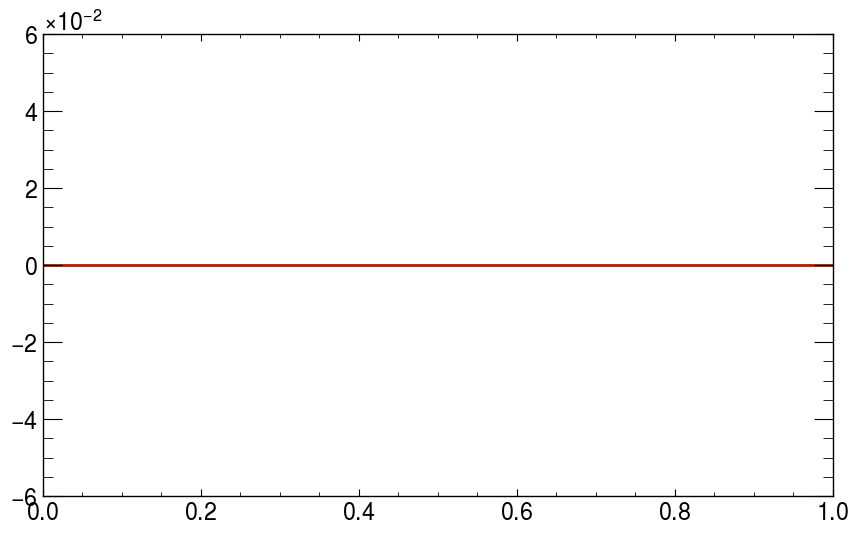

In [228]:
deriv_F1 = np.gradient(F1_score_model_2)
deriv_MCC = np.gradient(MCC_model_2)
deriv_combeff = np.gradient(eff2 + antieff2 - 1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(cut, deriv_F1, label='F1 score model 2')
ax.plot(cut, deriv_MCC, label='MCC model 2')
ax.plot(cut, deriv_combeff, label='eff+antieff2')

In [229]:
print(tuner.feature_importances)
print(tuner2.feature_importances)


l1_iso_score                   0.13292
l2_iso_score                   0.13349
l1_DNN_pel                     0.14749
l1_z0                          0.04083
l1_sig_z0                      0.13017
l2_DNN_pel                     0.13885
l2_z0                          0.03806
l2_sig_z0                      0.16027
EventInfo.actualIntPerXing     0.07792
EventInfo.averageIntPerXing    0.00000
EventInfo.mu                   0.00000
dtype: float64
l1_iso_score                  0.16168
l2_iso_score                  0.16333
l1_DNN_pel                    0.15623
l2_DNN_pel                    0.16977
EventInfo.actualIntPerXing    0.08974
deltaz                        0.12203
sigma_delta_z                 0.13722
dtype: float64


In [230]:
cut = np.linspace(0, 1, 500)

num_sig = np.zeros_like(cut)
num_bkg = np.zeros_like(cut)

for i in range(len(cut)):
    num_sig[i] = np.sum((id_predictions2 > cut[i]) & y_test)
    num_bkg[i] = np.sum((id_predictions2 > cut[i]) & ~y_test)

Text(0, 1, 'Background/ATLAS background')

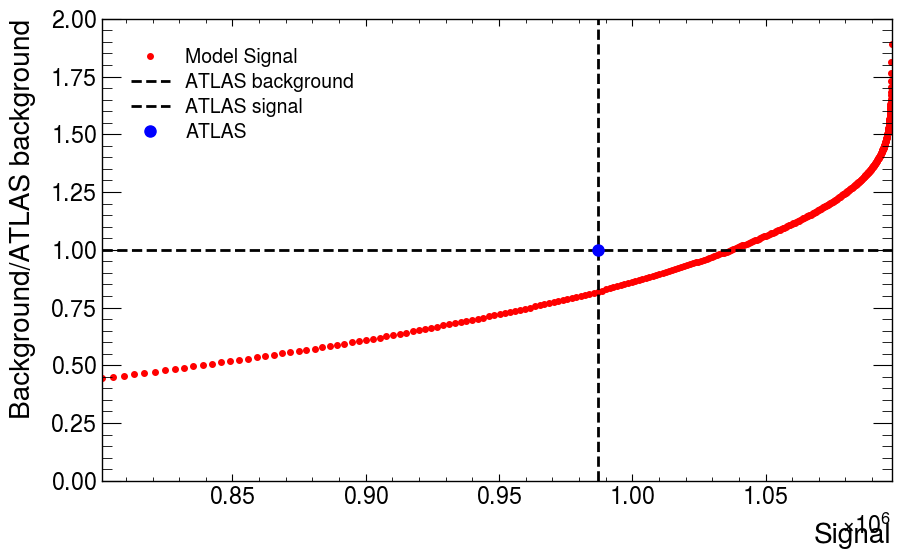

In [231]:
num_sig_atlas = np.sum((X_test['truth_from_Z'] == 1) & (X_test['EventInfo.cutflow'] >= 14))
num_bkg_atlas = np.sum((X_test['truth_from_Z'] == 0) & (X_test['EventInfo.cutflow'] >= 14))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(num_sig[(num_bkg/num_bkg_atlas < 2) & (num_sig > 0.8e6)], num_bkg[(num_bkg/num_bkg_atlas < 2)& (num_sig > 0.8e6)]/num_bkg_atlas,'.',color='red', label='Model Signal')
ax.plot([np.min(num_sig[(num_bkg/num_bkg_atlas < 2) & (num_sig > 0.8e6)]), np.max(num_sig[(num_bkg/num_bkg_atlas < 2) & (num_sig > 0.8e6)])], [1, 1],'--',color='black', label='ATLAS background')
ax.plot([num_sig_atlas, num_sig_atlas], [0, 2], '--', color='black', label='ATLAS signal')
ax.plot(num_sig_atlas, num_bkg_atlas/num_bkg_atlas, 'o',color='blue', label='ATLAS')

ax.set_xlim(np.min(num_sig[(num_bkg/num_bkg_atlas < 2) & (num_sig > 0.8e6)]), np.max(num_sig[(num_bkg/num_bkg_atlas < 2) & (num_sig > 0.8e6)]))

ax.set_ylim(0, 2)
# ax.set_xscale('log')
# ax.set_yscale('log')

ax.legend()
ax.set_xlabel('Signal')
ax.set_ylabel('Background/ATLAS background')


In [232]:
actual_data = pd.read_parquet('channel1_some_more_data.parquet')
print(actual_data.shape)
iso1_data = np.zeros(actual_data.shape[0])
iso2_data = np.zeros(actual_data.shape[0])

for i in range(4):
    with open(f'iso_tuner_{i}.pkl', 'rb') as f:
        tuner = pickle.load(f)
    mask = actual_data['EventInfo.eventNumber'] % 4 == i
    X_test_1 = actual_data[mask][iso_1_param_list]
    X_test_2 = actual_data[mask][iso_2_param_list]
    iso1_data[mask] = tuner.predict_proba(X_test_1)
    iso2_data[mask] = tuner.predict_proba(X_test_2)

actual_data['l1_iso_score'] = iso1_data
actual_data['l2_iso_score'] = iso2_data

with open(f'z_tuner_noncross.pkl', 'rb') as f:
    tuner = pickle.load(f)
pred_score_data = tuner.predict_proba(actual_data[pred_z_param_list])

(12152, 38)


In [233]:
print(actual_data.shape[0]/1e6)

0.012152


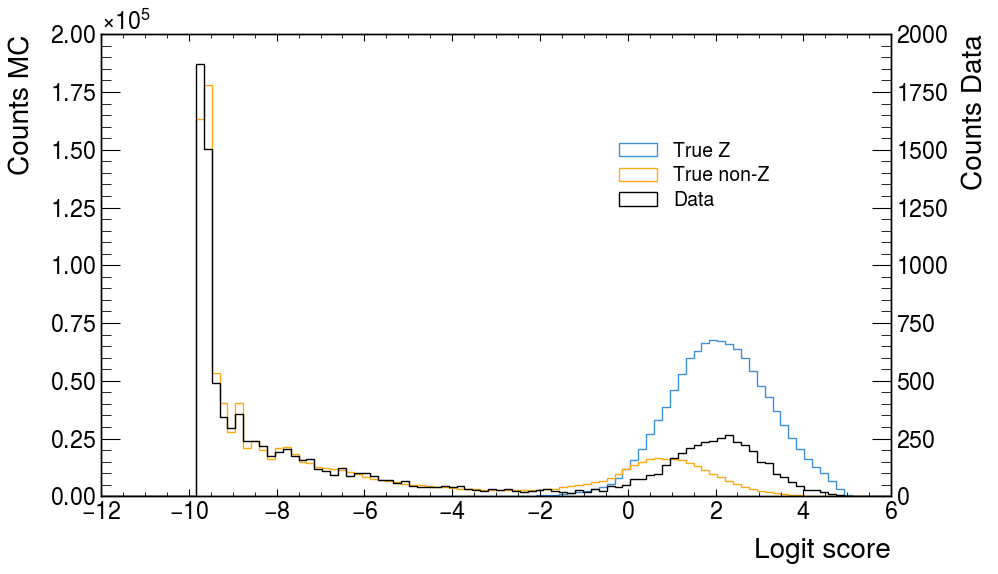

In [234]:
logit_scores = np.log(id_predictions/(1-id_predictions))
logit_scores_data = np.log(pred_score_data/(1-pred_score_data))

fig, ax = plt.subplots(figsize=(10, 6))
bins_signal, edges_signal, _ = ax.hist(logit_scores[y_test==1], bins=100, range=(-12, 6), histtype='step', label='True Z')
bins_bck, edges_bck, _ = ax.hist(logit_scores[y_test==0], bins=100, range=(-12, 6), histtype='step', label='True non-Z')
ax2 = ax.twinx()
bins_data, edges_data, _ = ax2.hist(logit_scores_data, bins=100, range=(-12, 6),color='black', histtype='step', label='Data')
ax.set_xlabel('Logit score')
ax.set_ylabel('Counts MC')
ax2.set_ylabel('Counts Data')
logit_low_lim = -8
logit_high_lim = -7

logit_mask = (logit_scores_data < logit_high_lim) & (logit_scores_data > logit_low_lim)

fig.legend(loc=(0.6, 0.6))

In [235]:
np.sum(bins_signal), np.sum(bins_bck), np.sum(bins_data)

(1097462.0, 1099269.0, 12152.0)

In [236]:

# Define the function to minimize
def function(scale, signaltobackground):
    return np.sum((scale * (bins_signal * signaltobackground + bins_bck) - bins_data)**2)

# Initialize Minuit with the function and initial parameter guesses
m = Minuit(function, scale=1.0, signaltobackground=1.0)

# Perform the minimization
m.migrad()

# Print the best-fit parameters
print(f"Best-fit parameters: scale = {m.values['scale']}, signaltobackground = {m.values['signaltobackground']}")
print(f"Function minimum: {m.fval}")

# Print the errors on the parameters
print(f"Parameter errors: scale = {m.errors['scale']}, signaltobackground = {m.errors['signaltobackground']}")

Best-fit parameters: scale = 0.009603461946598916, signaltobackground = 0.19299354604595048
Function minimum: 258191.31786119574
Parameter errors: scale = 3.7497054254782674e-06, signaltobackground = 0.00047332896810403635


In [237]:
print(f'signal ratio = {m.values["scale"]*m.values["signaltobackground"]}')
print(f'background ratio = {m.values["scale"]*(1-m.values["signaltobackground"])}')

signal ratio = 0.0018534061753914712
background ratio = 0.007750055771207446


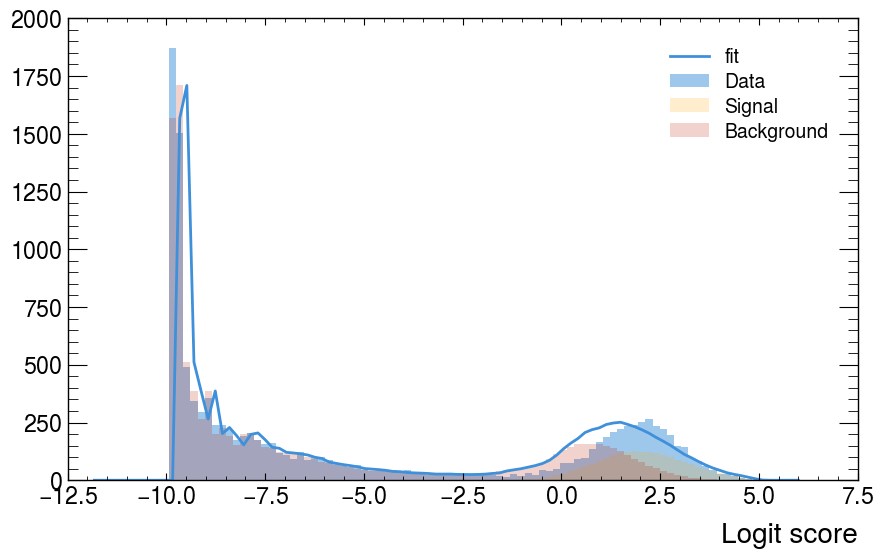

In [238]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(edges_bck[1:], m.values['scale'] * (bins_signal * m.values['signaltobackground'] + bins_bck), label='fit')
ax.bar(edges_data[:-1], bins_data, width=np.diff(edges_data), alpha=0.5, label='Data')
ax.bar(edges_signal[:-1], m.values['scale'] * m.values['signaltobackground'] * bins_signal, width=np.diff(edges_signal), alpha=0.2, label='Signal')
ax.bar(edges_bck[:-1], m.values['scale'] * bins_bck, width=np.diff(edges_bck), alpha=0.2, label='Background')
ax.set_xlabel('Logit score')
ax.legend()

In [239]:
print(tuned_cut)
print(tuned_cut_FN)
print(tuned_cut_FP)

0.5655481224483226
0.6523659637587892
0.5655481224483226


no


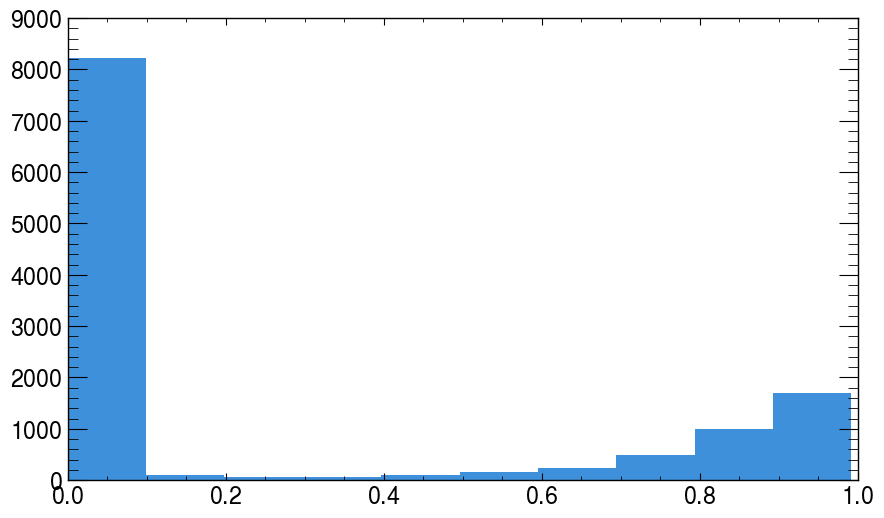

In [240]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(pred_score_data)
print('no')

In [241]:
print(pred_score_data)

[8.68502790e-01 4.57366696e-01 9.09519289e-01 ... 7.98477704e-01
 9.71030455e-01 1.76743172e-04]


5000


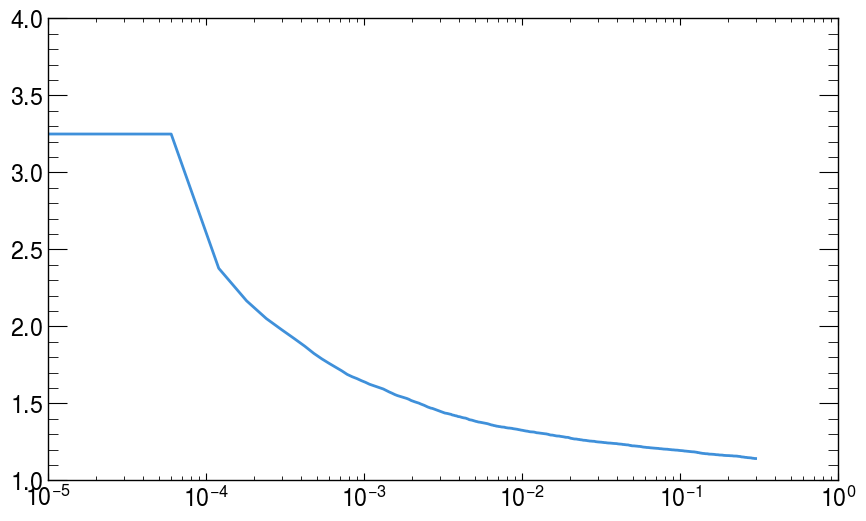

In [242]:
cut_test = np.linspace(0, 0.3, 5000)
num_sig_data = np.zeros_like(cut_test)
for i in range(len(cut_test)):
    num_sig_data[i] = np.sum((pred_score_data > cut_test[i]))

print(np.sum(num_sig_data > np.sum(actual_data["EventInfo.cutflow"] >= 14)))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(cut_test, num_sig_data/np.sum(actual_data["EventInfo.cutflow"] >= 14), label='Data')
ax.set_xscale('log')

Number of Z events in new cut: 3477
Number of Z events according to ATLAS: 3282
no


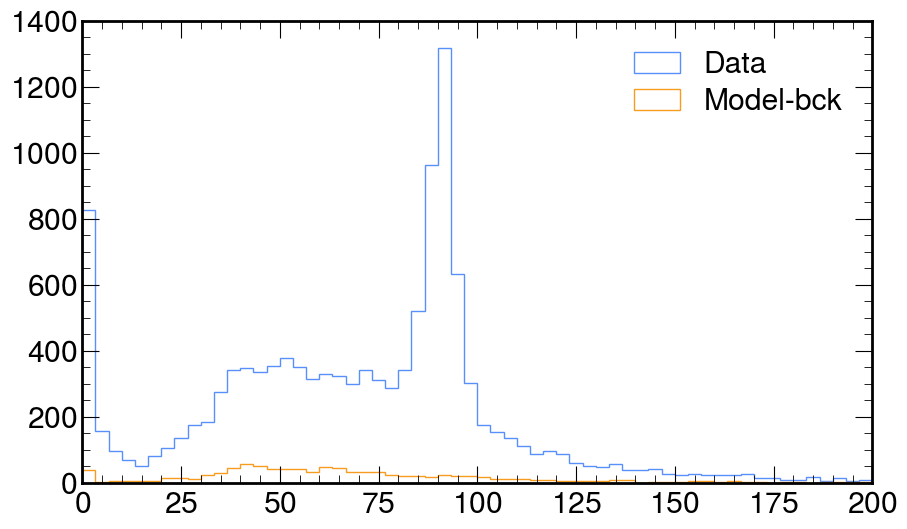

In [ ]:
model_data_pred = pred_score_data > tuned_cut_FP

print(f'Number of Z events in new cut: {np.sum(model_data_pred)}')
print(f'Number of Z events according to ATLAS: {np.sum(actual_data["EventInfo.cutflow"] >= 14)}')

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(actual_data['ll_m'], bins=60, range=(0, 200), histtype='step', label='Data',density=False)
# ax.hist(actual_data['ll_m'][actual_data['EventInfo.cutflow'] >= 14], bins=60, range=(0, 200), histtype='step', label='ATLAS-sig')
# ax.hist(actual_data['ll_m'][actual_data['EventInfo.cutflow'] < 14], bins=60, range=(0, 200), histtype='step', label='ATLAS-bck')
# ax.hist(actual_data['ll_m'][model_data_pred], bins=60, range=(0, 200), histtype='step', label='Model-sig')
# ax.hist(actual_data['ll_m'][~model_data_pred], bins=60, range=(0, 200), histtype='step', label='Model-bck')
ax.hist(actual_data['ll_m'][logit_mask], bins=60, range=(0, 200), histtype='step', label='Model-bck',density=False)

ax.legend()
print('no')

no


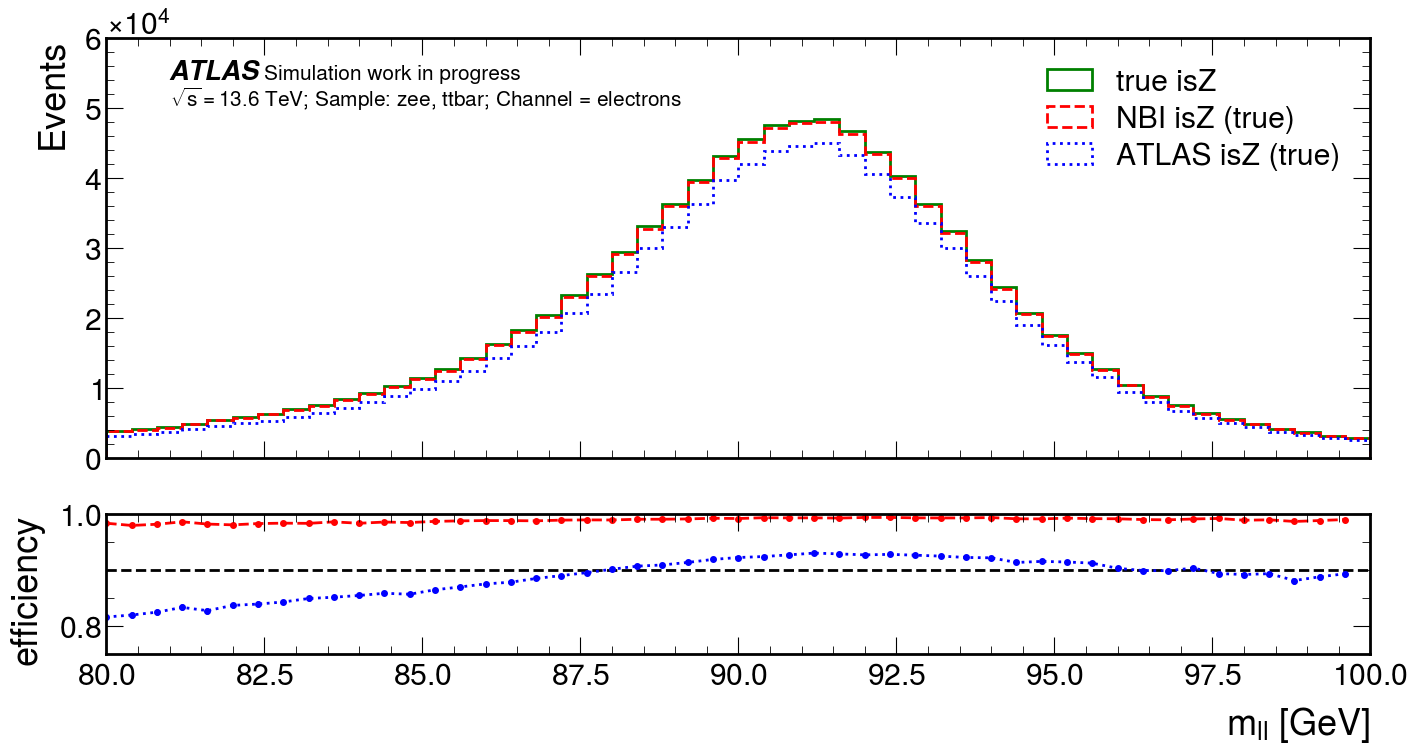

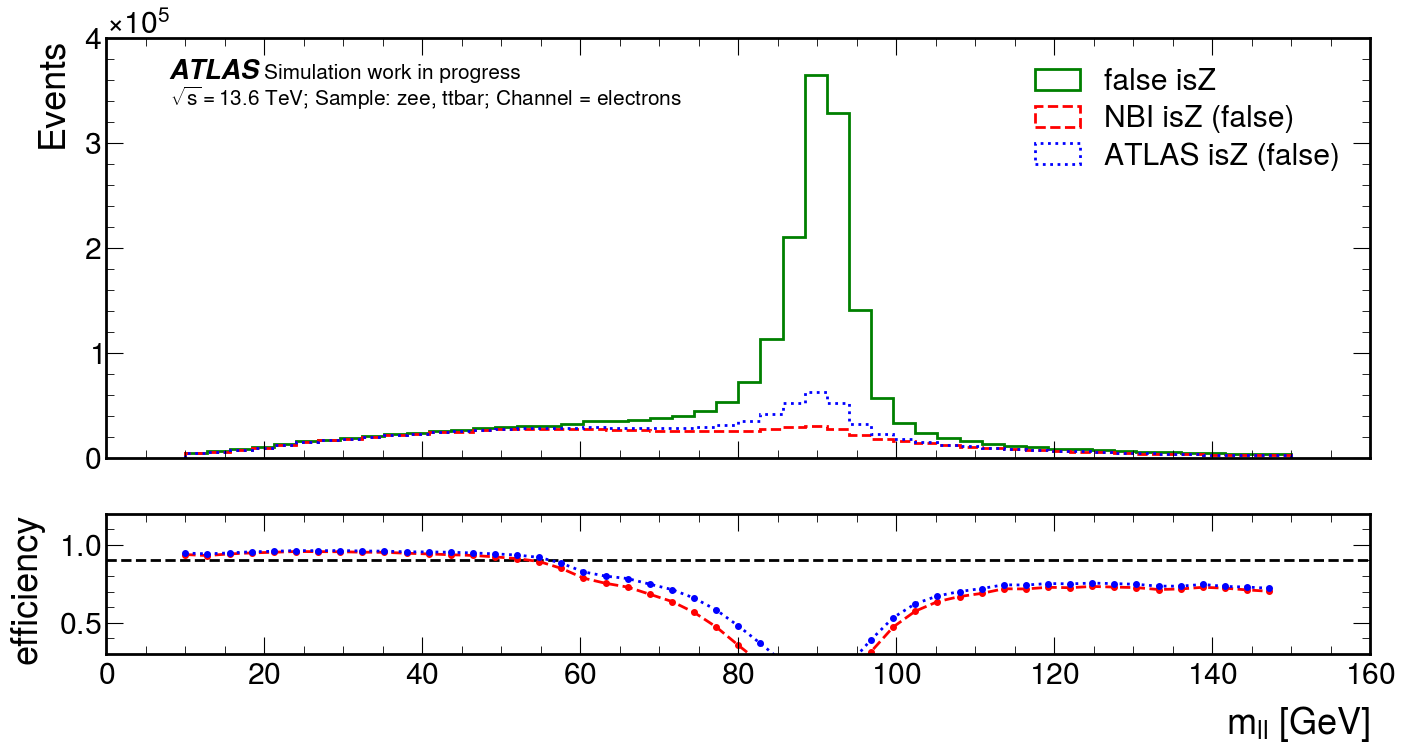

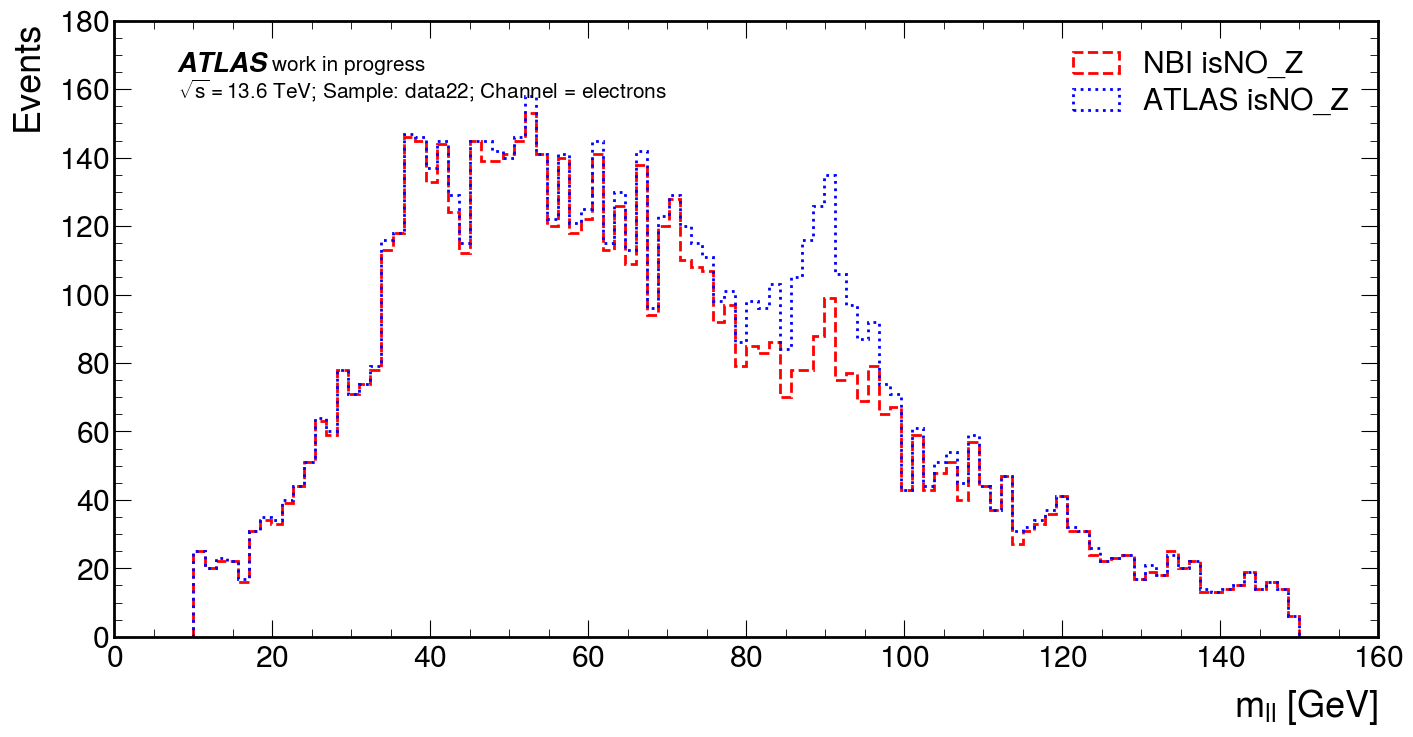

In [284]:

tuned_cut_FP = np.sort(id_predictions[y_test==0])[-int(1.3*num_FP_ATLAS)]

NBI_sig = id_predictions > tuned_cut_FP
NBI_sig_data = pred_score_data > tuned_cut_FP

sample_name = 'zee, ttbar; Channel = electrons' #Zmumu_PhPy ggZH_Zmumug

n_bins = 50

plt.style.use([hep.style.ROOT, hep.style.firamath])
fig, ax = plt.subplots(2,1, figsize=(16, 8), height_ratios=[3, 1])
counts_true, bins_true, _ = ax[0].hist(X_test['ll_m'][X_test['truth_from_Z']==1], bins=n_bins, range=(80, 100),linewidth=2, histtype='step', label='true isZ', color='green', linestyle='solid')
counts_trueandmodel, bins_trueandmodel, _ = ax[0].hist(X_test['ll_m'][(NBI_sig==1) & (X_test['truth_from_Z']==1) ], bins=n_bins, range=(80, 100),linewidth=2, histtype='step', label='NBI isZ (true)', color='red', linestyle='dashed')
counts_trueandATLAS, bins_TrueandATLAS, _ = ax[0].hist(X_test['ll_m'][(X_test['EventInfo.cutflow']>13) & (X_test['truth_from_Z']==1)], bins=n_bins,linewidth=2, range=(80, 100), histtype='step', label='ATLAS isZ (true)', color='blue', linestyle='dotted')
ax[0].legend(loc='upper right')
hep.atlas.label(data=False, label="work in progress", fontsize=15, ax= ax[0],rlabel=f"$ \sqrt{{s}} = 13.6$ TeV; Sample: {sample_name}")
ax[0].set_xticklabels([])
eff_model = counts_trueandmodel/counts_true
eff_ATLAS = counts_trueandATLAS/counts_true

uncertainty_model = np.sqrt(eff_model*(1-eff_model)/counts_true)
uncertainty_ATLAS = np.sqrt(eff_ATLAS*(1-eff_ATLAS)/counts_true)

ax[1].errorbar(bins_true[:-1], eff_model, yerr=uncertainty_model, fmt='.', label='NBI', color='red', linestyle='dashed')
ax[1].errorbar(bins_true[:-1], eff_ATLAS, yerr=uncertainty_ATLAS, fmt='.', label='ATLAS', color='blue', linestyle='dotted')
ax[1].set_xlabel('$m_{ll}$ [GeV]')
ax[1].set_ylabel('efficiency')
ax[0].set_ylabel('Events')
ax[1].set_ylim(0.75,1)
ax[1].axhline(0.9, color='black', linestyle='dashed')










plt.style.use([hep.style.ROOT, hep.style.firamath])
fig, ax = plt.subplots(2,1, figsize=(16, 8), height_ratios=[3, 1])
counts_true, bins_true, _ = ax[0].hist(X_test['ll_m'], bins=n_bins, range=(10, 150),linewidth=2, histtype='step', label='false isZ', color='green', linestyle='solid')
counts_trueandmodel, bins_trueandmodel, _ = ax[0].hist(X_test['ll_m'][(NBI_sig==0)], bins=n_bins, range=(10, 150),linewidth=2, histtype='step', label='NBI isZ (false)', color='red', linestyle='dashed')
counts_trueandATLAS, bins_TrueandATLAS, _ = ax[0].hist(X_test['ll_m'][(X_test['EventInfo.cutflow']<=13)], bins=n_bins,linewidth=2, range=(10, 150), histtype='step', label='ATLAS isZ (false)', color='blue', linestyle='dotted')
ax[0].legend(loc='upper right')
hep.atlas.label(data=False, label="work in progress", fontsize=15, ax= ax[0],rlabel=f"$ \sqrt{{s}} = 13.6$ TeV; Sample: {sample_name}")
ax[0].set_xticklabels([])
eff_model = counts_trueandmodel/counts_true
eff_ATLAS = counts_trueandATLAS/counts_true

uncertainty_model = np.sqrt(eff_model*(1-eff_model)/counts_true)
uncertainty_ATLAS = np.sqrt(eff_ATLAS*(1-eff_ATLAS)/counts_true)

ax[1].errorbar(bins_true[:-1], eff_model, yerr=uncertainty_model, fmt='.', label='NBI', color='red', linestyle='dashed')
ax[1].errorbar(bins_true[:-1], eff_ATLAS, yerr=uncertainty_ATLAS, fmt='.', label='ATLAS', color='blue', linestyle='dotted')
ax[1].set_xlabel('$m_{ll}$ [GeV]')
ax[1].set_ylabel('efficiency')
ax[1].set_ylim(0.3,1.2)
ax[1].axhline(0.9, color='black', linestyle='dashed')

# ax[0].set_title('Zmm model on Zmm data')
ax[0].set_ylabel('Events')


sample_name = 'data22; Channel = electrons' #Zmumu_PhPy ggZH_Zmumug

n_bins = 100
plt.style.use([hep.style.ROOT, hep.style.firamath])
fig, ax = plt.subplots( figsize=(16, 8))
# ax.hist(Data['ll_m'], bins=n_bins, range=(10, 150),linewidth=2, histtype='step', label='true isZ', color='green', linestyle='solid')
ax.hist(actual_data['ll_m'][~NBI_sig_data], bins=n_bins, range=(10, 150),linewidth=2, histtype='step', label='NBI isNO_Z', color='red',linestyle = 'dashed')
ax.hist(actual_data['ll_m'][actual_data['EventInfo.cutflow']<=13], bins=n_bins,linewidth=2, range=(10, 150), histtype='step', label='ATLAS isNO_Z', color='blue', linestyle='dotted')
hep.atlas.label(data=True, label="work in progress", fontsize=15, ax= ax,rlabel=f"$ \sqrt{{s}} = 13.6$ TeV; Sample: {sample_name}")
ax.legend()
ax.set_xlabel('$m_{ll}$ [GeV]')
ax.set_ylabel('Events')


n_bins = 50
fig, 


print('no')

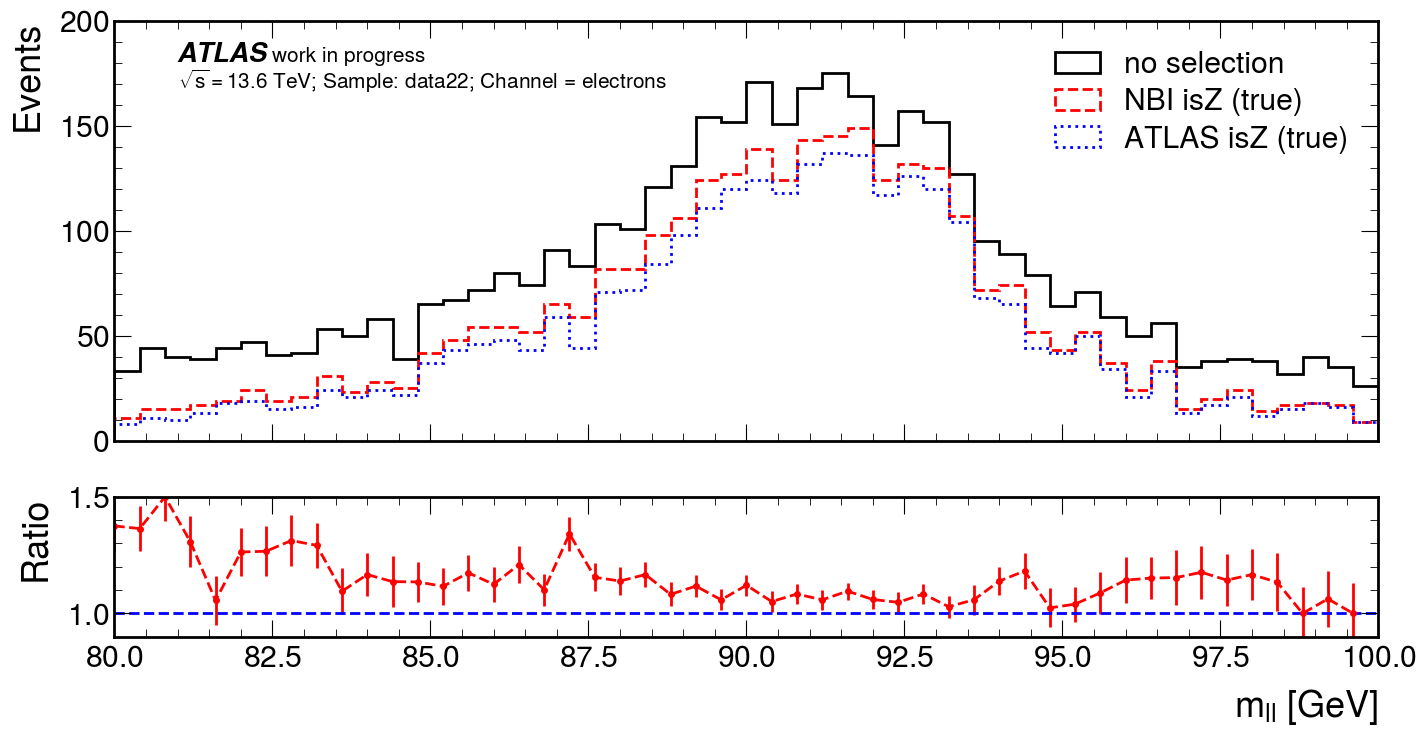

In [285]:

fig, ax = plt.subplots(2,1, figsize=(16, 8), height_ratios=[3, 1])
counts_true, bins_true, _ = ax[0].hist(actual_data['ll_m'], bins=n_bins, range=(80, 100),linewidth=2, histtype='step', label='no selection', color='black', linestyle='solid')
counts_trueandmodel, bins_trueandmodel, _ = ax[0].hist(actual_data['ll_m'][(NBI_sig_data) ], bins=n_bins, range=(80, 100),linewidth=2, histtype='step', label='NBI isZ (true)', color='red', linestyle='dashed')
counts_trueandATLAS, bins_TrueandATLAS, _ = ax[0].hist(actual_data['ll_m'][(actual_data['EventInfo.cutflow']>13)], bins=n_bins,linewidth=2, range=(80, 100), histtype='step', label='ATLAS isZ (true)', color='blue', linestyle='dotted')
ax[0].legend(loc='upper right')
hep.atlas.label(data=True, label="work in progress", fontsize=15, ax= ax[0],rlabel=f"$ \sqrt{{s}} = 13.6$ TeV; Sample: {sample_name}")
ax[0].set_xticklabels([])
eff_model = counts_trueandmodel/counts_true
eff_ATLAS = counts_trueandATLAS/counts_true

uncertainty_model = np.sqrt(eff_model*(1-eff_model)/counts_true)
uncertainty_ATLAS = np.sqrt(eff_ATLAS*(1-eff_ATLAS)/counts_true)

ax[1].errorbar(bins_true[:-1], eff_model/eff_ATLAS, yerr=np.sqrt(uncertainty_model**2+uncertainty_ATLAS**2), fmt='.', label='NBI', color='red', linestyle='dashed')
# ax[1].errorbar(bins_true[:-1], eff_ATLAS, yerr=uncertainty_ATLAS, fmt='.', label='ATLAS', color='blue', linestyle='dotted')
ax[1].set_xlabel('$m_{ll}$ [GeV]')
ax[1].set_ylabel('Ratio')
ax[0].set_ylabel('Events')
ax[1].set_ylim(0.9,1.5)
ax[1].axhline(1, color='blue', linestyle='dashed')

no


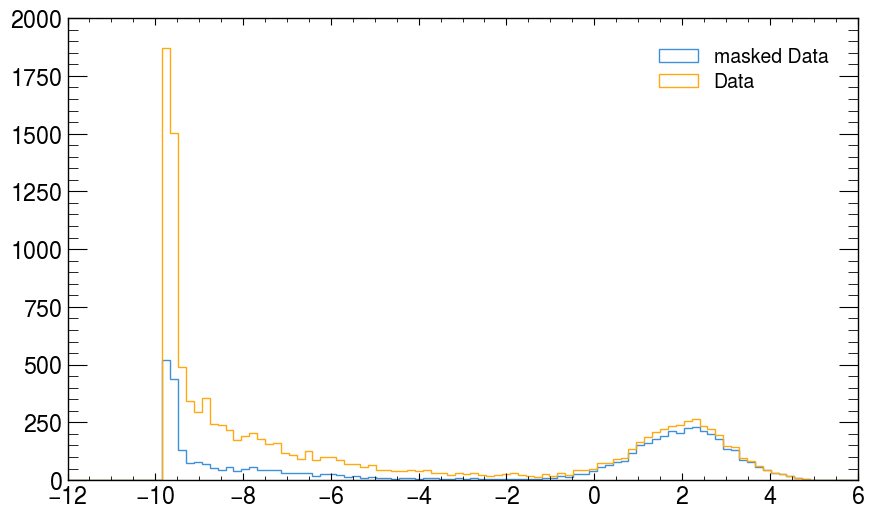

In [52]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(logit_scores_data[(actual_data['ll_m']>70) & (actual_data['ll_m']<110)], bins=100, range=(-12, 6), histtype='step', label='masked Data')
ax.hist(logit_scores_data, bins=100, range=(-12, 6), histtype='step', label='Data')
print('no')
ax.legend()

In [53]:
print(pred_z_param_list)

['l1_iso_score', 'l2_iso_score', 'l1_DNN_pel', 'l1_z0', 'l1_sig_z0', 'l2_DNN_pel', 'l2_z0', 'l2_sig_z0', 'EventInfo.actualIntPerXing', 'EventInfo.averageIntPerXing', 'EventInfo.mu']


In [54]:
print(Data.shape)

cutflow_mask = Data['EventInfo.cutflow'] >= 14

Data['cutflow_mask'] = cutflow_mask

pred_z_param_list_3 = pred_z_param_list_2 + ['cutflow_mask']
print(pred_z_param_list_3)

mask = Data['EventInfo.eventNumber'] % 4 != 0
X_train = Data[mask][pred_z_param_list_3]
y_train = Data[mask]['truth_from_Z']
X_test = Data[~mask]
y_test = Data[~mask]['truth_from_Z']


if os.path.exists(f'z_tuner_noncross_deltaz_cutflow.pkl'):
    with open(f'z_tuner_noncross_deltaz_cutflow.pkl', 'rb') as f:
        tuner3 = pickle.load(f)
        id_predictions3 = tuner3.predict_proba(X_test[pred_z_param_list_3])
else:

    tuner3 = RapidGBMTuner(metric='auc', trials=400, refit=True, verbosity=1, visualization=True, seed=414243)#, grid='h,learning_rate')

    tuner3.fit(X_train, y_train)
    tuner3.fit_optimized(X_train.to_numpy(), y_train.to_numpy())

    with open(f'z_tuner_noncross_deltaz_cutflow.pkl', 'wb') as f:
        pickle.dump(tuner3, f)

    id_predictions3 = tuner3.predict_proba(X_test[pred_z_param_list_3])


(8792502, 44)
['l1_iso_score', 'l2_iso_score', 'l1_DNN_pel', 'l2_DNN_pel', 'EventInfo.actualIntPerXing', 'deltaz', 'sigma_delta_z', 'cutflow_mask']


In [55]:
plt.rcdefaults()
hep.style.use([hep.style.ATLAS])


In [56]:
data_delta_z = np.abs(actual_data['l1_z0'] - actual_data['l2_z0'])
data_sigma_delta_z = np.sqrt(actual_data['l1_sig_z0']**2 + actual_data['l2_sig_z0']**2)
data_cutflow_mask = actual_data['EventInfo.cutflow'] >= 14

actual_data['deltaz'] = data_delta_z
actual_data['sigma_delta_z'] = data_sigma_delta_z
actual_data['cutflow_mask'] = data_cutflow_mask

pred_score3_data = tuner3.predict_proba(actual_data[pred_z_param_list_3])

# pred_3 = 

Text(1, 0, 'Z-ID score')

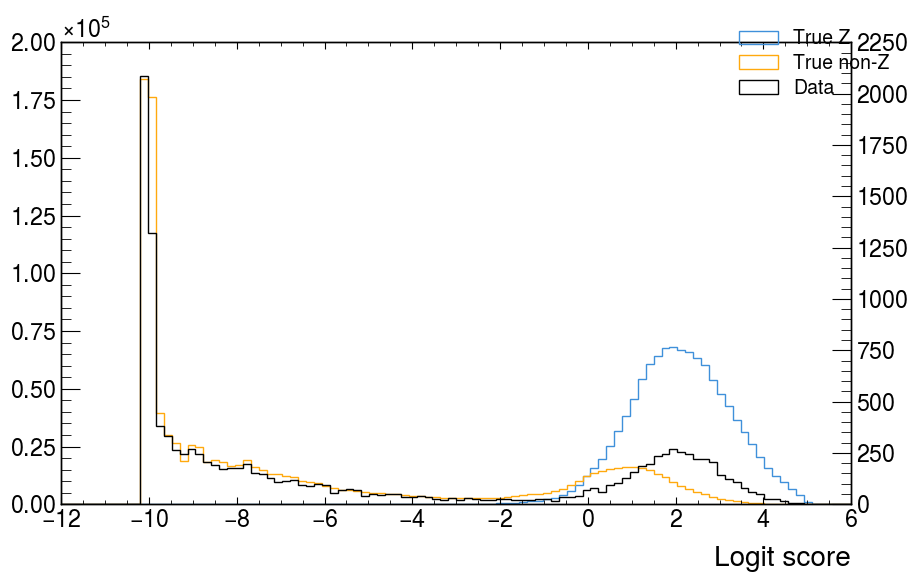

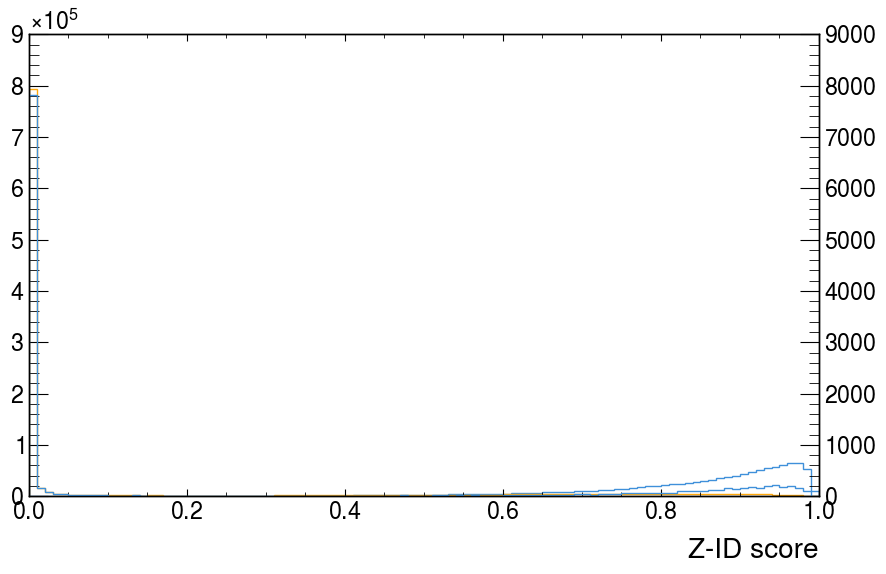

In [57]:
logit_scores_data_3 = np.log(pred_score3_data/(1-pred_score3_data))
logit_scores_3 = np.log(id_predictions3/(1-id_predictions3))
fig, ax = plt.subplots(figsize=(10, 6))
bins_signal, edges_signal, _ = ax.hist(logit_scores_3[y_test==1], bins=100, range=(-12, 6), histtype='step', label='True Z')
bins_bck, edges_bck, _ = ax.hist(logit_scores_3[y_test==0], bins=100, range=(-12, 6), histtype='step', label='True non-Z')
ax2 = ax.twinx()
bins_data, edges_data, _ = ax2.hist(logit_scores_data_3, bins=100, range=(-12, 6),color='black', histtype='step', label='Data')
ax.set_xlabel('Logit score')

fig.legend()

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(id_predictions3[y_test == 1], bins=100, range=(0, 1), histtype='step', label='MC true-Z')
ax.hist(id_predictions3[y_test == 0], bins=100, range=(0, 1), histtype='step', label='MC true-non-Z')
ax2 = ax.twinx()
ax2.hist(pred_score3_data, bins=100, range=(0, 1), histtype='step', label='Data')

ax.set_xlabel('Z-ID score')


0.5605816098067362
no


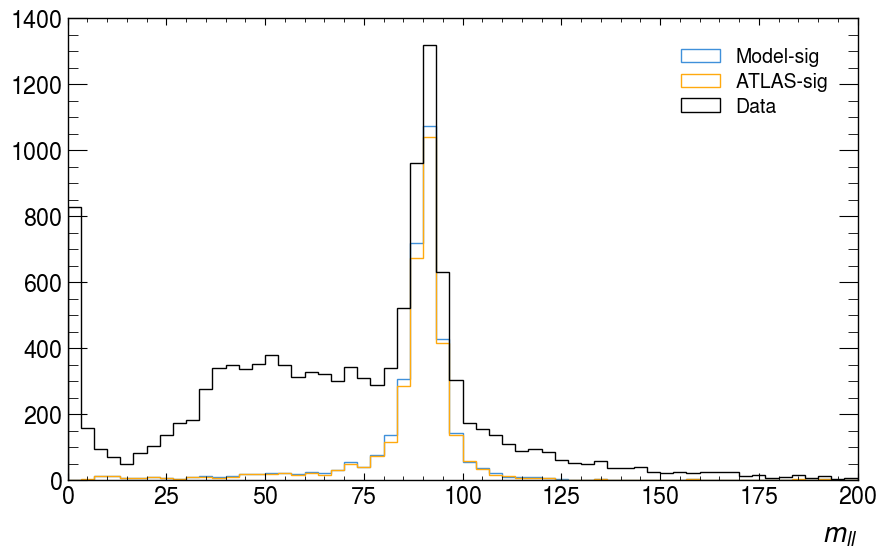

In [58]:
num_FP_ATLAS = len(X_test[(X_test['EventInfo.cutflow'] >= 14) & ~y_test])
FP_CUT_3 = np.sort(id_predictions3[y_test==0])[-num_FP_ATLAS]

print(FP_CUT_3)

model_data_pred_3 = pred_score3_data > FP_CUT_3

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(actual_data['ll_m'][model_data_pred_3], bins=60, range=(0, 200), histtype='step', label='Model-sig')
# ax.hist(actual_data['ll_m'][~model_data_pred_3], bins=60, range=(0, 200), histtype='step', label='Model-bck')
ax.hist(actual_data['ll_m'][actual_data['EventInfo.cutflow'] >= 14], bins=60, range=(0, 200), histtype='step', label='ATLAS-sig')
# ax.hist(actual_data['ll_m'][actual_data['EventInfo.cutflow'] < 14], bins=60, range=(0, 200), histtype='step', label='ATLAS-bck')

ax.hist(actual_data['ll_m'], bins=60, range=(0, 200), color='black', histtype='step', label='Data')
ax.set_xlabel('$m_{ll}$')

ax.legend()
print('no')


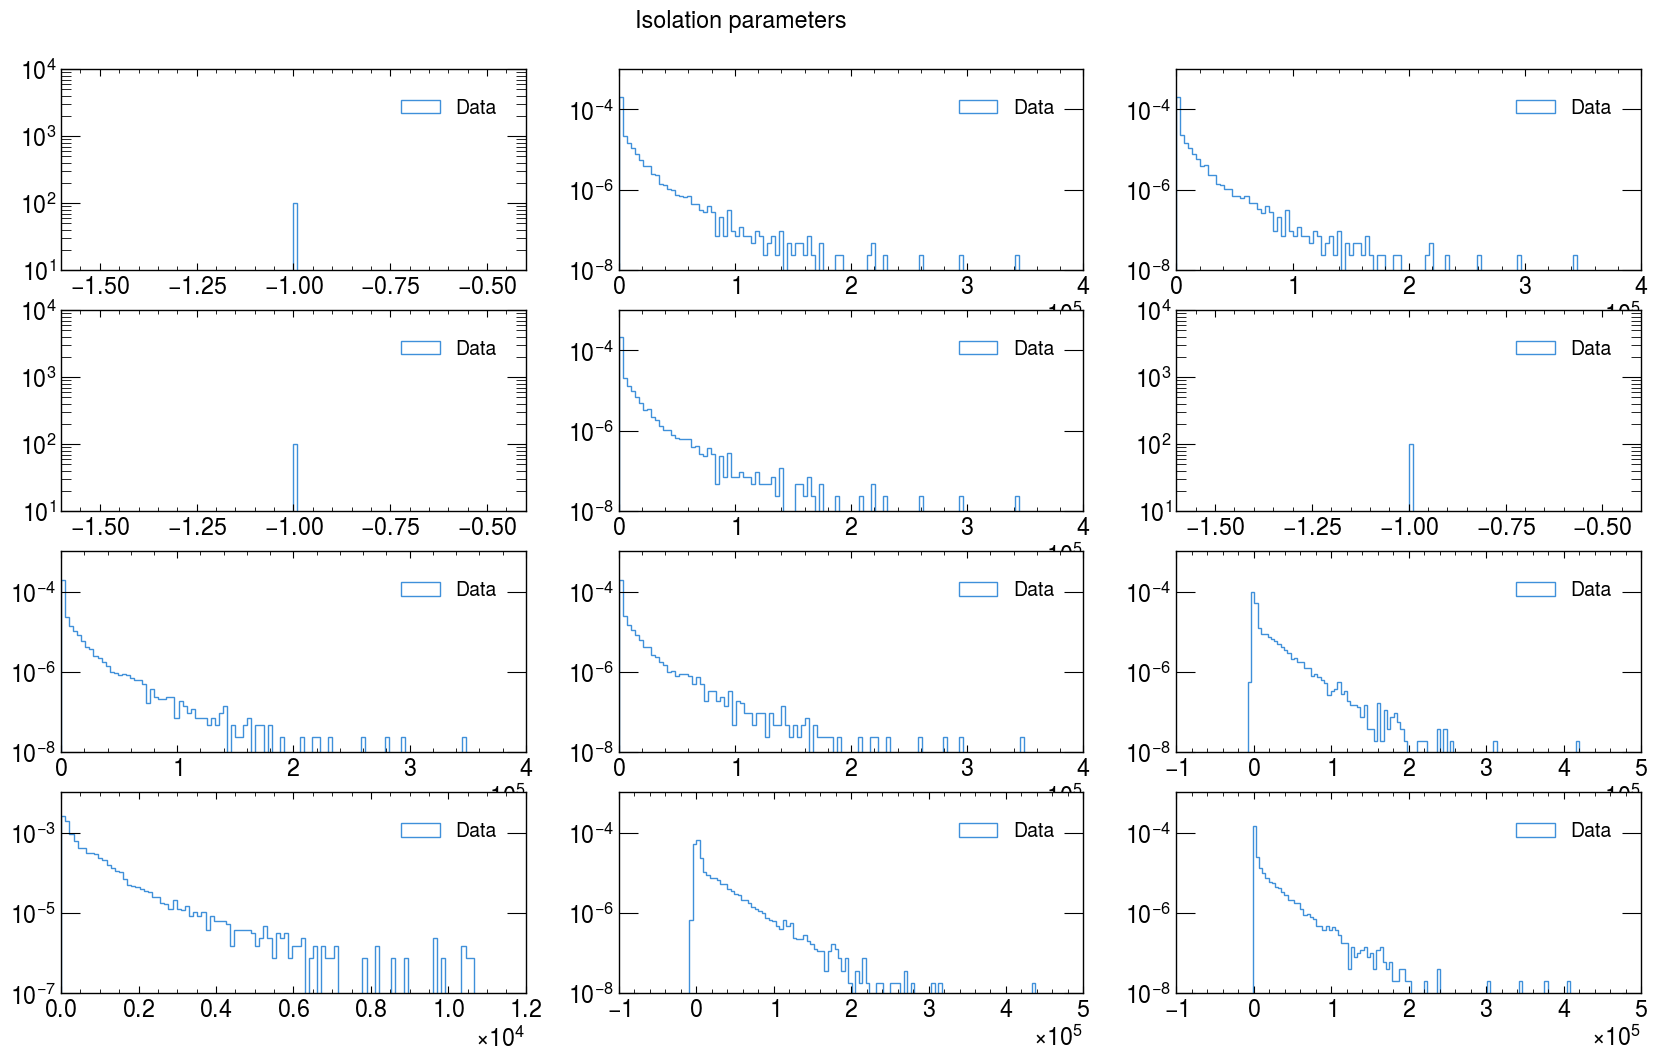

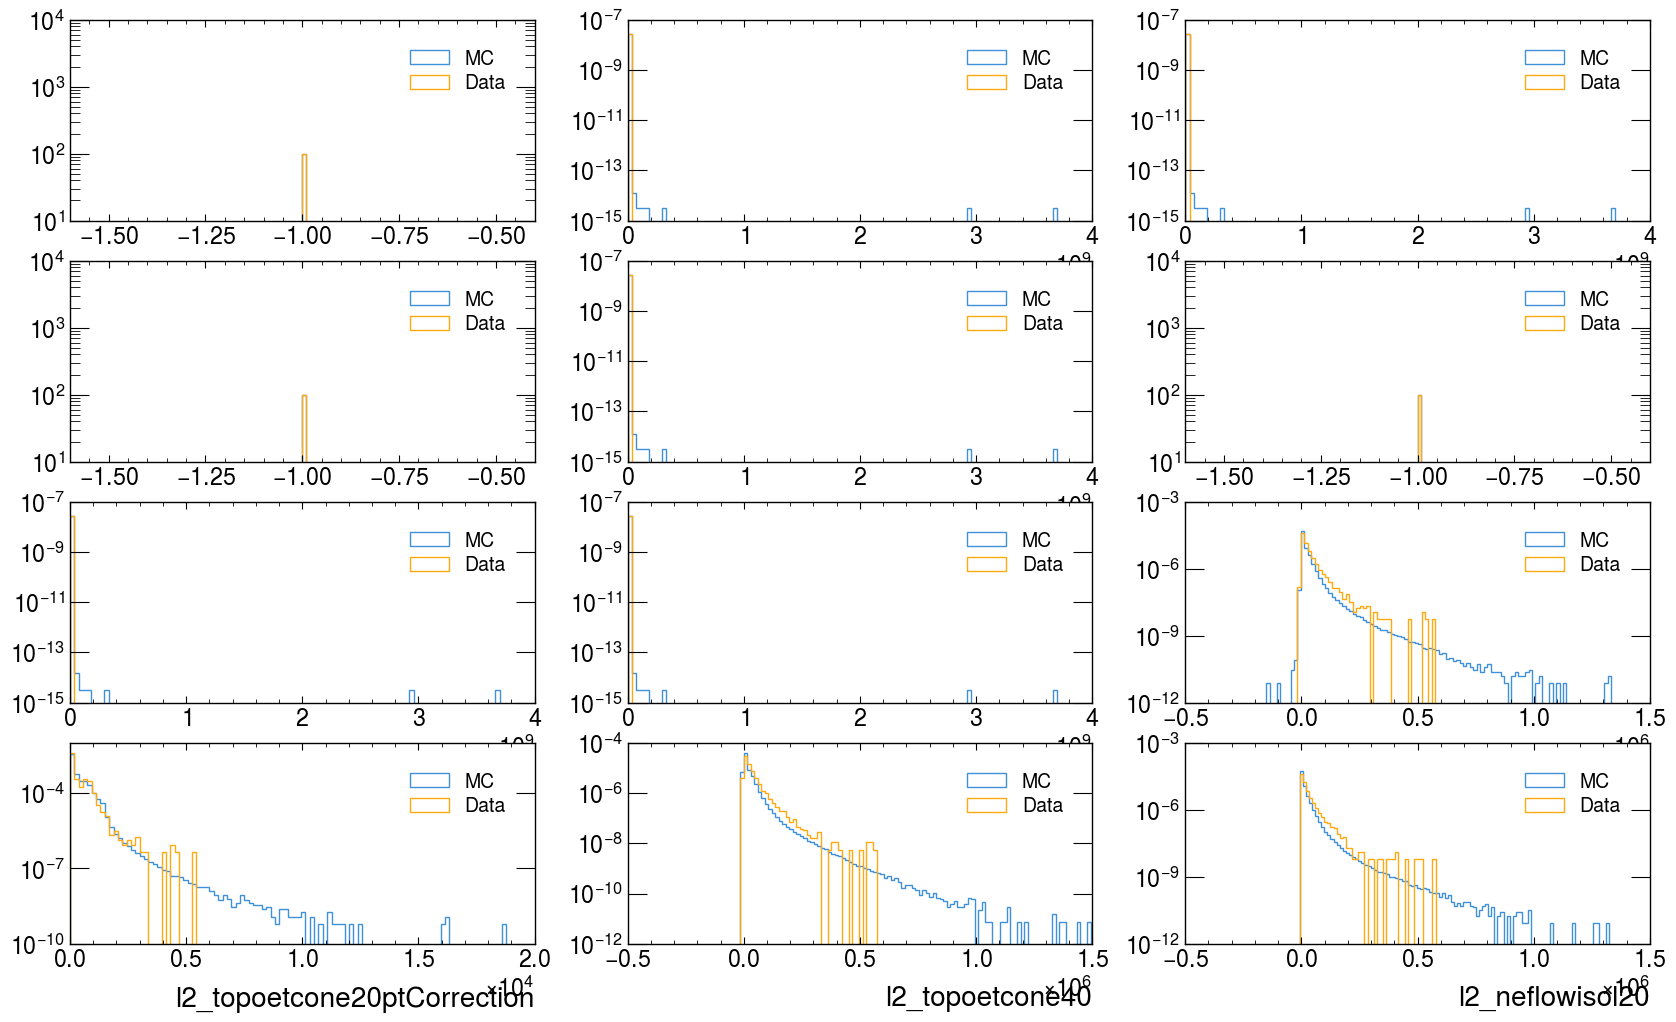

In [59]:
fig, ax = plt.subplots(4,3,figsize=(20, 12))
ax = ax.flatten()
for i in range(len(iso_1_param_list)):
    # fig, ax = plt.subplots(figsize=(10, 6))
    # min_val = np.min(np.min([Data[iso_1_param_list[i]])), np.min(actual_data[iso_1_param_list[i]])])
    # max_val = np.max(np.max([Data[iso_1_param_list[i]])), np.max(actual_data[iso_1_param_list[i]])])
    min_val = np.min(actual_data[iso_1_param_list[i]])
    max_val = np.max(actual_data[iso_1_param_list[i]])
    # ax[i].hist(Data[iso_1_param_list[i]],range=(min_val,max_val), bins=100, histtype='step', label='MC', density=True)
    ax[i].hist(actual_data[iso_1_param_list[i]],range=(min_val,max_val), bins=100, histtype='step', label='Data', density=True)
    # ax[i].set_xlabel(iso_1_param_list[i])
    ax[i].set_yscale('log')
    ax[i].legend()
    # ax[i].set_title(f'{iso_1_param_list[i]}')
fig.suptitle('Isolation parameters')

fig, ax = plt.subplots(4,3,figsize=(20, 12))
ax = ax.flatten()
for i in range(len(iso_2_param_list)):
    
    min_val = np.min([np.min(Data[iso_2_param_list[i]]), np.min(actual_data[iso_2_param_list[i]])])
    max_val = np.max([np.max(Data[iso_2_param_list[i]]), np.max(actual_data[iso_2_param_list[i]])])
    ax[i].hist(Data[iso_2_param_list[i]],range=(min_val,max_val), bins=100, histtype='step', label='MC', density=True)
    ax[i].hist(actual_data[iso_2_param_list[i]],range=(min_val,max_val), bins=100, histtype='step', label='Data', density=True)
    ax[i].set_xlabel(iso_2_param_list[i])
    ax[i].set_yscale('log')
    ax[i].legend()
    # ax[i].set_title(f'{iso_2_param_list[i]}')



In [60]:
print(len(pred_z_param_list))

11


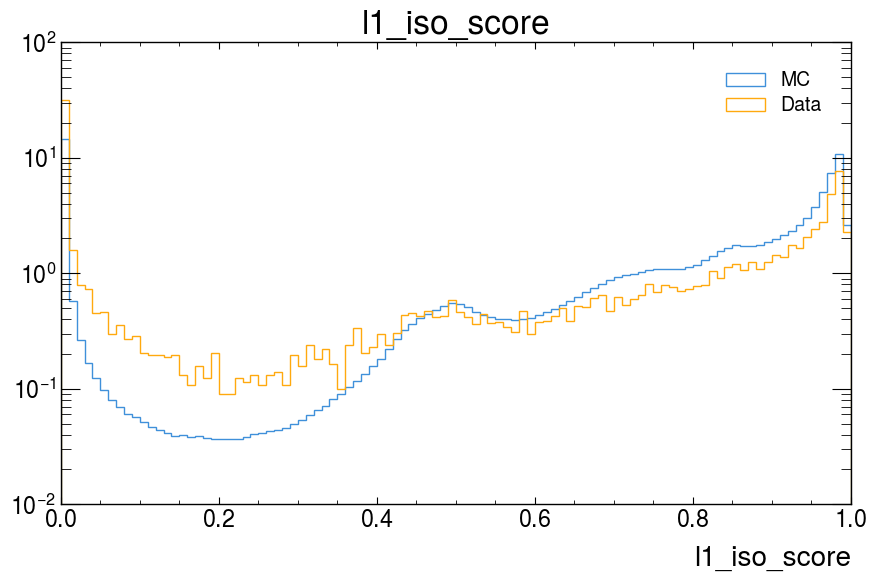

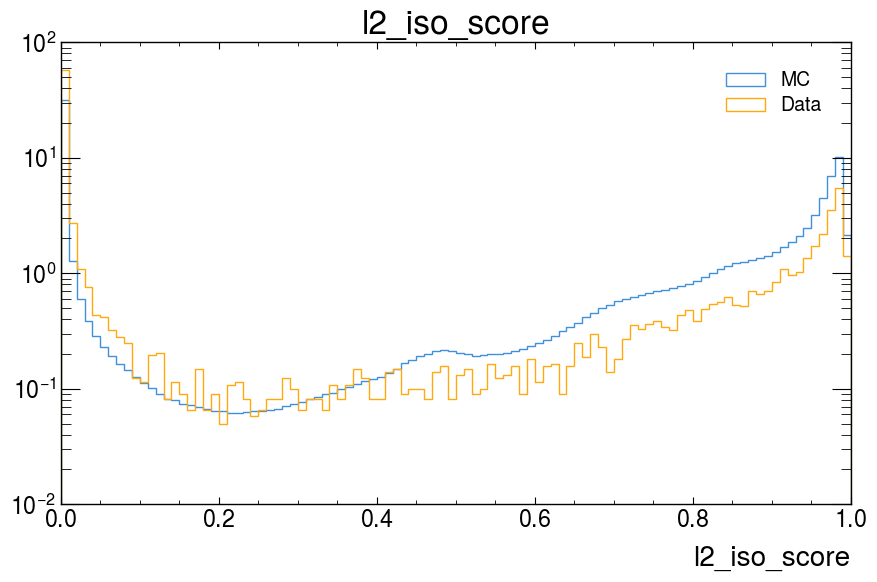

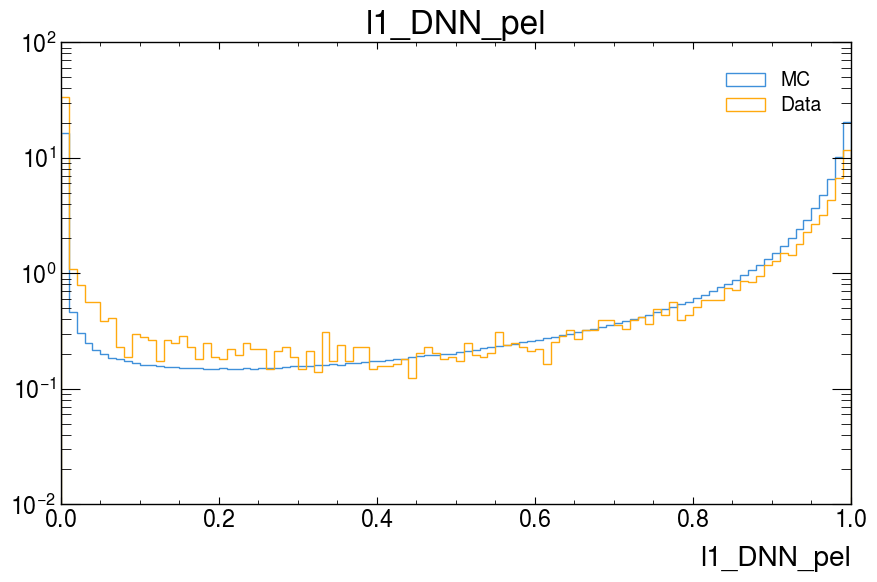

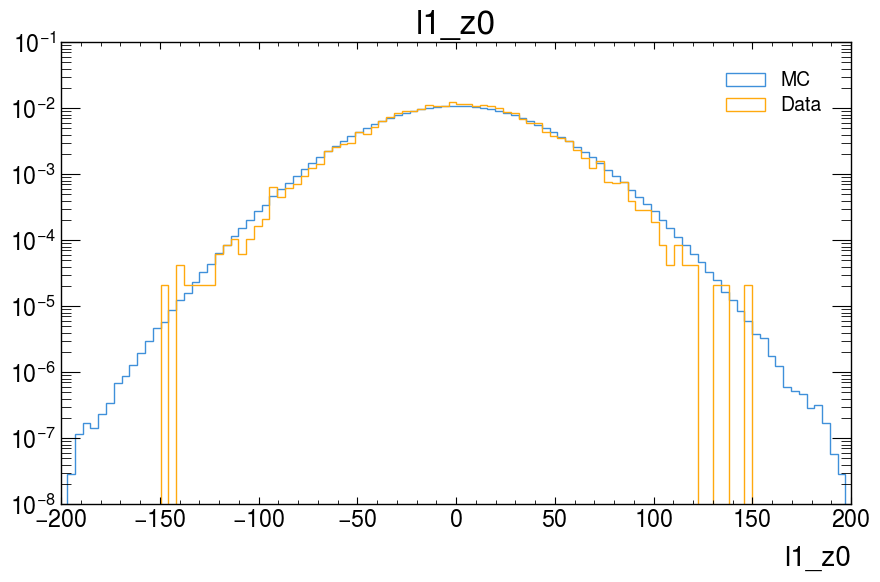

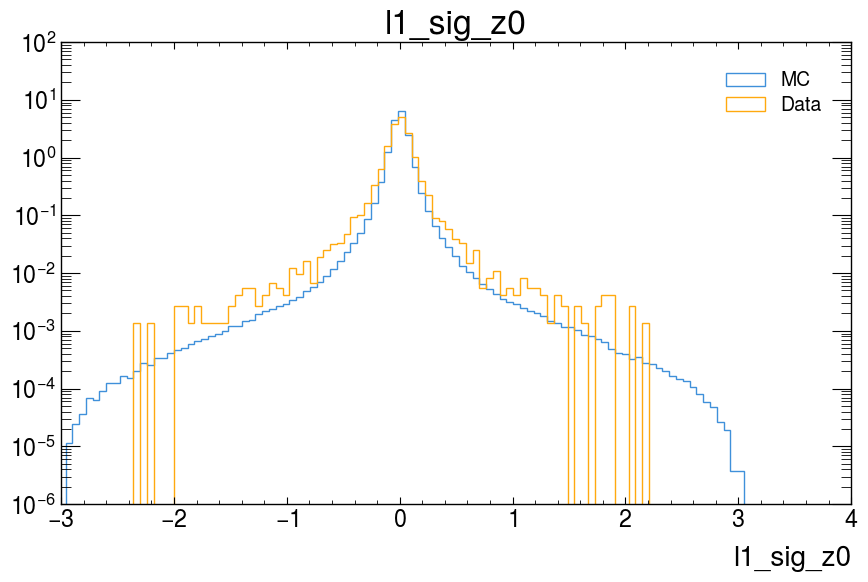

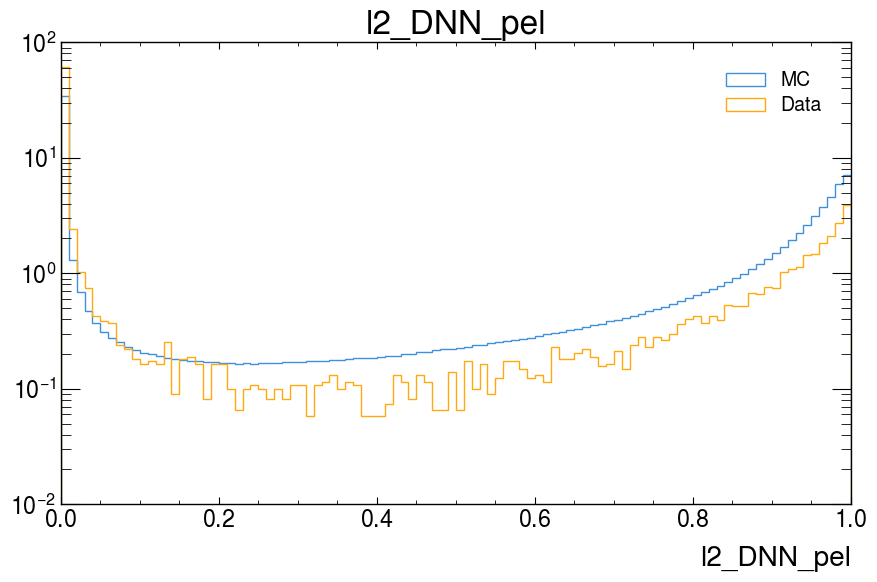

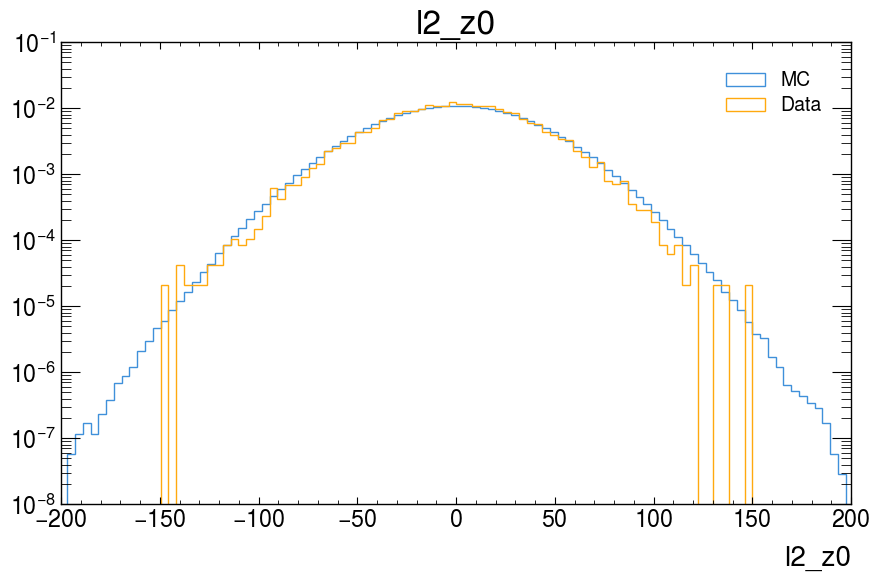

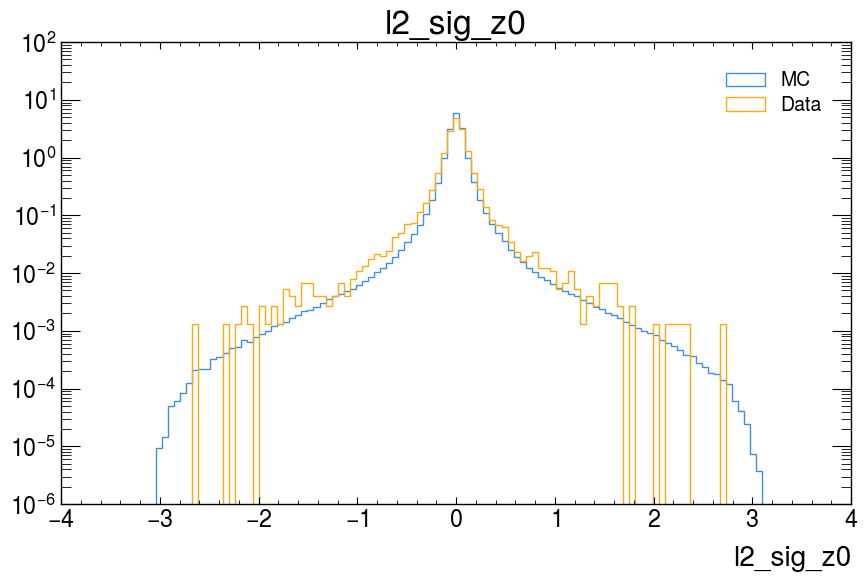

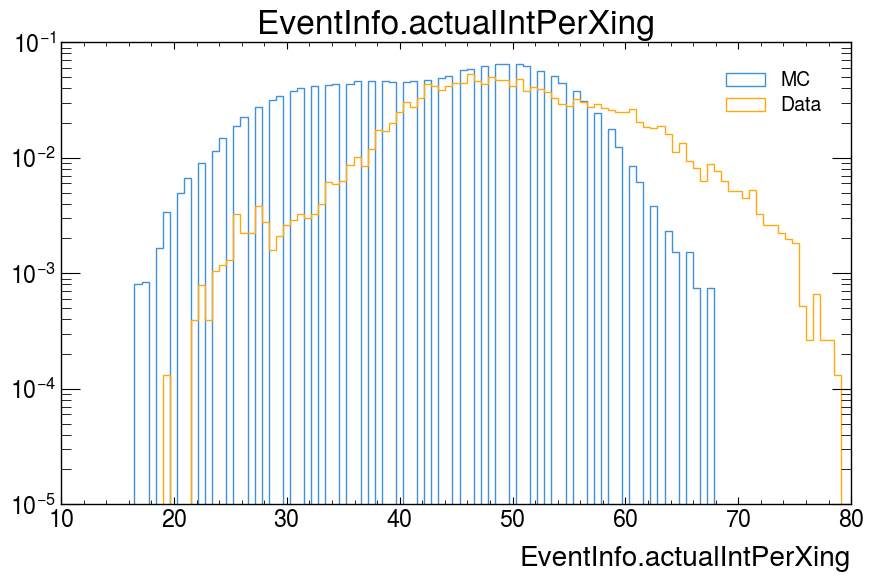

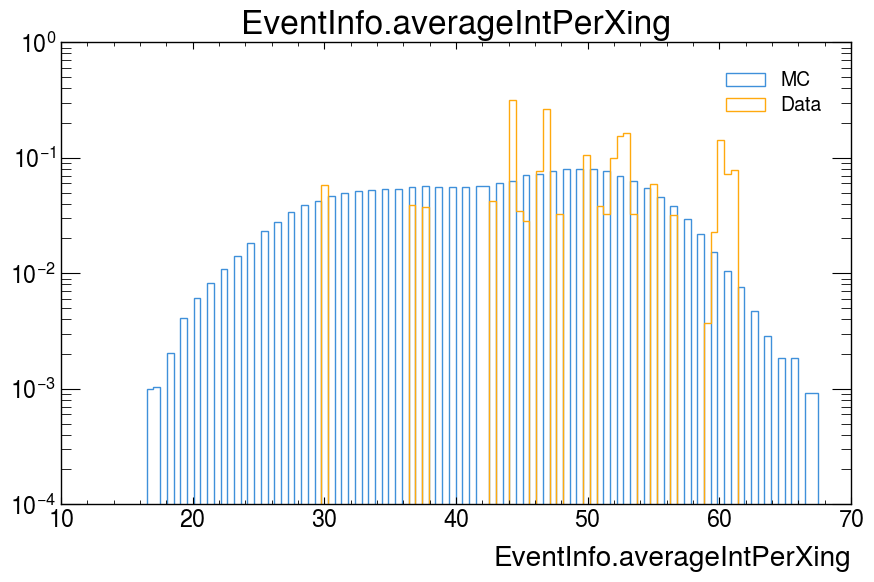

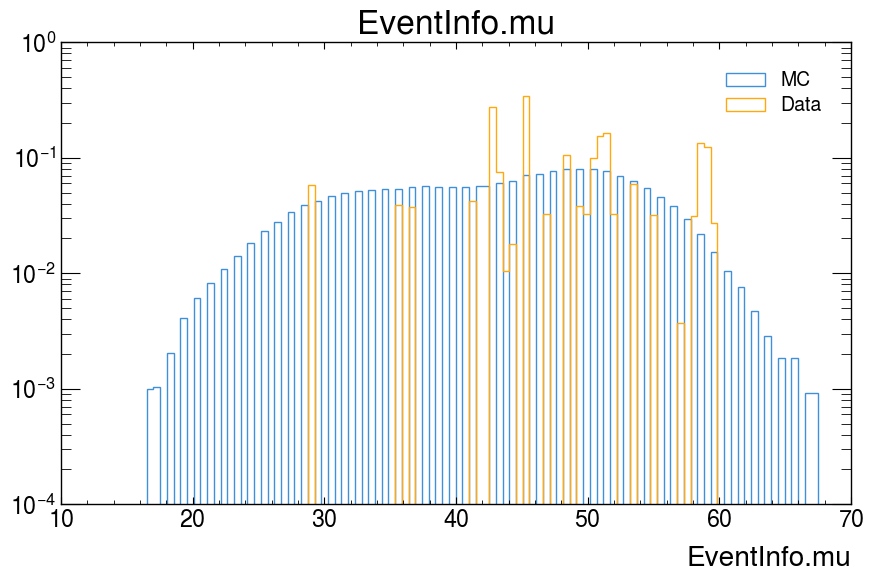

In [61]:
for i in range(len(pred_z_param_list)):
    fig, ax = plt.subplots(figsize=(10, 6))
    min_val = np.min([np.min(Data[pred_z_param_list[i]]), np.min(actual_data[pred_z_param_list[i]])])
    max_val = np.max([np.max(Data[pred_z_param_list[i]]), np.max(actual_data[pred_z_param_list[i]])])
    ax.hist(Data[pred_z_param_list[i]],range=(min_val,max_val), bins=100, histtype='step', label='MC', density=True)
    ax.hist(actual_data[pred_z_param_list[i]],range=(min_val,max_val), bins=100, histtype='step', label='Data', density=True)
    ax.set_xlabel(pred_z_param_list[i])
    ax.set_yscale('log')
    ax.legend()
    ax.set_title(f'{pred_z_param_list[i]}')


In [62]:
#new model 

small_iso_param_list1 = iso_1_param_list[-4:]
small_iso_param_list2 = iso_2_param_list[-4:]

small_iso_1 = np.zeros(Data.shape[0])
small_iso_2 = np.zeros(Data.shape[0])
small_iso_data_1 = np.zeros(actual_data.shape[0])
small_iso_data_2 = np.zeros(actual_data.shape[0])


for i in range(4):
    with open(f'small_param_iso_tuner_{i}.pkl', 'rb') as f:
        small_iso_tuner = pickle.load(f)
    
    mask = Data['EventInfo.eventNumber'] % 4 == i
    mask_data = actual_data['EventInfo.eventNumber'] % 4 == i
    small_iso_1[mask] = small_iso_tuner.predict_proba(Data[mask][small_iso_param_list1])
    small_iso_2[mask] = small_iso_tuner.predict_proba(Data[mask][small_iso_param_list2])
    small_iso_data_1[mask_data] = small_iso_tuner.predict_proba(actual_data[mask_data][small_iso_param_list1])
    small_iso_data_2[mask_data] = small_iso_tuner.predict_proba(actual_data[mask_data][small_iso_param_list2])

Data['l1_small_iso_score'] = small_iso_1
Data['l2_small_iso_score'] = small_iso_2

actual_data['l1_small_iso_score'] = small_iso_data_1
actual_data['l2_small_iso_score'] = small_iso_data_2

small_iso_pred_z = ['l1_small_iso_score', 'l2_small_iso_score']

small_iso_pred_z = small_iso_pred_z + pred_z_param_list_3[2:]




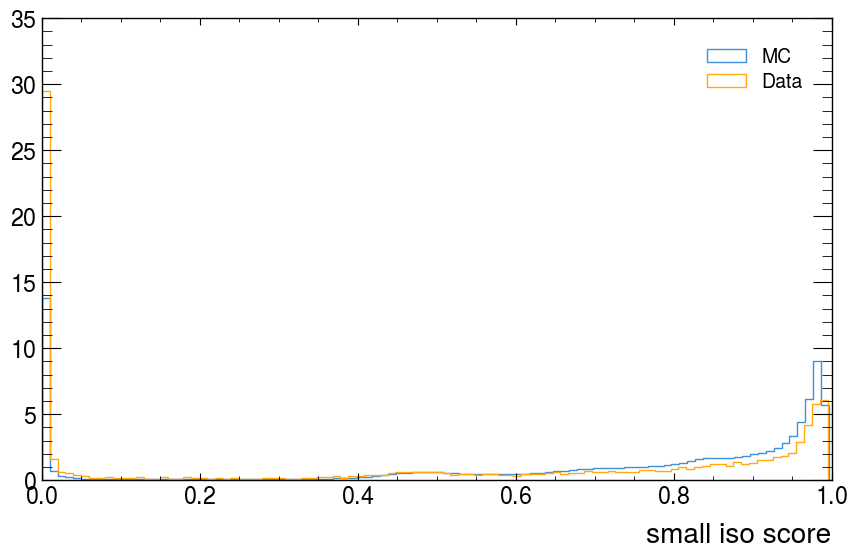

In [63]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(Data['l1_small_iso_score'], bins=100, histtype='step', label='MC', density=True)
ax.hist(actual_data['l1_small_iso_score'], bins=100, histtype='step', label='Data', density=True)
ax.set_xlabel('small iso score')
ax.legend()

In [64]:
# new model:

mask = Data['EventInfo.eventNumber'] % 4 != 0
X_train = Data[mask][small_iso_pred_z]
y_train = Data[mask]['truth_from_Z']
X_test = Data[~mask]
y_test = Data[~mask]['truth_from_Z']

if os.path.exists(f'small_iso_tuner_noncross_deltaz_cutflow.pkl'):
    with open(f'small_iso_tuner_noncross_deltaz_cutflow.pkl', 'rb') as f:
        small_iso_tuner = pickle.load(f)
        id_predictions_small_iso = small_iso_tuner.predict_proba(X_test[small_iso_pred_z])
else:
    small_iso_tuner = RapidGBMTuner(metric='auc', trials=400, refit=True, verbosity=1, visualization=True, seed=414243)
    small_iso_tuner.fit(X_train, y_train)
    small_iso_tuner.fit_optimized(X_train.to_numpy(), y_train.to_numpy())
    with open(f'small_iso_tuner_noncross_deltaz_cutflow.pkl', 'wb') as f:
        pickle.dump(small_iso_tuner, f)

In [65]:
pred_score_small_iso_test = small_iso_tuner.predict_proba(X_test[small_iso_pred_z])
pred_score_small_iso_data = small_iso_tuner.predict_proba(actual_data[small_iso_pred_z])

In [66]:
num_FP_ATLAS = len(X_test[(X_test['EventInfo.cutflow'] >= 14) & ~y_test])
FP_CUT_small_iso = np.sort(id_predictions_small_iso[y_test==0])[-num_FP_ATLAS]
FP_CUT_small_iso_twice_FP = np.sort(id_predictions_small_iso[y_test==0])[-2*num_FP_ATLAS]

print(FP_CUT_small_iso)
print(FP_CUT_small_iso_twice_FP)
pred_small_iso_test = pred_score_small_iso_test > FP_CUT_small_iso
pred_small_iso_data = pred_score_small_iso_data > FP_CUT_small_iso
pred_small_iso_2x_FP = pred_score_small_iso_test > FP_CUT_small_iso_twice_FP
pred_small_iso_2x_FP_data = pred_score_small_iso_data > FP_CUT_small_iso_twice_FP

0.5625327265686927
0.003229386734480325


Text(0, 1, 'Background/ATLAS background')

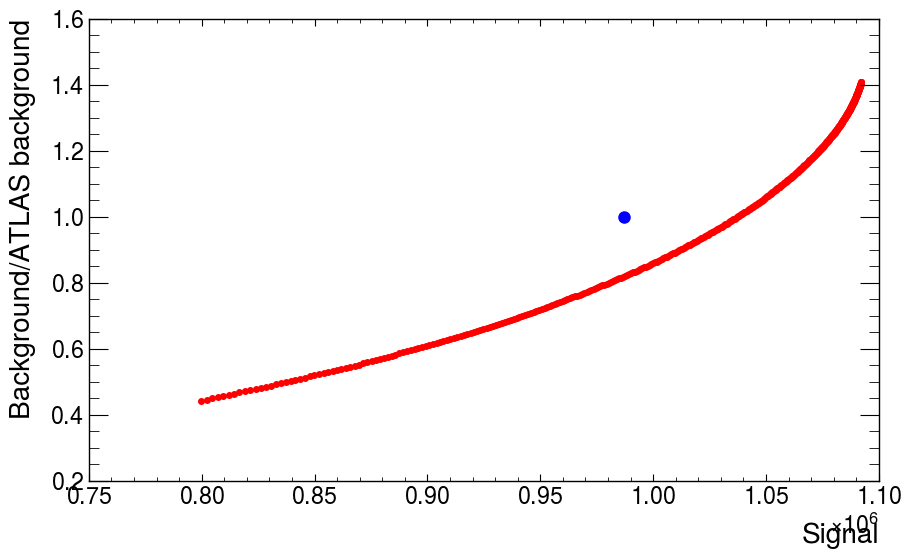

In [67]:
cut_test = np.linspace(0.2, 0.8, 500)

signal_from_cut = np.zeros(len(cut_test))
bck_from_cut = np.zeros(len(cut_test))
for i in range(len(cut_test)):
    cut = cut_test[i]
    signal_from_cut[i] = np.sum((cut < pred_score_small_iso_test) & y_test)
    bck_from_cut[i] = np.sum((cut < pred_score_small_iso_test) & ~y_test)

bck_atlas = np.sum((X_test['truth_from_Z'] == 0) & (X_test['EventInfo.cutflow'] >= 14))
sig_atlas = np.sum((X_test['truth_from_Z'] == 1) & (X_test['EventInfo.cutflow'] >= 14))
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(signal_from_cut, bck_from_cut/bck_atlas,'.', label='Model', color='red')
ax.plot(sig_atlas, 1, 'o', label='ATLAS', color='blue')
ax.set_xlabel('Signal')
ax.set_ylabel('Background/ATLAS background')


Text(0, 1, 'efficiency')

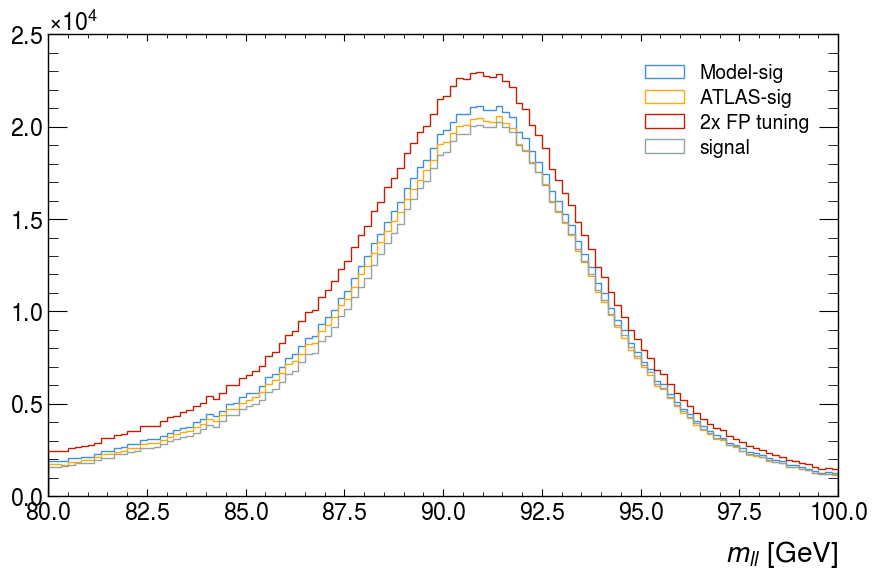

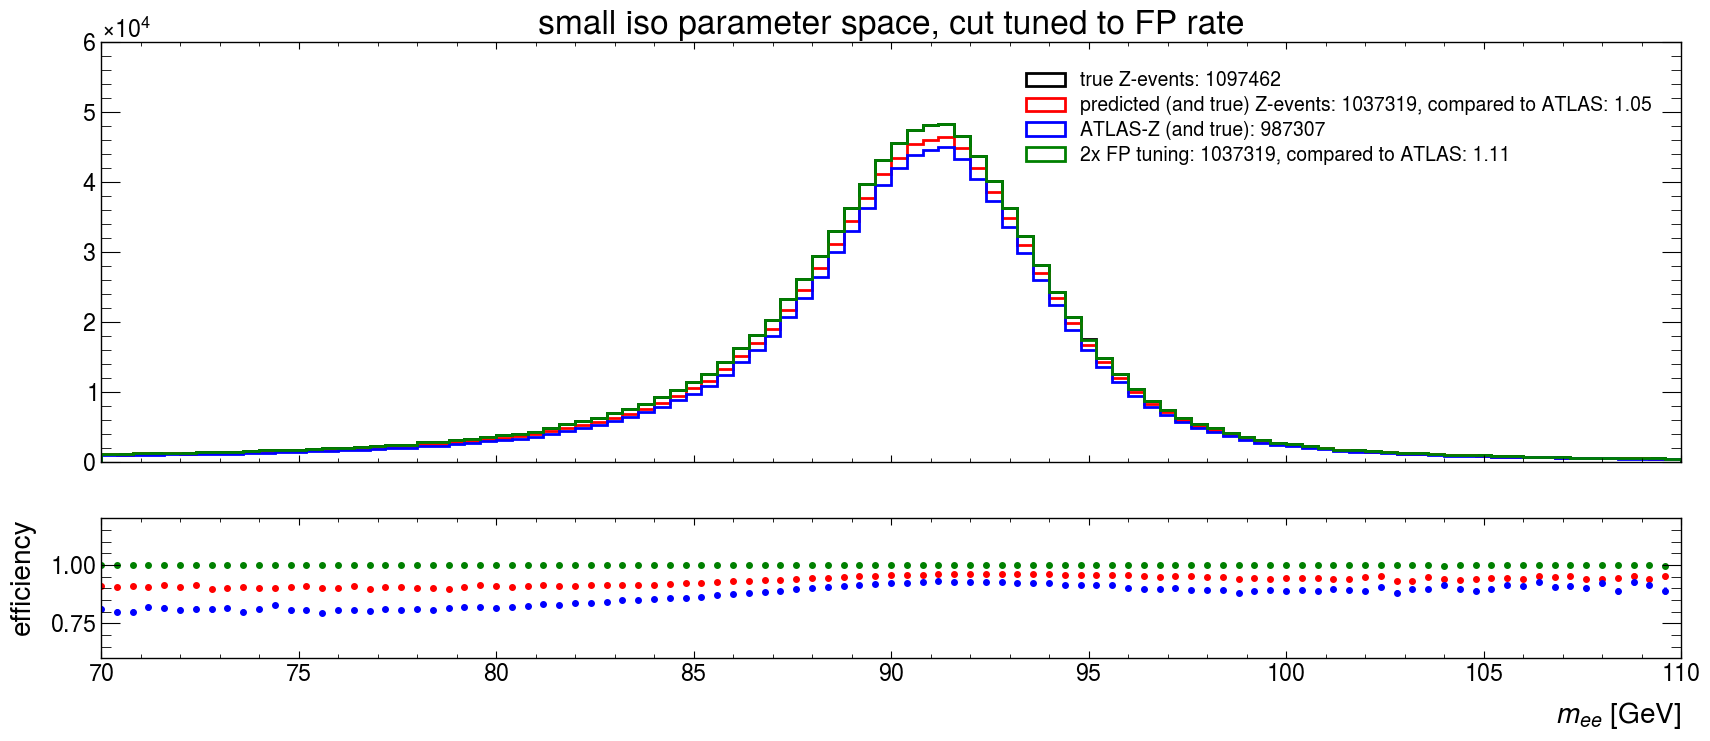

In [68]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(X_test['ll_m'][pred_small_iso_test], bins=120, range=(80, 100), histtype='step', label='Model-sig')
ax.hist(X_test['ll_m'][X_test['EventInfo.cutflow'] >= 14], bins=120, range=(80, 100), histtype='step', label='ATLAS-sig')
ax.hist(X_test['ll_m'][pred_small_iso_2x_FP], bins=120, range=(80, 100), histtype='step', label='2x FP tuning')
ax.hist(X_test['ll_m'][X_test['truth_from_Z'] == 1], bins=120, range=(80, 100), histtype='step', label='signal')
ax.set_xlabel('$m_{ll}$ [GeV]')
ax.legend()
# ax.set_yscale('log')


# plot with efficiency

fig, ax = plt.subplots(2,1, figsize=(20, 8), height_ratios=[3, 1])
counts_true, bins_true, _ = ax[0].hist(X_test['ll_m'][X_test['truth_from_Z']==1], bins=100, range=(70, 110),linewidth=2, histtype='step', label=f'true Z-events: {np.sum(X_test["truth_from_Z"]==1)}', color='black')
counts_trueandmodel, bins_trueandmodel, _ = ax[0].hist(X_test['ll_m'][(pred_small_iso_test) & (X_test['truth_from_Z']==1)], bins=100, range=(70, 110),linewidth=2, histtype='step',color='r', label=f'predicted (and true) Z-events: {np.sum((pred_small_iso_test) & (X_test["truth_from_Z"]==1))}, compared to ATLAS: {np.sum((pred_small_iso_test) & (X_test["truth_from_Z"]==1)) / np.sum((X_test["EventInfo.cutflow"] >= 14) & (X_test["truth_from_Z"]==1)):.2f}')
counts_trueandATLAS, bins_TrueandATLAS, _ = ax[0].hist(X_test['ll_m'][(X_test['EventInfo.cutflow'] >= 14) & (X_test['truth_from_Z']==1)], bins=100,linewidth=2, range=(70, 110), histtype='step',color='b', label=f'ATLAS-Z (and true): {np.sum((X_test["EventInfo.cutflow"] >= 14) & (X_test["truth_from_Z"]==1))}')
counts_twicebck, bins_twicebck, _         = ax[0].hist(X_test['ll_m'][(pred_small_iso_2x_FP) & (X_test['truth_from_Z']==1)], bins=100, range=(70, 110),linewidth=2, histtype='step',color='green', label=f'2x FP tuning: {np.sum((pred_small_iso_test) & (X_test["truth_from_Z"]==1))}, compared to ATLAS: {np.sum((pred_small_iso_2x_FP) & (X_test["truth_from_Z"]==1)) / np.sum((X_test["EventInfo.cutflow"] >= 14) & (X_test["truth_from_Z"]==1)):.2f}')
ax[0].legend(loc='upper right')
ax[0].set_xticklabels([])
eff_model = counts_trueandmodel/counts_true
eff_ATLAS = counts_trueandATLAS/counts_true
eff_2bck = counts_twicebck/counts_true

uncertainty_model = np.sqrt(eff_model*(1-eff_model)/counts_true)
uncertainty_2bck = np.sqrt(eff_2bck*(1-eff_2bck)/counts_true)
uncertainty_ATLAS = np.sqrt(eff_ATLAS*(1-eff_ATLAS)/counts_true)

ax[0].set_title('small iso parameter space, cut tuned to FP rate')

ax[1].errorbar(bins_true[:-1], eff_model, yerr=uncertainty_model, fmt='.', label='model', color='r')
ax[1].errorbar(bins_true[:-1], eff_ATLAS, yerr=uncertainty_ATLAS, fmt='.', label='ATLAS', color='b')
ax[1].errorbar(bins_true[:-1], eff_2bck, yerr=uncertainty_2bck, fmt='.', label='2xbck', color='g')
ax[1].set_xlabel('$m_{ee}$ [GeV]')
ax[1].set_ylabel('efficiency')
# ax[1].set_ylim(0.75,1)





# fig, ax = plt.subplots(figsize=(10, 6))
# ax.hist(actual_data['ll_m'][pred_small_iso_data],range=(0,200), bins=60, histtype='step', label='Model-sig')
# ax.hist(actual_data['ll_m'][actual_data['EventInfo.cutflow'] >= 14],range=(0,200), bins=60, histtype='step', label='ATLAS-sig')
# ax.set_xlabel('$m_{ll}$')
# ax.legend()


In [69]:
gains_mask_2xfp = (pred_small_iso_2x_FP) & (X_test['truth_from_Z']==1) & (X_test['EventInfo.cutflow'] < 14)
print(X_test['EventInfo.cutflow'][gains_mask_2xfp].value_counts())

EventInfo.cutflow
10    110000
Name: count, dtype: int64


In [70]:
mask_both = (pred_small_iso_data) & (actual_data['EventInfo.cutflow'] >= 14)
only_model = (pred_small_iso_data) & ~(actual_data['EventInfo.cutflow'] >= 14)
only_atlas = ~(pred_small_iso_data) & (actual_data['EventInfo.cutflow'] >= 14)
either = (pred_small_iso_data) | (actual_data['EventInfo.cutflow'] >= 14)

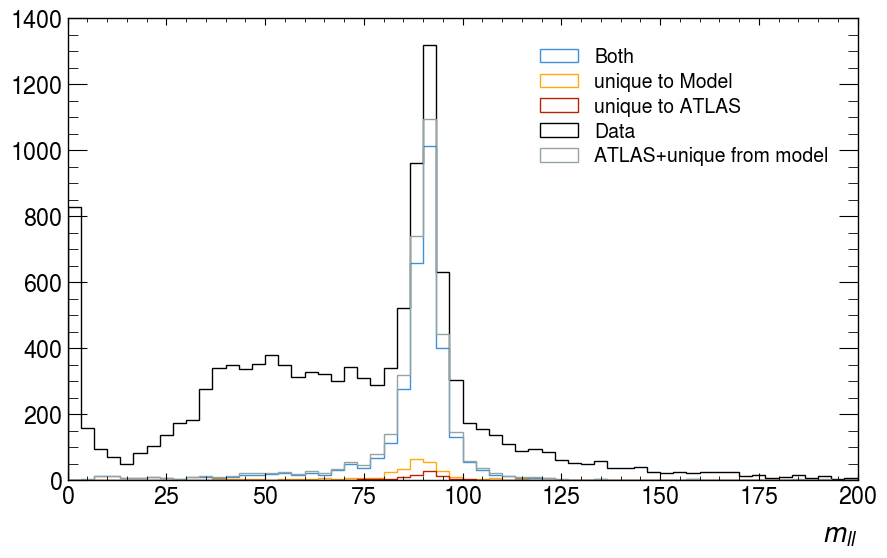

In [71]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(actual_data['ll_m'][mask_both],range=(0,200), bins=60, histtype='step', label='Both')
ax.hist(actual_data['ll_m'][only_model],range=(0,200), bins=60, histtype='step', label='unique to Model')
ax.hist(actual_data['ll_m'][only_atlas],range=(0,200), bins=60, histtype='step', label='unique to ATLAS')
ax.hist(actual_data['ll_m'],color='black' ,range=(0,200), bins=60, histtype='step', label='Data')
ax.hist(actual_data['ll_m'][either],range=(0,200), bins=60, histtype='step', label='ATLAS+unique from model')
ax.set_xlabel('$m_{ll}$')
ax.legend()

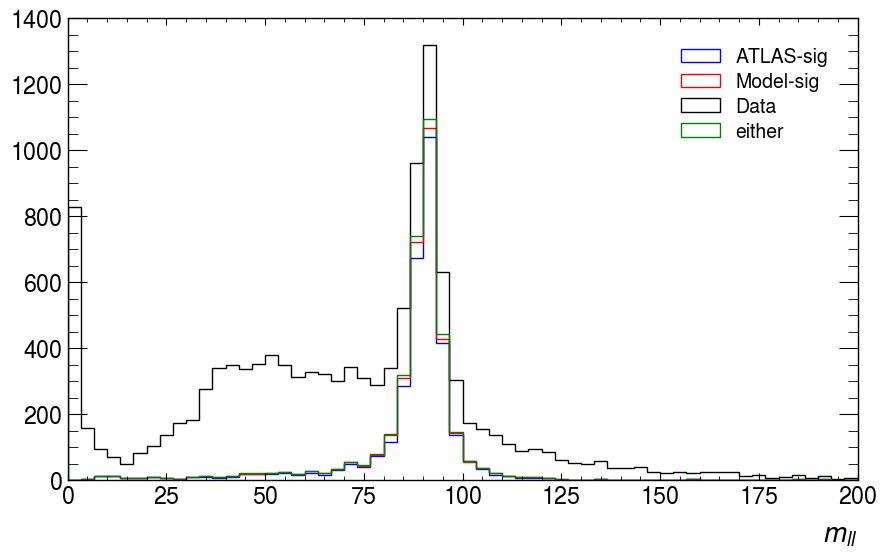

In [72]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(actual_data['ll_m'][actual_data['EventInfo.cutflow'] >= 14],color='blue',range=(0,200), bins=60, histtype='step', label='ATLAS-sig')
ax.hist(actual_data['ll_m'][pred_small_iso_data],color='red',range=(0,200), bins=60, histtype='step', label='Model-sig')
ax.hist(actual_data['ll_m'],color='black',range=(0,200), bins=60, histtype='step', label='Data')
ax.hist(actual_data['ll_m'][either],color='green',range=(0,200), bins=60, histtype='step', label='either')
ax.set_xlabel('$m_{ll}$')
# ax.set_yscale('log')
ax.legend()

In [73]:
num_DP_ATLAS = np.sum((actual_data['EventInfo.cutflow'] < 14))
print(num_DP_ATLAS)

DP_CUT_small_iso = np.sort(pred_score_small_iso_data)[int(num_DP_ATLAS)]
print(f'cut in data: {DP_CUT_small_iso}')

data_tuned_pred = pred_score_small_iso_data > DP_CUT_small_iso

8870
cut in data: 0.6539789879589969


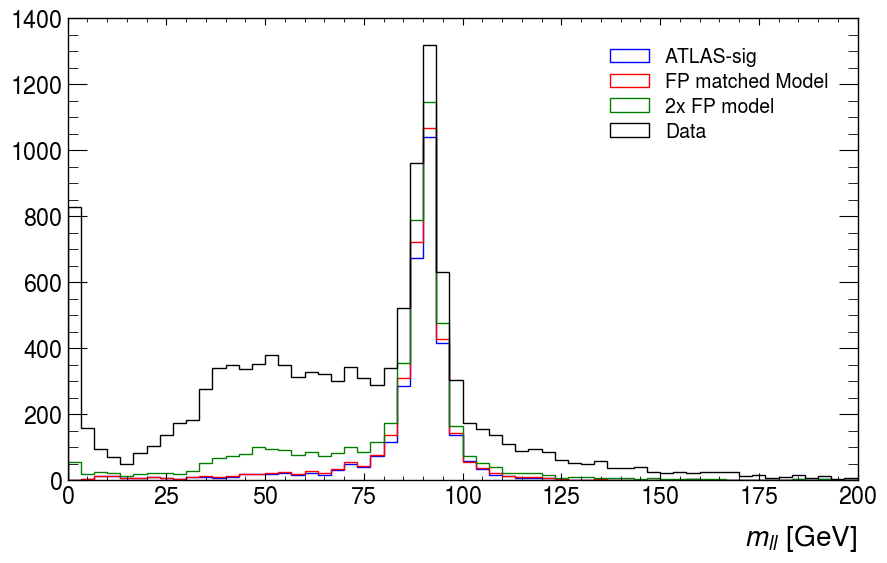

In [74]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(actual_data['ll_m'][actual_data['EventInfo.cutflow'] >= 14],color='blue',range=(0,200), bins=60, histtype='step', label='ATLAS-sig')
ax.hist(actual_data['ll_m'][pred_small_iso_data],color='red',range=(0,200), bins=60, histtype='step', label='FP matched Model')
ax.hist(actual_data['ll_m'][pred_small_iso_2x_FP_data],color='green',range=(0,200), bins=60, histtype='step', label='2x FP model')
ax.hist(actual_data['ll_m'],color='black',range=(0,200), bins=60, histtype='step', label='Data')
# ax.hist(actual_data['ll_m'][either],color='green',range=(0,200), bins=60, histtype='step', label='either')
# ax.hist(actual_data['ll_m'][data_tuned_pred],color='green',range=(0,200), bins=60, histtype='step', label='DP tuned')
ax.set_xlabel('$m_{ll}$ [GeV]')
ax.legend()

In [75]:
print(small_iso_pred_z)

['l1_small_iso_score', 'l2_small_iso_score', 'l1_DNN_pel', 'l2_DNN_pel', 'EventInfo.actualIntPerXing', 'deltaz', 'sigma_delta_z', 'cutflow_mask']


In [76]:
# pred_small_iso_data
logit_scores_data_small_iso = np.log(pred_score_small_iso_data/(1-pred_score_small_iso_data))

cut = np.linspace(logit_scores_data_small_iso.min(), logit_scores_data_small_iso.max(), 500)

num_model = np.zeros_like(cut)
num_sig_region = np.zeros_like(cut)
num_sig_model_or_ATLAS = np.zeros_like(cut)
mask_sig_region = (actual_data['ll_m'] > 80) & (actual_data['ll_m'] < 100)

mask_ATLAS = (actual_data['EventInfo.cutflow'] >= 14)
data_llm = np.array(actual_data['ll_m'])

for i in range(len(cut)):
    mask = (logit_scores_data_small_iso > cut[i])
    num_model[i] = np.sum(mask)
    num_sig_region[i] = np.sum(mask & mask_sig_region)
    num_sig_model_or_ATLAS[i] = np.sum(mask | mask_ATLAS)


data_sum_signal_region = np.sum(mask_sig_region)

# for i in range(len(cut)):
#     mask = (logit_scores_data_small_iso > cut[i])
#     mask_model_or_ATLAS = mask | mask_ATLAS
#     fig, ax = plt.subplots(figsize=(12, 8))
#     ax.hist(data_llm,color = 'black', bins=120, range=(0, 200), histtype='step', label=f'Data: {len(data_llm)}, in signal region: {data_sum_signal_region}')
#     ax.hist(data_llm[mask_model_or_ATLAS], color='green', bins=120, range=(0, 200), histtype='step', label=f'Model or ATLAS: {np.sum(mask_model_or_ATLAS)/np.sum(mask_ATLAS):.2f}, in signal region: {np.sum(mask_model_or_ATLAS & mask_sig_region)/np.sum(mask_ATLAS & mask_sig_region):.2f}')
#     ax.hist(data_llm[mask_ATLAS], color='blue', bins=120, range=(0, 200), histtype='step', label=f'ATLAS: {np.sum(mask_ATLAS)}, in signal region: {np.sum(mask_ATLAS & mask_sig_region)}')
#     ax.hist(data_llm[mask], color='red', bins=120, range=(0, 200), histtype='step', label=f'Model: {np.sum(mask)/np.sum(mask_ATLAS):.2f}, in signal region: {num_sig_region[i]/np.sum(mask_ATLAS & mask_sig_region):.2f}')
    
#     ax.plot([80, 80, 100, 100], [600, 0, 0, 600], '--', color='black', label='estimated signal region')
#     hep.atlas.label(data=True, label="work in progress", fontsize=15, ax= ax,rlabel=f"$\sqrt{{s}}=13.6$ TeV")
#     ax.legend()
#     ax.set_xlabel('$m_{ll}$')

#     ax.set_title(f'logit cut={cut[i]:.3e}')
#     fig.tight_layout()
#     fig.savefig(f'plots/frame_{i:03d}.png')
#     plt.close(fig)
#     if i % 50 == 0:
#         print(f'{i/len(cut)*100}% done')



print('no')

no


In [77]:
gain_mask_data_2xfp = (pred_small_iso_2x_FP_data) & (actual_data['EventInfo.cutflow'] < 14) & (mask_sig_region)

print(actual_data['EventInfo.cutflow_new'][gain_mask_data_2xfp].value_counts())

EventInfo.cutflow_new
16    390
15     34
18      9
19      3
20      2
23      1
Name: count, dtype: int64


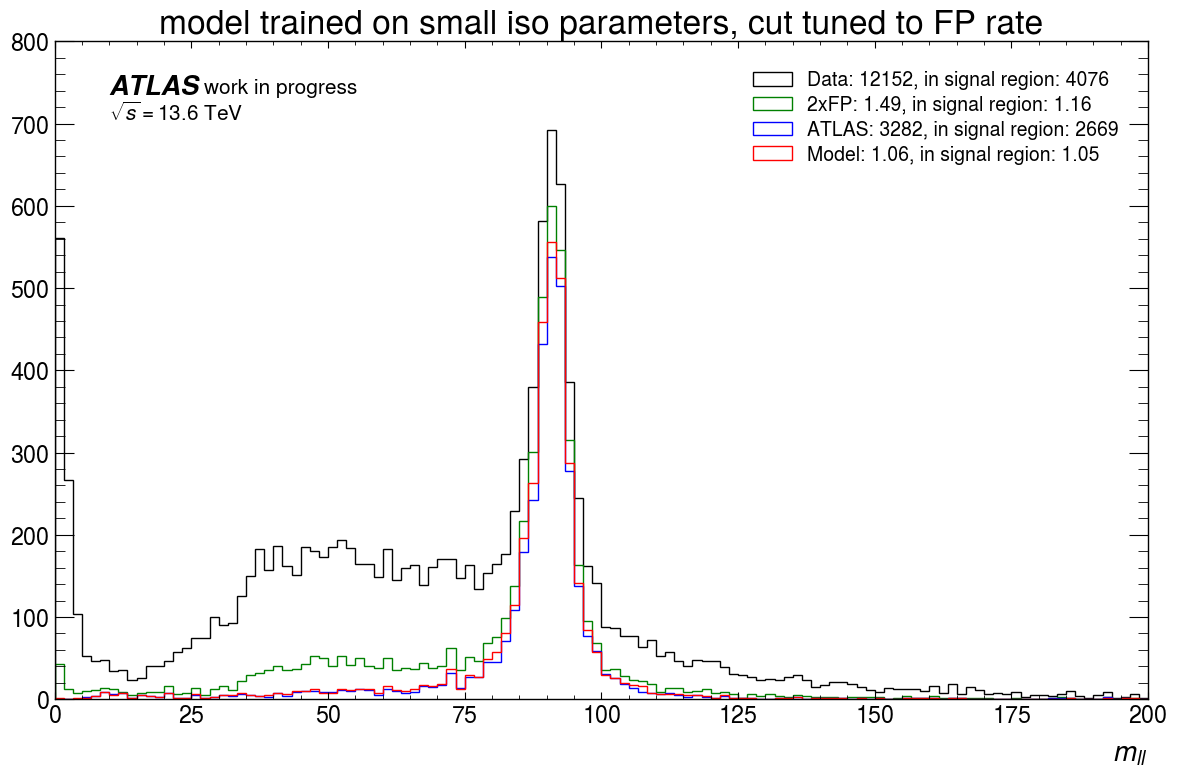

In [78]:
mask = (logit_scores_data_small_iso > cut[i])
mask_model_or_ATLAS = mask | mask_ATLAS
fig, ax = plt.subplots(figsize=(12, 8))
ax.hist(data_llm,color = 'black', bins=120, range=(0, 200), histtype='step', label=f'Data: {len(data_llm)}, in signal region: {data_sum_signal_region}')
ax.hist(data_llm[pred_small_iso_2x_FP_data], color='green', bins=120, range=(0, 200), histtype='step', label=f'2xFP: {np.sum(pred_small_iso_2x_FP_data)/np.sum(mask_ATLAS):.2f}, in signal region: {(np.sum(pred_small_iso_2x_FP_data & mask_sig_region)/np.sum(mask_ATLAS & mask_sig_region)):.2f}')
ax.hist(data_llm[mask_ATLAS], color='blue', bins=120, range=(0, 200), histtype='step', label=f'ATLAS: {np.sum(mask_ATLAS)}, in signal region: {np.sum(mask_ATLAS & mask_sig_region)}')
ax.hist(data_llm[pred_small_iso_data], color='red', bins=120, range=(0, 200), histtype='step', label=f'Model: {np.sum(pred_small_iso_data)/np.sum(mask_ATLAS):.2f}, in signal region: {(np.sum(pred_small_iso_data & mask_sig_region)/np.sum(mask_ATLAS & mask_sig_region)):.2f}')

hep.atlas.label(data=True, label="work in progress", fontsize=15, ax= ax,rlabel=f"$\sqrt{{s}}=13.6$ TeV")
ax.legend()
ax.set_xlabel('$m_{ll}$')

ax.set_title(f'model trained on small iso parameters, cut tuned to FP rate')
fig.tight_layout()
fig.savefig(f'plots/frame_{i:03d}.png')

In [79]:
# # Get the list of image files
# import cv2
# img_files = sorted(glob.glob('plots/frame_*.png'), reverse=True)

# # Define the codec and create a VideoWriter object
# fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # Codec for .mp4 files
# fps = 10  # Frames per second
# frame_size = (1200, 800)  # Frame size (width, height)

# # Create a VideoWriter object
# out = cv2.VideoWriter('output_video.mp4', fourcc, fps, frame_size)

# for img_file in img_files:
#     img = cv2.imread(img_file)
#     img = cv2.resize(img, frame_size)  # Resize image to match frame size
#     out.write(img)

# # Release the VideoWriter object
# out.release()

Text(0, 1, 'estimated background/ATLAS background')

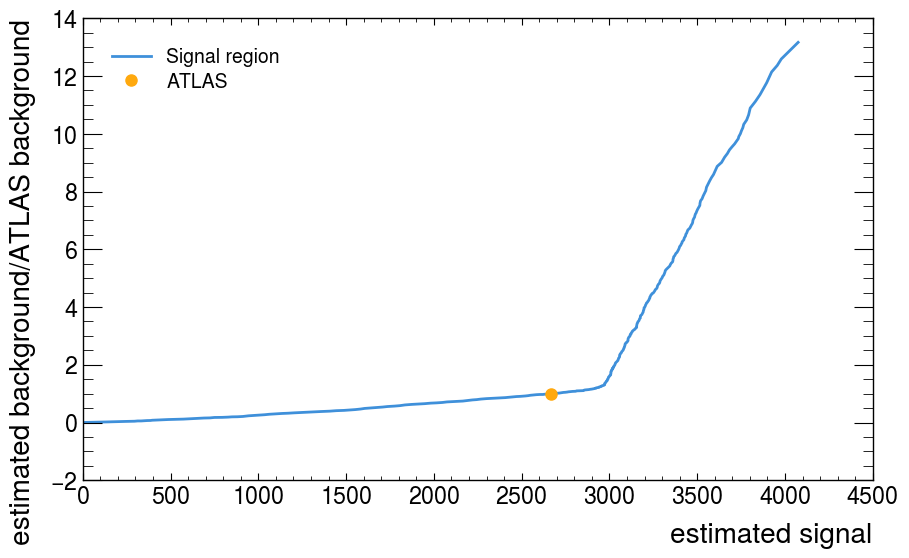

In [80]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(num_sig_region, (num_model-num_sig_region)/np.sum(mask_ATLAS & ~mask_sig_region), label='Signal region')
ax.plot(np.sum(mask_ATLAS & mask_sig_region), 1, 'o', label='ATLAS')
ax.legend()
# ax.set_yscale('log')
# ax.set_xscale('log')
ax.set_xlabel('estimated signal')
ax.set_ylabel('estimated background/ATLAS background')

In [81]:
true_data_22 = pd.read_parquet('/groups/hep/kinch/data/Data/data22_13p6TeV.periodAllYear.physics_Main.PhysCont.DAOD_PHYS.grp22_v01_p6029/hist-sample_reduced.parquet')
print(f'shape data 22: {true_data_22.shape}')
true_data_23 = pd.read_parquet('/groups/hep/kinch/data/Data/data23_13p6TeV.periodAllYear.physics_Main.PhysCont.DAOD_PHYS.grp23_v01_p6029/hist-sample_reduced.parquet')
print(f'shape data 23: {true_data_23.shape}')
MC_data = pd.read_parquet('/groups/hep/kinch/data/preprocessed_data/files_from_grid/Data_BalZ_ttbar_zee.parquet')
print(f'shape MC data: {MC_data.shape}')

# true_data = pd.concat([true_data_22, true_data_23])
true_data = true_data_22
print(true_data['EventInfo.channel'].value_counts())
# print(MC_data['EventInfo.channel'].value_counts())
print(true_data.shape)
true_data = true_data[true_data['EventInfo.channel'] == 1]
print(f'shape true data: {true_data.shape}')

shape data 22: (32936, 53)
shape data 23: (45757, 53)
shape MC data: (8792502, 40)
EventInfo.channel
1    32936
Name: count, dtype: int64
(32936, 53)
shape true data: (32936, 53)


In [82]:
print(small_iso_pred_z)

['l1_small_iso_score', 'l2_small_iso_score', 'l1_DNN_pel', 'l2_DNN_pel', 'EventInfo.actualIntPerXing', 'deltaz', 'sigma_delta_z', 'cutflow_mask']


In [83]:
print(Data.columns)
print(Data.shape)

Index(['l1_ptcone20', 'l1_ptcone20_pt1000', 'l1_ptcone20_pt500', 'l1_ptcone30',
       'l1_ptvarcone20', 'l1_ptvarcone30', 'l1_ptvarcone30_pt1000',
       'l1_ptvarcone30_pt500', 'l1_topoetcone20',
       'l1_topoetcone20ptCorrection', 'l1_topoetcone40', 'l1_neflowisol20',
       'l2_ptcone20', 'l2_ptcone20_pt1000', 'l2_ptcone20_pt500', 'l2_ptcone30',
       'l2_ptvarcone20', 'l2_ptvarcone30', 'l2_ptvarcone30_pt1000',
       'l2_ptvarcone30_pt500', 'l2_topoetcone20',
       'l2_topoetcone20ptCorrection', 'l2_topoetcone40', 'l2_neflowisol20',
       'l1_DNN_pel', 'l1_z0', 'l1_sig_z0', 'l2_DNN_pel', 'l2_z0', 'l2_sig_z0',
       'EventInfo.actualIntPerXing', 'EventInfo.averageIntPerXing',
       'EventInfo.mu', 'EventInfo.eventNumber', 'truth_from_Z',
       'EventInfo.cutflow', 'EventInfo.cutflow_new', 'll_m', 'l1_truthType',
       'l2_truthType', 'l1_iso_score', 'l2_iso_score', 'deltaz',
       'sigma_delta_z', 'cutflow_mask', 'l1_small_iso_score',
       'l2_small_iso_score'],
      d

In [84]:
delta_z0 = np.zeros(true_data.shape[0])
delta_sig_z0 = np.zeros(true_data.shape[0])

delta_z0 = np.abs(true_data['l1_z0'] - true_data['l2_z0'])
delta_sig_z0 = np.sqrt(true_data['l1_sig_z0']**2 + true_data['l2_sig_z0']**2)

delta_z0_norm = delta_z0/delta_sig_z0

true_data['DZ0'] = delta_z0_norm

delta_z0_MC = np.zeros(Data.shape[0])
delta_sig_z0_MC = np.zeros(Data.shape[0])

delta_z0_MC = np.abs(Data['l1_z0'] - Data['l2_z0'])
delta_sig_z0_MC = np.sqrt(Data['l1_sig_z0']**2 + Data['l2_sig_z0']**2)

delta_z0_norm_MC = delta_z0_MC/delta_sig_z0_MC

Data['DZ0'] = delta_z0_norm_MC

In [85]:
minimal_pred_z_params = ['l1_small_iso_score', 'l2_small_iso_score', 'l1_DNN_pel', 'l2_DNN_pel', 'DZ0']

In [86]:
iso1_larger_data = np.zeros((true_data.shape[0], 4))
iso2_larger_data = np.zeros((true_data.shape[0], 4))

for i in range(4):
    with open(f'small_param_iso_tuner_{i}.pkl', 'rb') as f:
        small_iso_tuner = pickle.load(f)
    iso1_larger_data[:,i] = small_iso_tuner.predict_proba(true_data[small_iso_param_list1])
    iso2_larger_data[:,i] = small_iso_tuner.predict_proba(true_data[small_iso_param_list2])

true_data['l1_small_iso_score'] = iso1_larger_data.mean(axis=1)
true_data['l2_small_iso_score'] = iso2_larger_data.mean(axis=1)

In [103]:
# minimal z model

mask = Data['EventInfo.eventNumber'] % 4 != 0
X_train = Data[mask][minimal_pred_z_params]
y_train = Data[mask]['truth_from_Z']
X_test = Data[~mask]
y_test = Data[~mask]['truth_from_Z']

if os.path.exists(f'minimal_z_tuner_noncross_deltaz_cutflow.pkl'):
    with open(f'minimal_z_tuner_noncross_deltaz_cutflow.pkl', 'rb') as f:
        minimal_z_tuner = pickle.load(f)
        id_predictions_minimal_z = minimal_z_tuner.predict_proba(X_test[minimal_pred_z_params])
        id_predictions_minimal_z_data = minimal_z_tuner.predict_proba(true_data[minimal_pred_z_params])
else:
    minimal_z_tuner = RapidGBMTuner(metric='auc', trials=400, refit=True, verbosity=1, visualization=True, seed=414243)
    minimal_z_tuner.fit(X_train, y_train)
    minimal_z_tuner.fit_optimized(X_train.to_numpy(), y_train.to_numpy())

    id_predictions_minimal_z_data = minimal_z_tuner.predict_proba(true_data[minimal_pred_z_params])
    with open(f'minimal_z_tuner_noncross_deltaz_cutflow.pkl', 'wb') as f:
        pickle.dump(minimal_z_tuner, f)

print(id_predictions_minimal_z_data.shape)

(32936,)


In [104]:
iso1 = np.zeros((true_data.shape[0], 4))
iso2 = np.zeros((true_data.shape[0], 4))

for i in range(4):
    with open(f'iso_tuner_{i}.pkl', 'rb') as f:
        tuner = pickle.load(f)
    iso1[:,i] = tuner.predict_proba(true_data[iso_1_param_list])
    iso2[:,i] = tuner.predict_proba(true_data[iso_2_param_list])


true_data['l1_iso_score'] = np.mean(iso1, axis=1)
true_data['l2_iso_score'] = np.mean(iso2, axis=1)

In [105]:
with open(f'z_tuner_noncross.pkl', 'rb') as f:
    tuner = pickle.load(f)
pred_score_data = tuner.predict_proba(true_data[pred_z_param_list])
pred_score_mc = tuner.predict_proba(X_test[pred_z_param_list])

id_predictions_minimal_z_data = pred_score_data
pred_score_small_iso_test = pred_score_mc

Text(1, 0, 'Logit score')

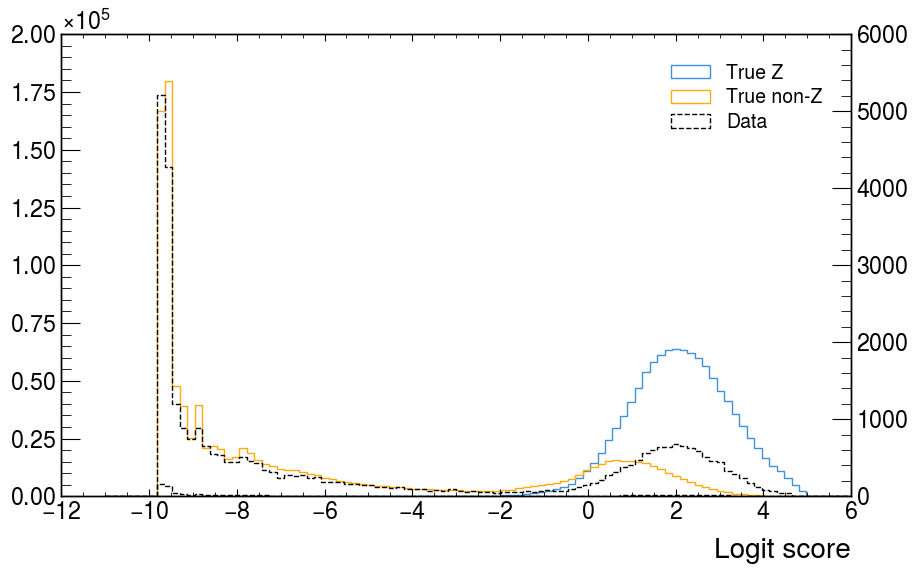

In [187]:
plt.rcdefaults()
hep.style.use([hep.style.ATLAS])

logit_scores_data_small_iso = np.log(id_predictions_minimal_z_data/(1-id_predictions_minimal_z_data))
logit_scores_MC_small_iso = np.log(pred_score_small_iso_test/(1-pred_score_small_iso_test))

fig, ax = plt.subplots(figsize=(10, 6))
bins_signal, edges_signal, _ = ax.hist(logit_scores_MC_small_iso[X_test['truth_from_Z']==1], bins=100, range=(-11, 6), histtype='step', label='True Z')
bins_bck, edges_bck, _ = ax.hist(logit_scores_MC_small_iso[X_test['truth_from_Z']==0], bins=100, range=(-11, 6), histtype='step', label='True non-Z')
bins_data, edges_data, _ = ax.hist(logit_scores_data_small_iso, bins=100, range=(-11, 6), histtype='step', label='Data', color='black',linestyle='--')
ax2 = ax.twinx()
ax2.hist(logit_scores_data_small_iso, bins=100, range=(-11, 6), histtype='step', label='Data', color='black', linestyle='--')
ax.legend()
ax.set_xlabel('Logit score')

5205.0 673.0
7 76
8 76
-69 -68
scale: 1.0147058823529411, shift: -1.117647058823529


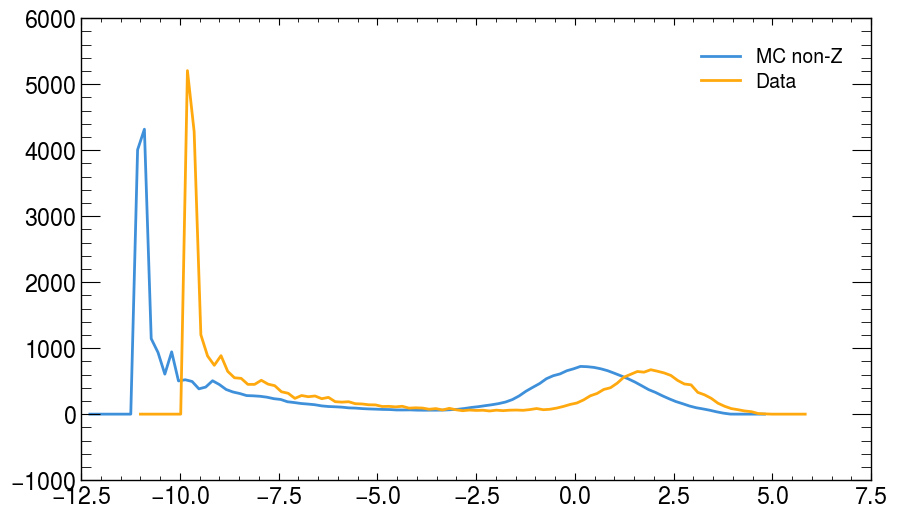

In [186]:
peak_data_1 = np.argmax(bins_data[edges_data[:-1] < -5])
peak_data_2 = np.argmax(bins_data[edges_data[:-1] > -5])

peak_data_2 = peak_data_2 + len(bins_data[edges_data[:-1] < -5])
print(bins_data[peak_data_1], bins_data[peak_data_2])
peak_MC_1 = np.argmax(bins_bck)
peak_MC_2 = np.argmax(bins_signal)

print(peak_data_1, peak_data_2)
print(peak_MC_1, peak_MC_2)

# peak_data_1 = peak_MC_1*scale + shift
# peak_data_2 = peak_MC_2*scale + shift

scale = (peak_data_1 - peak_data_2)/(peak_MC_1 - peak_MC_2)
shift = peak_data_1 - peak_MC_1*scale

distance_pp_data = peak_data_1 - peak_data_2
distance_pp_MC = peak_MC_1 - peak_MC_2

print(distance_pp_data, distance_pp_MC)

print(f'scale: {scale}, shift: {shift}')

# prep fit for data and MC
alpha = 0.007
beta = 0.024
scale_guess = scale
shift_guess = shift
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(((edges_bck[:-1]))*scale+shift,(alpha*bins_signal + beta*bins_bck),label='MC non-Z')
ax.plot(((edges_data[:-1])),bins_data,label='Data')
ax.legend()


<ValueView A1=0.005937946575178007 A2=0.024905500430117303 scale=0.9999992883309088 shift=9.729770429916533e-06>
<ValueView A1=0.005937946575178007 A2=0.024905500430117303 scale=0.9999992883309088 shift=9.729770429916533e-06>


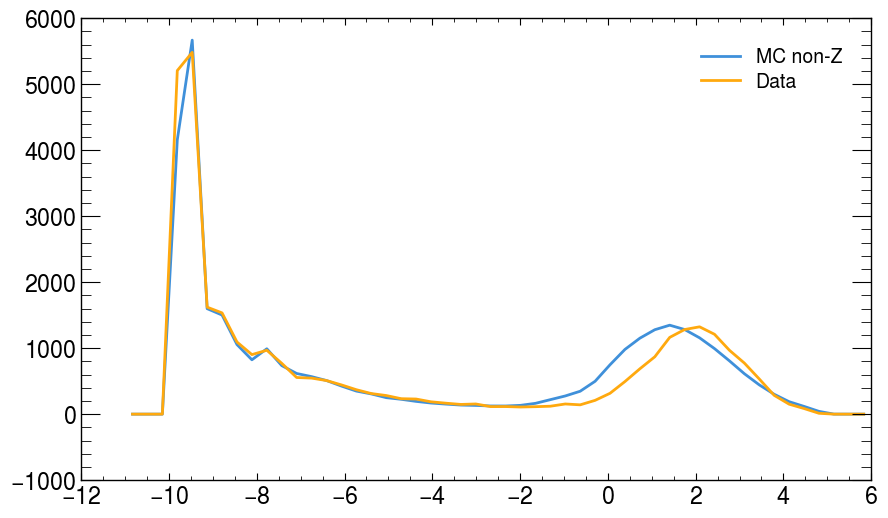

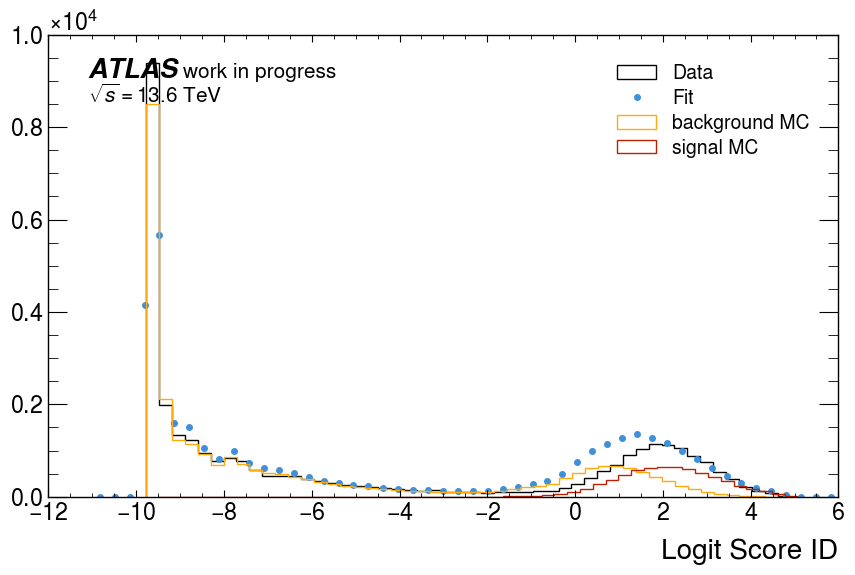

In [148]:
# fit data and MC

from iminuit import Minuit

error_sig = np.sqrt(bins_signal)
error_bck = np.sqrt(bins_bck)
error_data = np.sqrt(bins_data)



def MAE(A1, A2, scale, shift):
    x = scale * (edges_signal + shift)
    y = A1*bins_signal + A2*bins_bck

    dx = ( x[1:] - x[:-1] / 2 ) - ( edges_signal[1:] - edges_signal[:-1] / 2 )
    dy = y - bins_data

    distances = np.sqrt(dx**2 + dy**2)
    error_combined = np.sqrt(error_sig**2 + error_bck**2 + error_data**2)
    # weighted_avg = np.average(distances, weights=1/error_combined)
    weighted_avg = np.sum(distances)
    return weighted_avg

def chi2(A1, A2, scale, shift):
    x = scale * (edges_signal + shift)
    y = A1*bins_signal + A2*bins_bck

    dx = ( x[1:] - x[:-1] / 2 ) - ( edges_signal[1:] - edges_signal[:-1] / 2 )
    dy = y - bins_data

    error_sig = np.sqrt(A1*bins_signal)
    error_bck = np.sqrt(A2*bins_bck)

    dist = np.sqrt(dx**2 + dy**2)

    chi2_val = np.sum((dist**2/(error_sig**2 + error_bck**2 + error_data**2)))


    return chi2_val


m = Minuit(MAE, A1=alpha, A2=beta, scale=scale_guess, shift=shift_guess)
# m.limits['A1'] = (0.05, 1)
# m.limits['A2'] = (0, 1)
# m.limits['scale'] = (0.5, 2)
# m.limits['shift'] = (-1, 1)



m.migrad()

print(m.values)
# m.values[0]*=1.55
print(m.values)
# m.values.append(1)
# m.values.append(0)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(((edges_bck[1:]+edges_bck[:-1])/2-m.values[3])*m.values[2],(m.values[0]*bins_signal + m.values[1]*bins_bck),label='MC non-Z')
ax.plot(((edges_data[1:]+edges_data[:-1])/2),bins_data,label='Data')
ax.legend()

ax.legend()

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(logit_scores_data_small_iso, color='black', bins=50, histtype='step', label='Data')
ax.plot((edges_signal[:-1]+edges_signal[1:])/2, bins_signal*m.values[0]+bins_bck*m.values[1],'.', label='Fit')
# ax.plot((edges_signal[:-1]+edges_signal[1:])/2, bins_signal*m.values[0], label='True Z')
ax.hist(logit_scores_MC_small_iso[X_test['truth_from_Z']==0], bins=50,weights=(m.values[1])*np.ones_like(logit_scores_MC_small_iso[X_test['truth_from_Z']==0]) , histtype='step', label='background MC')
ax.hist(logit_scores_MC_small_iso[X_test['truth_from_Z']==1], bins=50,weights=m.values[0]*np.ones_like(logit_scores_MC_small_iso[X_test['truth_from_Z']==1]) , histtype='step', label='signal MC')
ax.set_xlabel('Logit Score ID')
hep.atlas.label(data=True, label="work in progress", fontsize=15, ax= ax,rlabel=f"$\sqrt{{s}}=13.6$ TeV")
# ax.set_yscale('log')
ax.legend()

In [92]:
mask_sig_region = (X_test['ll_m'] > 80) & (X_test['ll_m'] < 100)
mask_ATLAS = (X_test['EventInfo.cutflow'] >= 14)
mask_truth = X_test['truth_from_Z'] == 1

print(f'number of true Zs in signal region: {np.sum(mask_sig_region & mask_truth)}')
print(f'number missed by atlas: {np.sum(mask_sig_region & ~mask_ATLAS & mask_truth)}')
print(f'theoretical maximum improvement: {np.sum(mask_sig_region & ~mask_ATLAS & mask_truth)/np.sum(mask_sig_region & mask_truth)}')

number of true Zs in signal region: 966081
number missed by atlas: 90168
theoretical maximum improvement: 0.09333378878168601


(32936,)


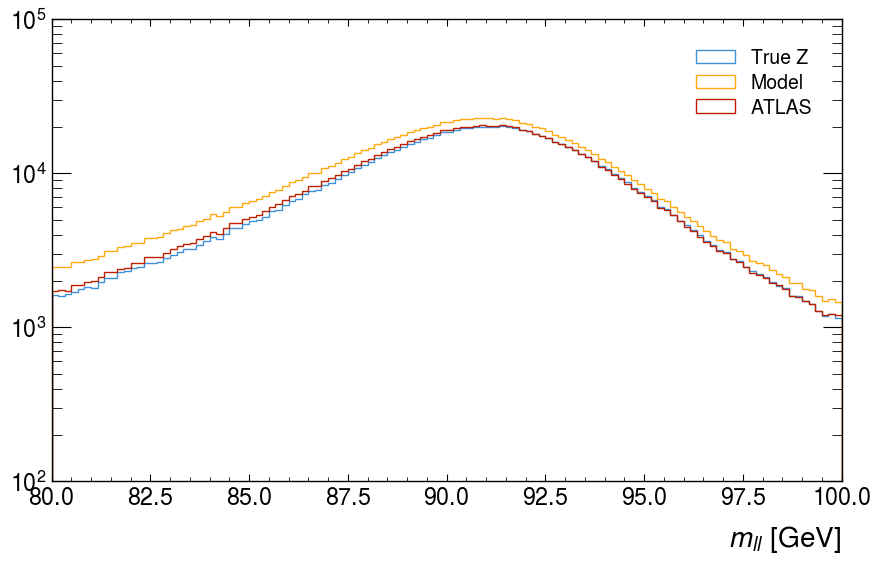

In [93]:
fp_atlas = len(X_test[(X_test['truth_from_Z'] == 0) & (X_test['EventInfo.cutflow'] >= 14)])
fp2xcut = np.sort(logit_scores_MC_small_iso[X_test['truth_from_Z']==0])[-2*fp_atlas]

pred_small_iso_small_param = logit_scores_MC_small_iso > fp2xcut
pred_small_iso_small_param_data = logit_scores_data_small_iso > fp2xcut
print(logit_scores_data_small_iso.shape)

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(X_test['ll_m'][X_test['truth_from_Z']==1], bins=120, range=(80, 100), histtype='step', label='True Z')
ax.hist(X_test['ll_m'][pred_small_iso_small_param], bins=120, range=(80, 100), histtype='step', label='Model')
ax.hist(X_test['ll_m'][X_test['EventInfo.cutflow'] >= 14], bins=120, range=(80, 100), histtype='step', label='ATLAS')
ax.set_xlabel('$m_{ll}$ [GeV]')
ax.set_yscale('log')
ax.legend()

(32936,)
(32936, 58)


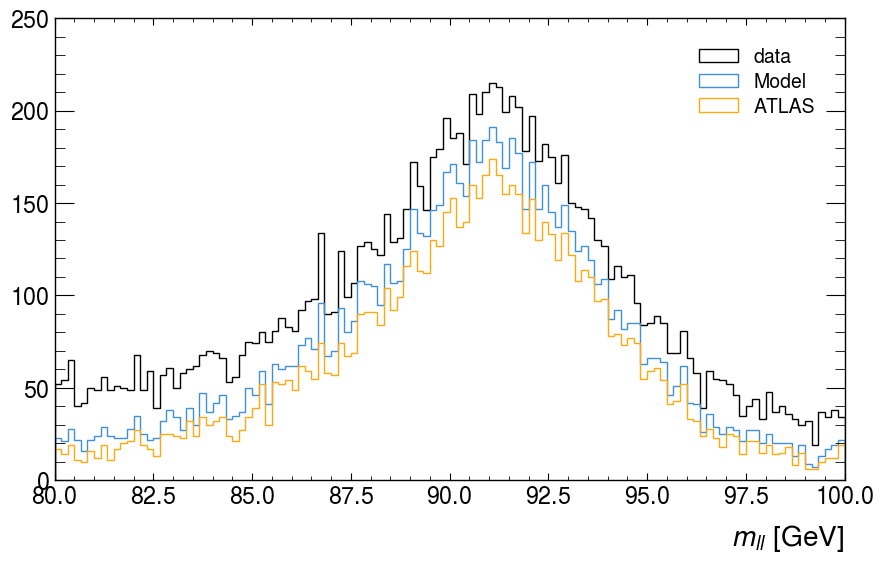

In [94]:
print(logit_scores_data_small_iso.shape)
print(true_data.shape)


fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(true_data['ll_m'], bins=120, range=(80, 100), color='black', histtype='step', label='data')
ax.hist(true_data['ll_m'][pred_small_iso_small_param_data], bins=120, range=(80, 100), histtype='step', label='Model')
ax.hist(true_data['ll_m'][true_data['EventInfo.cutflow'] >= 14], bins=120, range=(80, 100), histtype='step', label='ATLAS')
ax.set_xlabel('$m_{ll}$ [GeV]')
ax.legend()

Text(0, 1, 'efficiency')

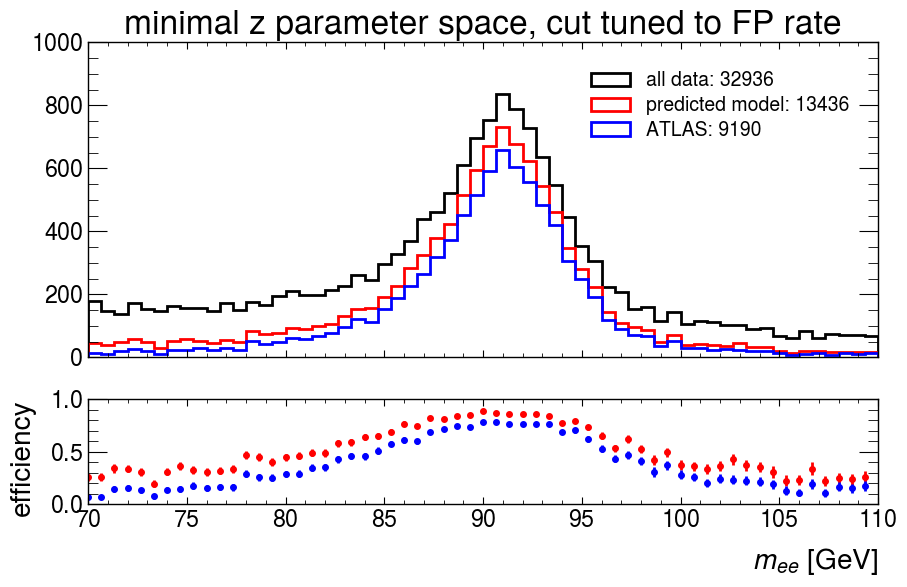

In [95]:
fig, ax = plt.subplots(2,1,figsize=(10, 6),height_ratios=[3,1])
counts_all, bins_all, _ = ax[0].hist(true_data['ll_m'], bins=60, range=(70, 110),linewidth=2, histtype='step', label=f'all data: {len(true_data)}', color='black')
counts_model, bins_model, _ = ax[0].hist(true_data['ll_m'][pred_small_iso_small_param_data], bins=60, range=(70, 110),linewidth=2, histtype='step',color='r', label=f'predicted model: {np.sum(pred_small_iso_small_param_data)}')
counts_ATLAS, bins_ATLAS, _ = ax[0].hist(true_data['ll_m'][true_data['EventInfo.cutflow'] >= 14], bins=60,linewidth=2, range=(70, 110), histtype='step',color='b', label=f'ATLAS: {np.sum((true_data["EventInfo.cutflow"] >= 14))}')
ax[0].legend(loc='upper right')
ax[0].set_xticklabels([])
eff_model = counts_model/counts_all
eff_ATLAS = counts_ATLAS/counts_all

uncertainty_model = np.sqrt(eff_model*(1-eff_model)/counts_all)
uncertainty_ATLAS = np.sqrt(eff_ATLAS*(1-eff_ATLAS)/counts_all)

ax[0].set_title('minimal z parameter space, cut tuned to FP rate')

ax[1].errorbar(bins_all[:-1], eff_model, yerr=uncertainty_model, fmt='.', label='model', color='r')
ax[1].errorbar(bins_all[:-1], eff_ATLAS, yerr=uncertainty_ATLAS, fmt='.', label='ATLAS', color='b')

ax[1].set_xlabel('$m_{ee}$ [GeV]')
ax[1].set_ylabel('efficiency')
# ax[1].set_ylim(0.75,1)


Text(1, 0, '$m_{ll}$')

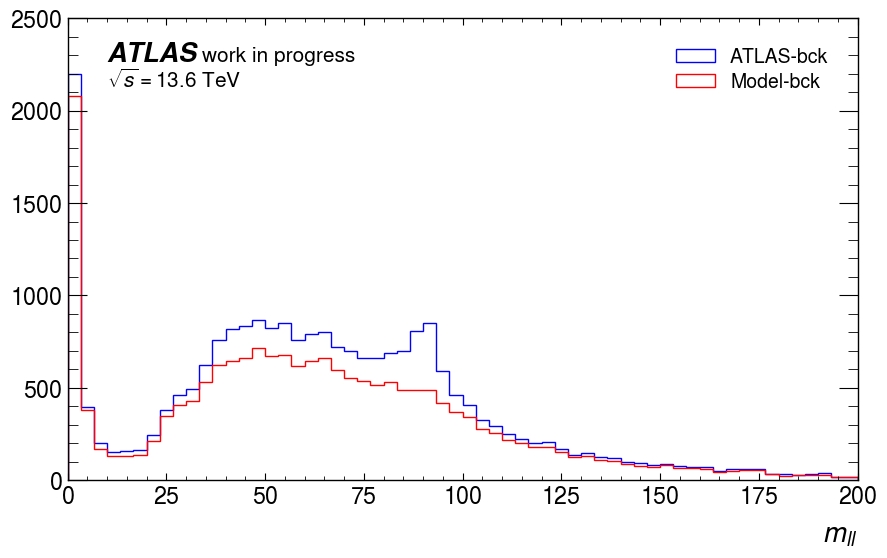

In [96]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(true_data['ll_m'][true_data['EventInfo.cutflow'] < 14],color='blue',range=(0,200), bins=60, histtype='step', label='ATLAS-bck')
ax.hist(true_data['ll_m'][~pred_small_iso_small_param_data],color='red',range=(0,200), bins=60, histtype='step', label='Model-bck')
ax.legend()
hep.atlas.label(data=True, label="work in progress", fontsize=15, ax= ax,rlabel=f"$\sqrt{{s}}=13.6$ TeV")

ax.set_xlabel('$m_{ll}$')

In [97]:
# training on non-iso bck

data_non_iso_bck = pd.read_parquet('/groups/hep/kinch/data/preprocessed_data/files_from_grid/Data_BalZ_ttbar_zee_ttbardoubleisofiltered.parquet')
print(data_non_iso_bck.shape)

print(data_non_iso_bck['EventInfo.channel'].value_counts())

iso1 = np.zeros(data_non_iso_bck.shape[0])
iso2 = np.zeros(data_non_iso_bck.shape[0])

for i in range(4):
    mask = data_non_iso_bck['EventInfo.eventNumber'] % 4 == i
    X_test = data_non_iso_bck[mask]
    y_test = X_test['truth_from_Z']

    with open(f'small_param_iso_tuner_{i}.pkl', 'rb') as f:
        small_iso_tuner = pickle.load(f)
    
    iso1[mask] = small_iso_tuner.predict_proba(X_test[small_iso_param_list1])
    iso2[mask] = small_iso_tuner.predict_proba(X_test[small_iso_param_list2])

data_non_iso_bck['l1_small_iso_score'] = iso1
data_non_iso_bck['l2_small_iso_score'] = iso2

dz = np.zeros(data_non_iso_bck.shape[0])

dz = np.abs(data_non_iso_bck['l1_z0'] - data_non_iso_bck['l2_z0'])
sig_dz = np.sqrt(data_non_iso_bck['l1_sig_z0']**2 + data_non_iso_bck['l2_sig_z0']**2)

dz_norm = dz/sig_dz

data_non_iso_bck['DZ0'] = dz_norm

(8396728, 60)
EventInfo.channel
1    8396728
Name: count, dtype: int64



 * Initiating LGBMTuner.fit
     . Settings:
     .. Trying 30 trials
     .. Evaluation metric: auc 
     .. Study direction: minimize log_loss

     . Trial number: 0 finished
     .. Optimization score (lower-better): log_loss: 0.21109873949025476
     .. Evaluation score (greater-better): auc: 0.9658446209685159
 ...........................................................................
     . Trial number: 1 finished
     .. Optimization score (lower-better): log_loss: 0.2109358354181379
     .. Evaluation score (greater-better): auc: 0.9658621051022589
 ...........................................................................
     . Trial number: 2 finished
     .. Optimization score (lower-better): log_loss: 0.2109400734599162
     .. Evaluation score (greater-better): auc: 0.9658560147770998
 ...........................................................................
     . Trial number: 3 finished
     .. Optimization score (lower-better): log_loss: 0.21136017390225786
   

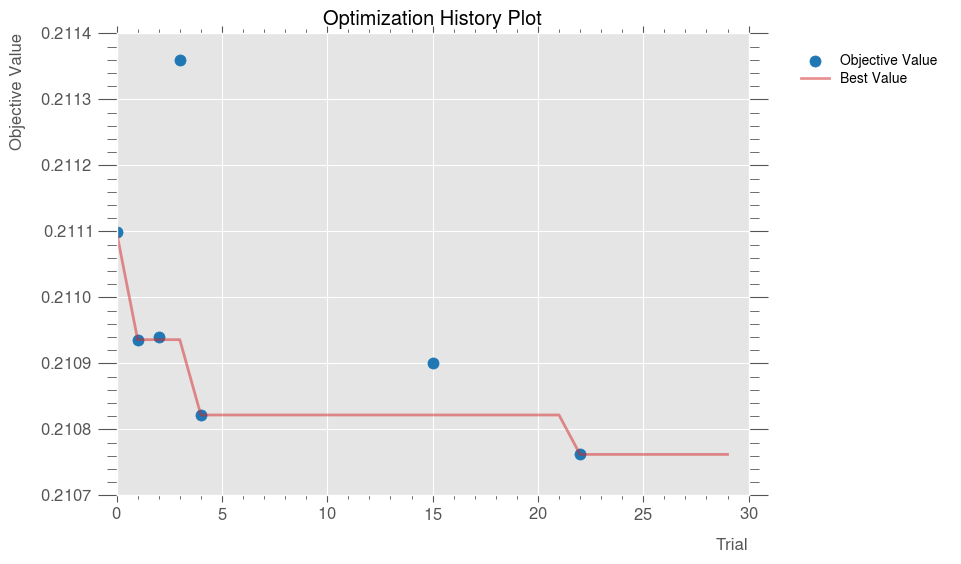

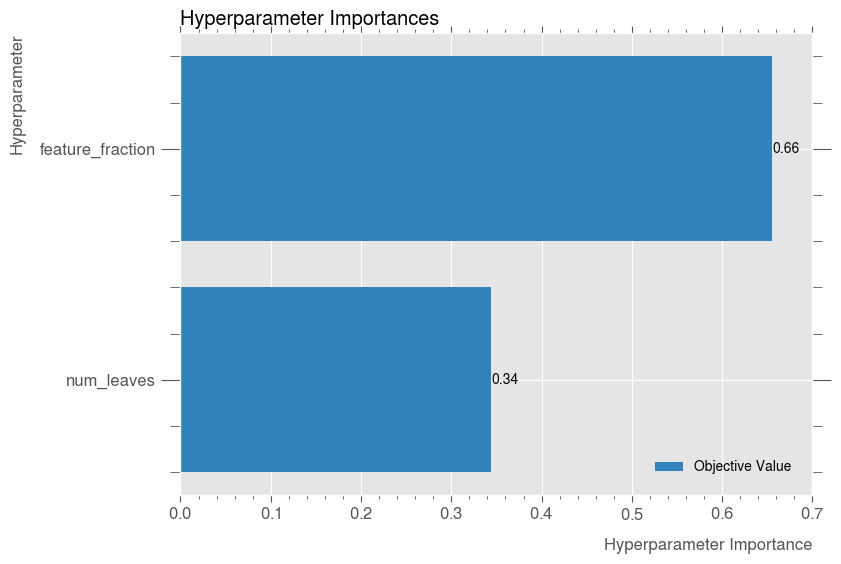

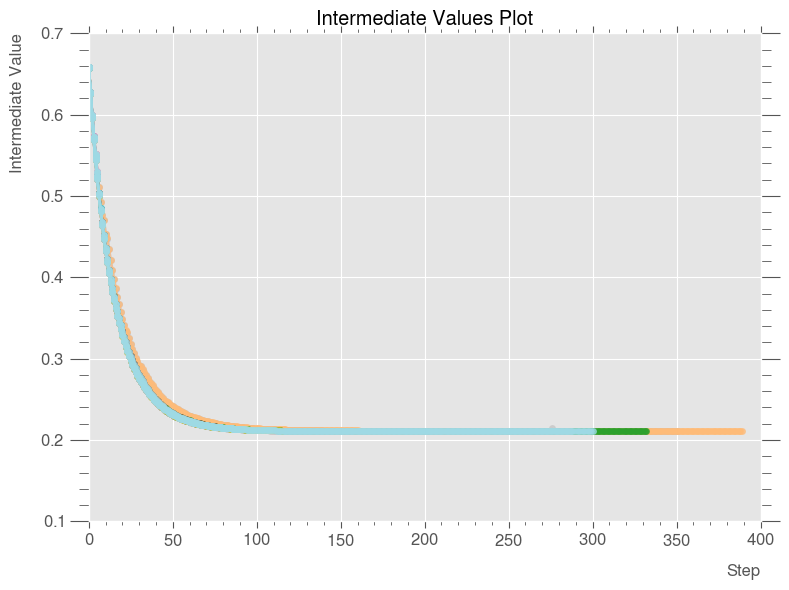

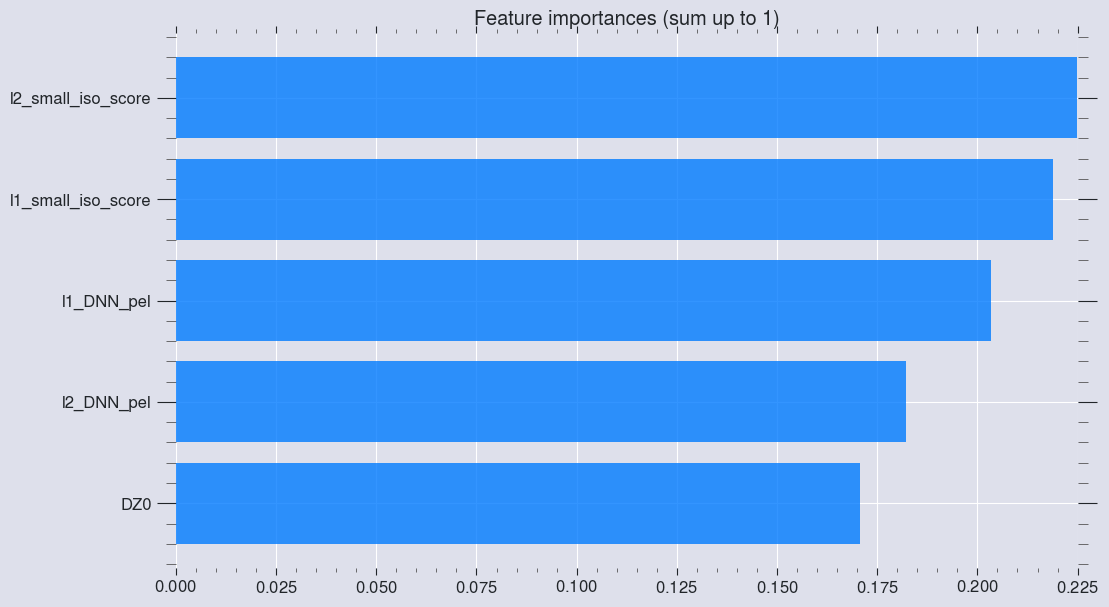


     . Optuna hyperparameters optimization finished
     .. Best trial number:22    |     log_loss:          0.21076195897776998
 ---------------------------------------------------------------------------

Time elapsed for fit execution: 8 min 54.534 sec

   - Fitting optimized model with the following params:
task                             : train
learning_rate                    : 0.05
num_leaves                       : 198
feature_fraction                 : 0.8786369612051198
bagging_fraction                 : 0.7
bagging_freq                     : 1
max_depth                        : -1
verbosity                        : -1
lambda_l1                        : 1
lambda_l2                        : 0.0
min_split_gain                   : 0.0
zero_as_missing                  : False
max_bin                          : 255
min_data_in_bin                  : 3
random_state                     : 42
device_type                      : cpu
num_classes                      : 1
objective     

In [188]:
minimal_pred_z_params = ['l1_small_iso_score', 'l2_small_iso_score', 'l1_DNN_pel', 'l2_DNN_pel', 'DZ0']

pred_z_params = ['l1_small_iso_score', 'l2_small_iso_score', 
                'l1_DNN_pel', 'l1_z0', 'l1_sig_z0', 'l2_DNN_pel', 'l2_z0', 'l2_sig_z0', 'EventInfo.actualIntPerXing'
                , 'EventInfo.averageIntPerXing', 'EventInfo.mu']

mask = data_non_iso_bck['EventInfo.eventNumber'] % 4 != 0

X_train = data_non_iso_bck[mask][minimal_pred_z_params]
y_train = data_non_iso_bck[mask]['truth_from_Z']
X_test = data_non_iso_bck[~mask]
y_test = data_non_iso_bck[~mask]['truth_from_Z']

if os.path.exists(f'z_tuner_trained_nonisottbar_minZ.pkl'):
    with open(f'z_tuner_trained_nonisottbar_minZ.pkl', 'rb') as f:
        minimal_z_tuner = pickle.load(f)
        id_predictions_minimal_z = minimal_z_tuner.predict_proba(X_test[minimal_pred_z_params])
        id_predictions_minimal_z_data = minimal_z_tuner.predict_proba(true_data[minimal_pred_z_params])
else:
    minimal_z_tuner = RapidGBMTuner(metric='auc', trials=30, refit=True, verbosity=1, visualization=True, seed=414243)
    minimal_z_tuner.fit(X_train, y_train)
    minimal_z_tuner.fit_optimized(X_train.to_numpy(), y_train.to_numpy())

    id_predictions_minimal_z_data = minimal_z_tuner.predict_proba(true_data[minimal_pred_z_params])
    id_predictions_minimal_z = minimal_z_tuner.predict_proba(X_test[minimal_pred_z_params])
    
    plt.rcdefaults()
    hep.style.use([hep.style.ATLAS])
    with open(f'z_tuner_trained_nonisottbar_minZ.pkl', 'wb') as f:
        pickle.dump(minimal_z_tuner, f)

Text(0.5, 1.0, 'minimal z parameter space, bck trained on non-iso bck')

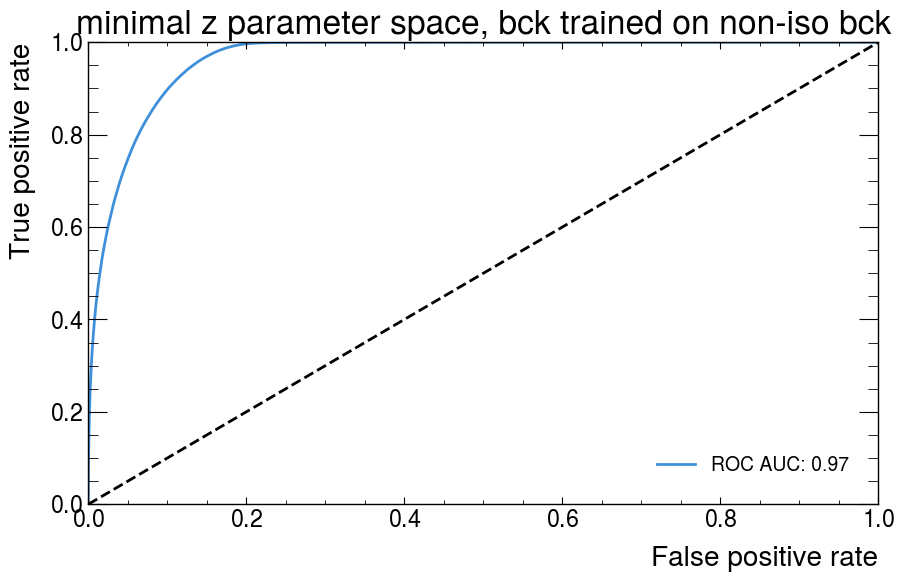

In [189]:
# roc curve
fpr, tpr, _ = roc_curve(y_test, id_predictions_minimal_z)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(fpr, tpr, label=f'ROC AUC: {roc_auc:.2f}')
ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0,1)
ax.set_title('minimal z parameter space, bck trained on non-iso bck')


Text(1, 0, 'Logit score')

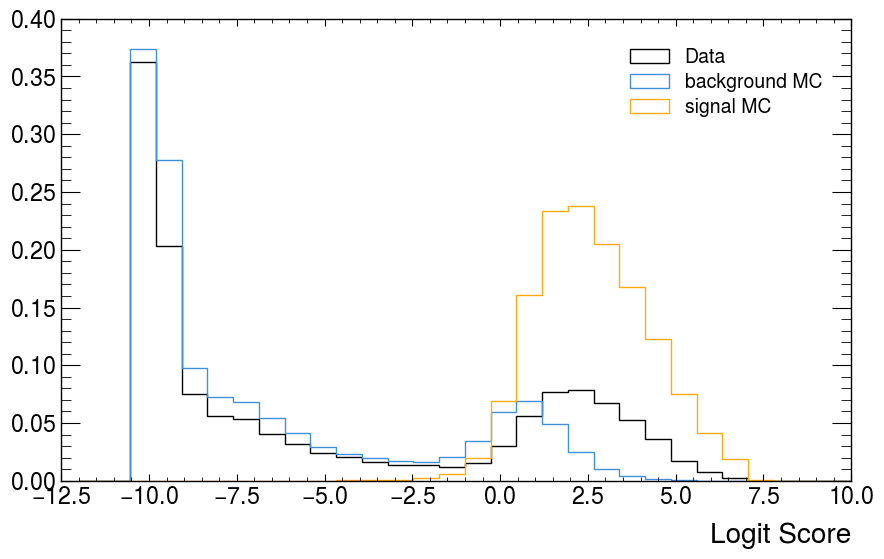

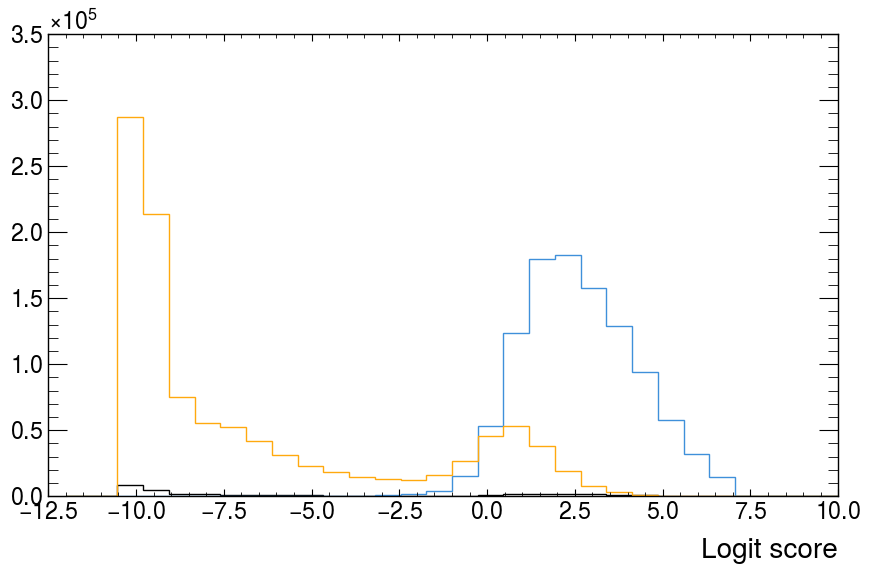

In [190]:
logit_scores_data_small_iso = np.log(id_predictions_minimal_z_data/(1-id_predictions_minimal_z_data))
logit_scores_MC_small_iso = np.log(id_predictions_minimal_z/(1-id_predictions_minimal_z))

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(logit_scores_data_small_iso, color='black', bins=30, range=(-12, 10), histtype='step', label='Data', density=True)
ax.hist(logit_scores_MC_small_iso[y_test==0], range=(-12, 10), bins=30, histtype='step', label='background MC', density=True)
ax.hist(logit_scores_MC_small_iso[y_test==1], range=(-12, 10), bins=30, histtype='step', label='signal MC', density=True)
ax.set_xlabel('Logit Score')
ax.legend()

fig, ax = plt.subplots(figsize=(10, 6))
bins_data, edges_data, _ = ax.hist(logit_scores_data_small_iso, bins=30, range=(-12, 10), histtype='step', label='Data', color='black')
bins_signal, edges_signal, _ = ax.hist(logit_scores_MC_small_iso[y_test==1], bins=30, range=(-12, 10), histtype='step', label='True Z')
bins_bck, edges_bck, _ = ax.hist(logit_scores_MC_small_iso[y_test==0], bins=30, range=(-12, 10), histtype='step', label='True non-Z')

ax.set_xlabel('Logit score')

In [191]:
critical_bck = (logit_scores_MC_small_iso > -1) & (y_test == 0)

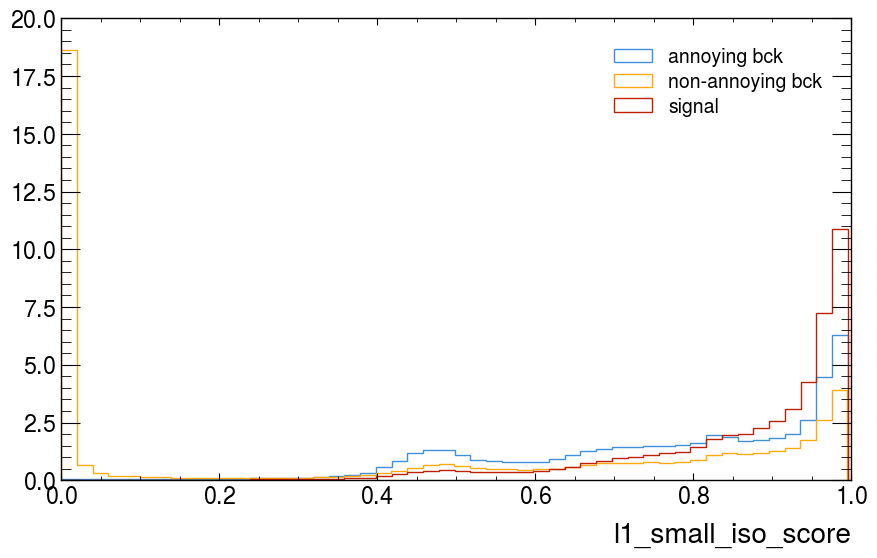

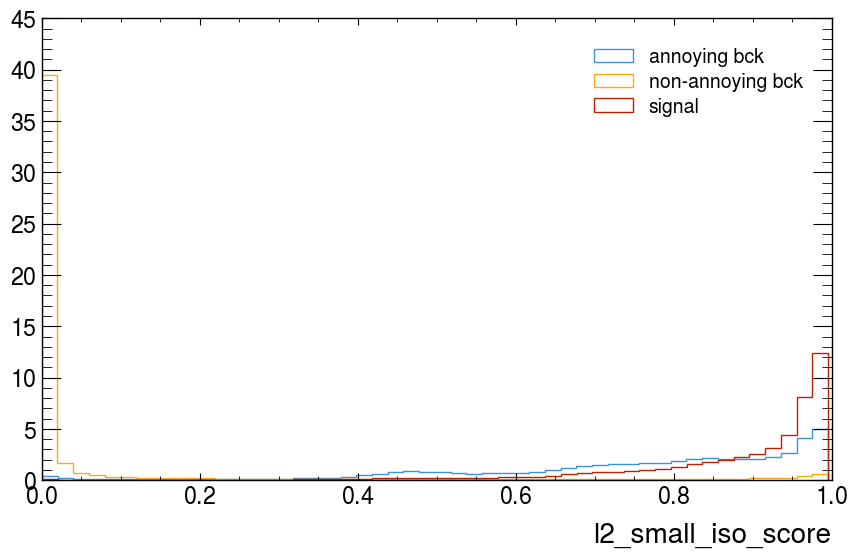

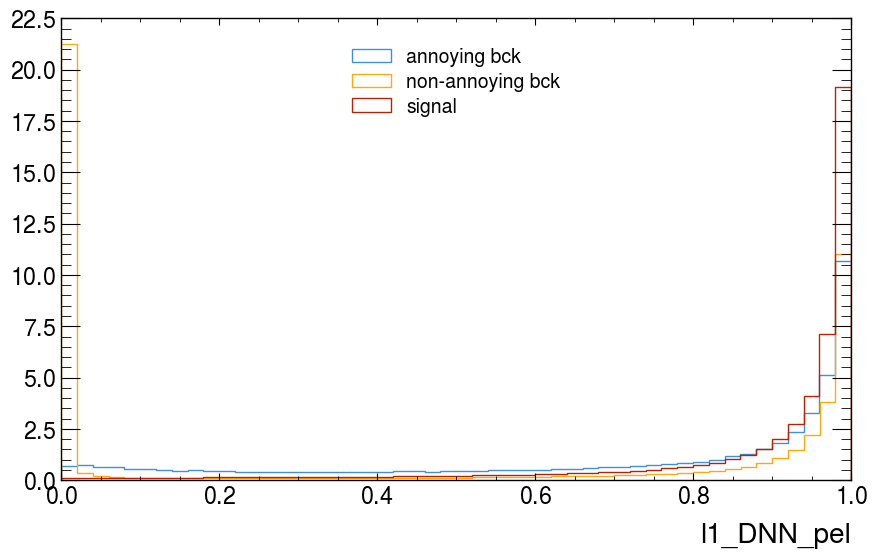

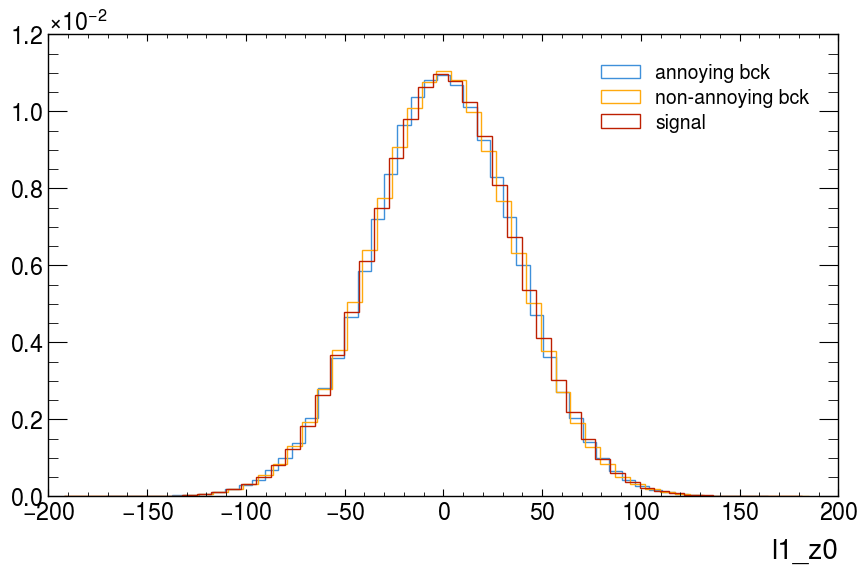

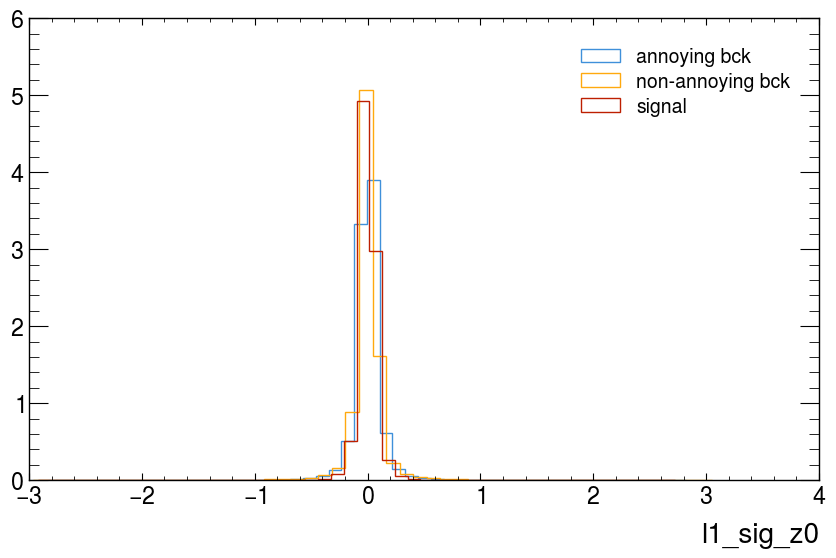

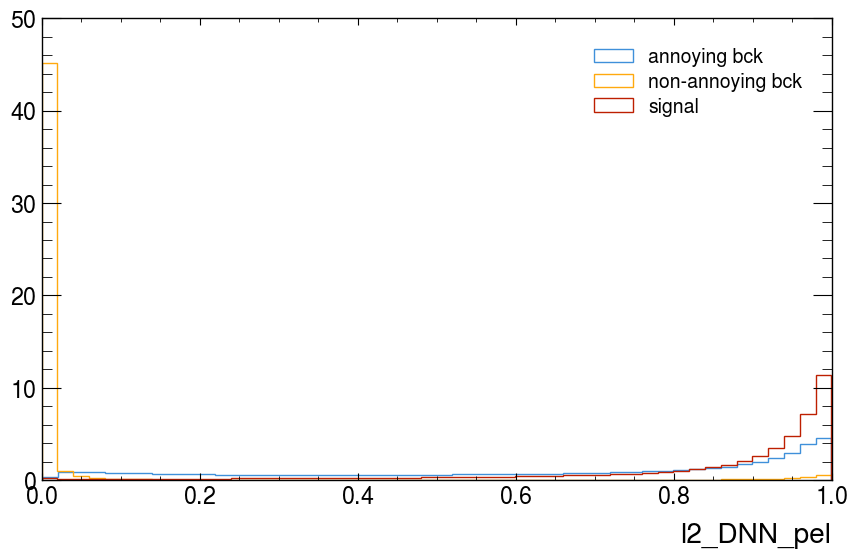

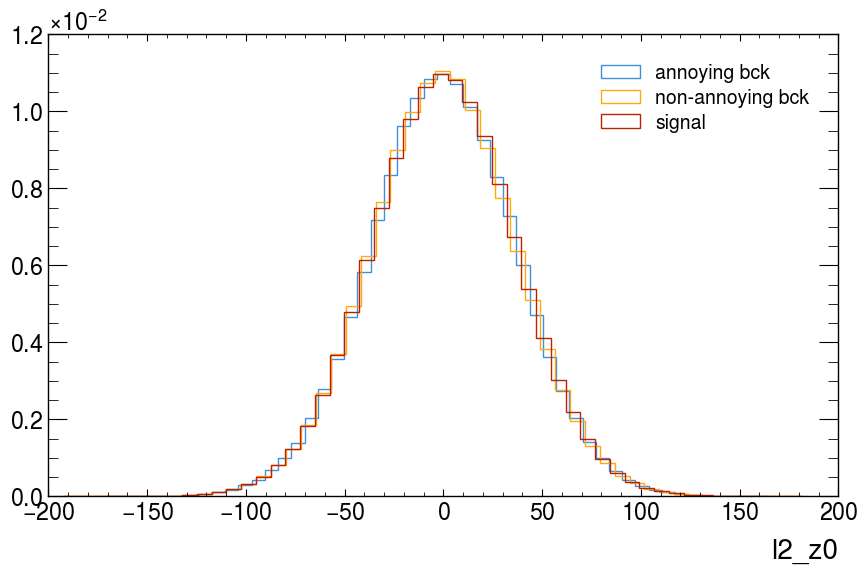

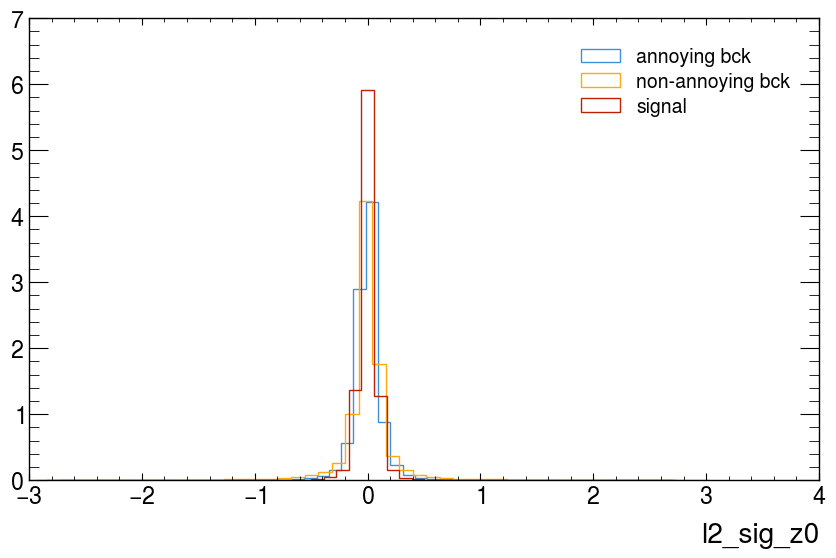

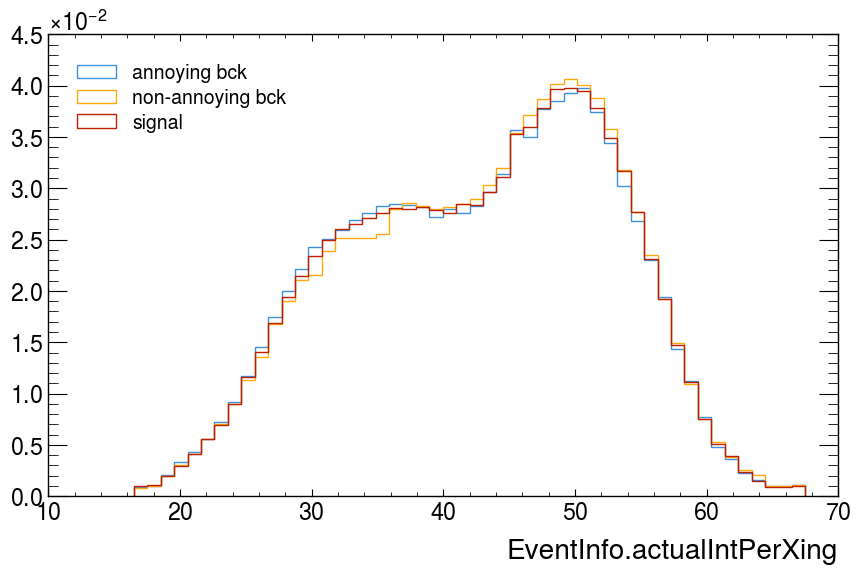

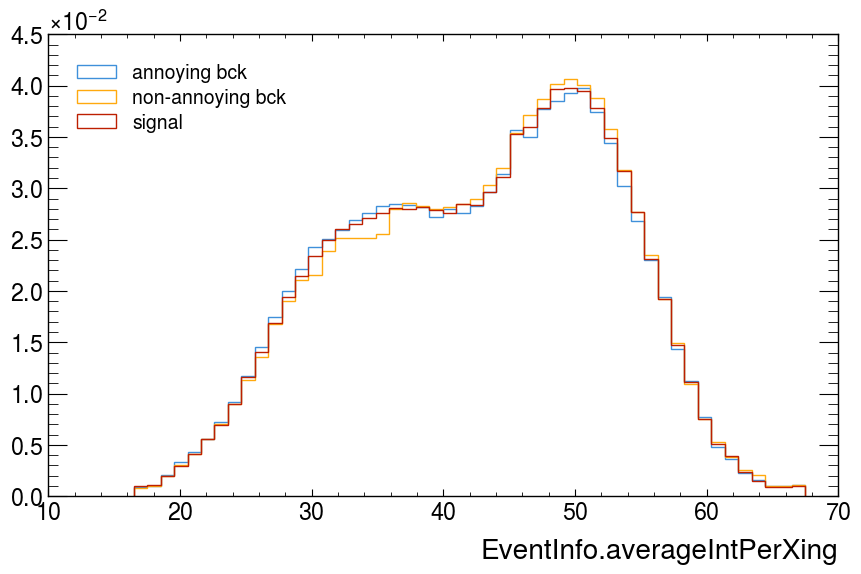

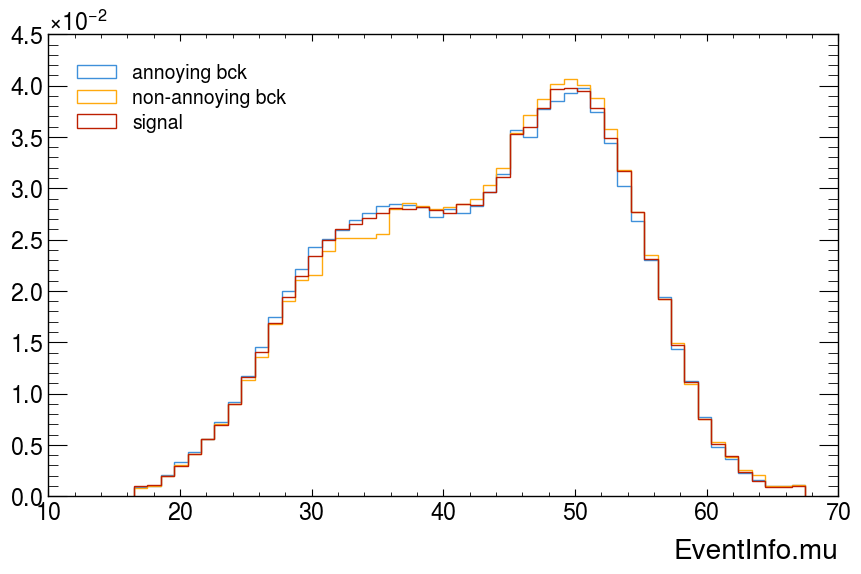

In [ ]:
for i in range(len(pred_z_params)):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(X_test[pred_z_params[i]][critical_bck], bins=50, histtype='step', label='annoying bck',density=True)
    ax.hist(X_test[pred_z_params[i]][~critical_bck & (y_test == 0)], bins=50, histtype='step', label='non-annoying bck',density=True)
    ax.hist(X_test[pred_z_params[i]][y_test==1], bins=50, histtype='step', label='signal',density=True)
    # ax.hist(true_data[pred_z_params[i]], bins=50, histtype='step', label='Data')
    ax.legend()
    ax.set_xlabel(pred_z_params[i])

In [ ]:
# print(X_test.columns)
print(X_test[['l1_truthType','l2_truthType']][critical_bck].value_counts())

l1_truthType  l2_truthType
2.0           4.0             101569
4.0           2.0              79713
2.0           17.0              5370
              3.0               2067
4.0           4.0               1385
17.0          2.0                810
3.0           2.0                362
2.0           6.0                239
              0.0                106
4.0           17.0                67
6.0           2.0                 67
4.0           3.0                 29
2.0           15.0                27
              16.0                15
17.0          4.0                 14
              3.0                 13
15.0          2.0                 11
2.0           7.0                  9
3.0           4.0                  9
              3.0                  7
              17.0                 6
6.0           17.0                 6
2.0           2.0                  6
17.0          17.0                 5
6.0           3.0                  4
4.0           6.0                  4
2.0        

Text(1, 0, 'l1 small iso score')

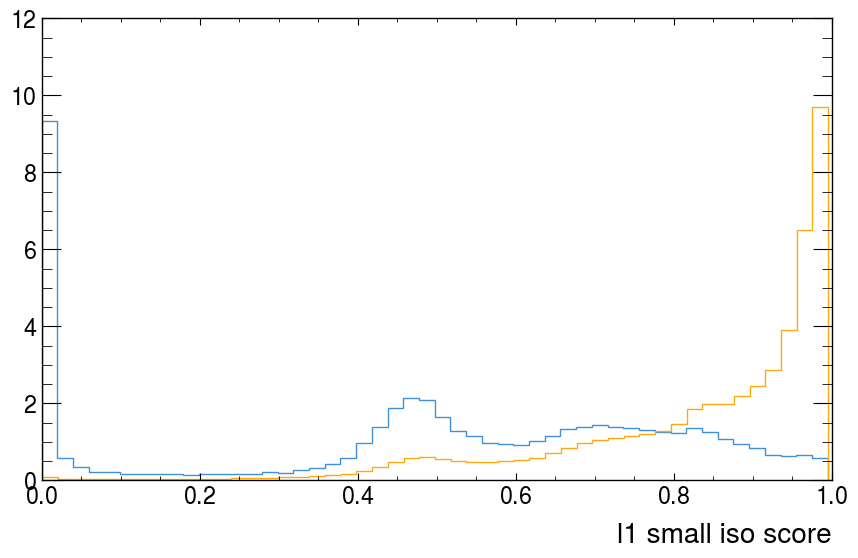

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(X_test['l1_small_iso_score'][X_test['l1_truthType'] == 4], bins=50, histtype='step', label='l1 electron',density=True)
ax.hist(X_test['l1_small_iso_score'][X_test['l1_truthType'] == 2], bins=50, histtype='step', label='l1 electron',density=True)

ax.set_xlabel('l1 small iso score')


<ValueView A1=0.013368060800001809 A2=0.028214266532800156 scale=0.9999293181414479 shift=0.0005369925940851168>
<ValueView A1=0.013368060800001809 A2=0.028214266532800156 scale=0.9999293181414479 shift=0.0005369925940851168>


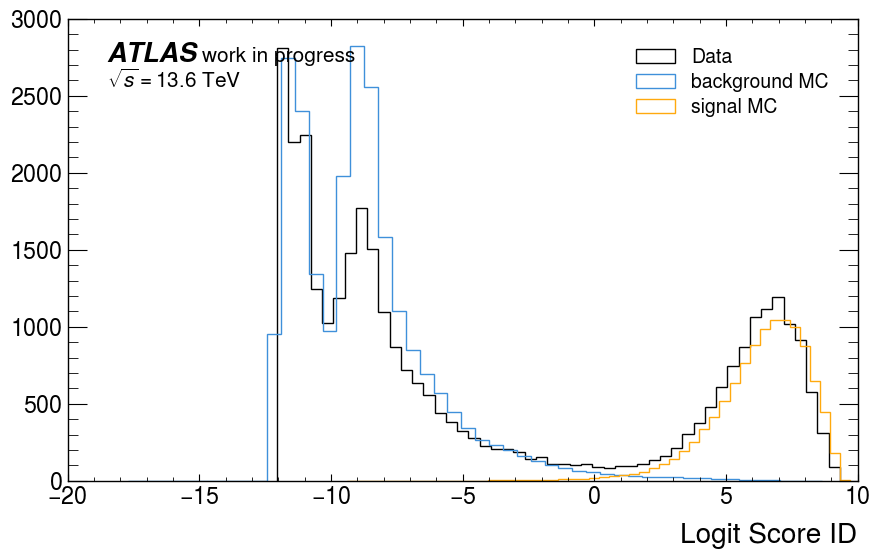

In [ ]:
# fit data and MC

from iminuit import Minuit

error_sig = np.sqrt(bins_signal)
error_bck = np.sqrt(bins_bck)
error_data = np.sqrt(bins_data)



def MAE(A1, A2, scale, shift):
    x = scale * (edges_signal + shift)
    y = A1*bins_signal + A2*bins_bck

    dx = ( x[1:] - x[:-1] / 2 ) - ( edges_signal[1:] - edges_signal[:-1] / 2 )
    dy = y - bins_data

    distances = np.sqrt(dx**2 + dy**2)
    error_combined = np.sqrt(error_sig**2 + error_bck**2 + error_data**2)
    # weighted_avg = np.average(distances, weights=1/error_combined)
    weighted_avg = np.sum(distances)
    return weighted_avg

m = Minuit(MAE, A1=0.0032315049099569397, A2=0.012, scale=1, shift=0)
# m.limits['A1'] = (0.05, 1)
# m.limits['A2'] = (0, 1)
# m.limits['scale'] = (0.5, 2)
# m.limits['shift'] = (-1, 1)



m.migrad()

print(m.values)
# m.values[0]*=1.55
print(m.values)
# m.values.append(1)
# m.values.append(0)

# fig, ax = plt.subplots(figsize=(10, 6))
# ax.plot((edges_signal[:-1]), bins_signal*m.values[0], '.', label='True iso')
# ax.plot((edges_signal[:-1]), bins_bck*m.values[1], '.', label='True non-iso')
# ax.plot(edges_data[:-1], bins_data, '.', label='Data')

ax.legend()

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(logit_scores_data_small_iso, color='black', bins=50, histtype='step', label='Data')
# ax.plot((edges_signal[:-1]+edges_signal[1:])/2, bins_signal*m.values[0]+bins_bck*m.values[1],'.', label='Fit')
# ax.plot((edges_signal[:-1]+edges_signal[1:])/2, bins_signal*m.values[0], label='True Z')
ax.hist(logit_scores_MC_small_iso[X_test['truth_from_Z']==0], bins=50,weights=(m.values[1])*np.ones_like(logit_scores_MC_small_iso[X_test['truth_from_Z']==0]) , histtype='step', label='background MC')
ax.hist(logit_scores_MC_small_iso[X_test['truth_from_Z']==1], bins=50,weights=m.values[0]*np.ones_like(logit_scores_MC_small_iso[X_test['truth_from_Z']==1]) , histtype='step', label='signal MC')
ax.set_xlabel('Logit Score ID')
hep.atlas.label(data=True, label="work in progress", fontsize=15, ax= ax,rlabel=f"$\sqrt{{s}}=13.6$ TeV")
# ax.set_yscale('log')
ax.legend()